In [3]:
import os
import numpy as np
from scipy.stats import stats
## Ignore my broken HDF5 install|...
os.putenv("HDF5_DISABLE_VERSION_CHECK", '1')
import matplotlib
#matplotlib.use("TkAgg")  # or "Qt5Agg"

def get_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss/1000000000  # Return resident set size in bytes
def find_diffs(run10,run1,axis1):
    t = stats.ttest_ind(run10,run1,axis=axis1, nan_policy='omit'); tt=t[1]
    diff = np.where(tt>0.05, 1, 0) #1 indicates it is not statistically significant; 0 indicates it is
    return diff
from scipy.stats import gaussian_kde
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/')

#import iris
from utils import get_bc_ppe_data, normalize
import psutil
from esem import gp_model
from esem.utils import get_random_params
import seaborn as sns
# import iris.quickplot as qplt
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import xarray as xr
from my_functions import *
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/')

from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.colors as mcolors
import gc
from typing import Optional
from matplotlib.contour import QuadContourSet  # Importing QuadContourSet

print(f"Memory usage: {get_memory_usage()} GB")

dms_ppt=(29/62.13)*1e12#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).
dms_ppb=(29/62.13)*1e11#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).

h2so4_mmr=1e14#/1000
h2so4_aod=1e15#/1000
so2_ppb=(29/64.066)*1e11#/1000 # ppb
so2_ppt=(29/64.066)*1e12#/1000 # ppb
oh_ppt=(29/17.008)*1e12#/1000 # ppb
no3_ppt=(29/62.0049)*1e12#/1000 # ppb
o3_ppt=(29/48)*1e12#/1000 # ppb
cl_ppt=(29/35.453)*1e12#/1000 # ppb
h2so4_ppt=(29/98.079)*1e12#/1000 # ppb
h2so4_ppm=(29/98.079)*1e10#/1000 # ppb

lats=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lats.nc').lat
lons=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lons.nc').lon
lats_so = lats.sel(lat=slice(-60, -40))


2026-03-27 17:38:51.315213: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-27 17:38:51.315792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 17:38:51.370134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-27 17:38:53.438091: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

Memory usage: 0.611053568 GB


In [103]:
ds_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask.nc')

# shipping
ship = xr.open_dataset('/projects/0/prjs1474/aarifi/INPUT/v0006/emissions_inventories//ceds/T63/1850/em-anthropogenic_input4MIPs_emissions_CMIP_CEDS_SO2_1850_T63.nc').emiss_shp
# ship_masked = ship.where(ship > np.mean(2. * ship))
# ship_masked_binary = ship_masked.where(ship_masked > 0, 1).mean('time')
threshold = 6 * ship.mean()
ship_masked_binary = xr.where(ship > threshold, 1,0).mean('time')

# Interpolate to same grid
ship_masked_binary = ship_masked_binary.interp(lat=ds_mask.lat, lon=ds_mask.lon)

# --- Add region + region_name coordinates ---
new_region_index = len(ds_mask.region)
ship_masked_binary = ship_masked_binary.expand_dims(dim={"region": [new_region_index]})
ship_masked_binary = ship_masked_binary.assign_coords(
    region_name=(["region"], ["Shipping"])
)

ds_mask_updated = xr.concat([ds_mask.regional_mask, ship_masked_binary], dim="region")

# --- Combine region_name coordinate as well ---
region_names_updated = xr.concat(
    [ds_mask.region_name, ship_masked_binary.region_name], dim="region"
)

# --- Final dataset ---
ds_mask = xr.Dataset(
    {
        "regional_mask": ds_mask_updated
    },
    coords={
        "region": np.arange(len(region_names_updated)),
        "lat": ds_mask.lat,
        "lon": ds_mask.lon,
        "region_name": region_names_updated
    },
    attrs=ds_mask.attrs
)

ds_mask.to_netcdf('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask_Ships.nc')


In [ ]:

import xarray as xr
import numpy as np

ds = xr.open_dataset("Regional_Mask_Ships.nc")

# extract existing masks
land_idx = np.where(ds.region_name.values == "land")[0].item()
dust_idx = np.where(ds.region_name.values == "Dust belt")[0].item()
savannah_idx = np.where(ds.region_name.values == "Savannah")[0].item()

land_mask = ds.regional_mask[land_idx]
dust_mask = ds.regional_mask[dust_idx]
savannah_mask = ds.regional_mask[savannah_idx]

# Determine latitude bounds in Africa
# Dust belt southernmost latitude
dust_lats = ds.lat.where(dust_mask.sum(dim='lon') > 0, drop=True)
dust_lat_south = dust_lats.min().item()  # ~18°N

# Savannah northernmost latitude
savannah_lats = ds.lat.where(savannah_mask.sum(dim='lon') > 0, drop=True)
savannah_lat_north = savannah_lats.max().item()  # ~2°N

# Broadcast lat/lon to match masks
lat2d, lon2d = xr.broadcast(ds.lat, ds.lon)

# Define African Horn: land AND between Savannah and Dust Belt latitudes AND in Africa
african_horn_mask = ((land_mask==1) &
                     (lat2d <= dust_lat_south) &
                     (lat2d >= savannah_lat_north) &
                     (((lon2d >= 0) & (lon2d <= 55)) | ((lon2d >= 340) & (lon2d <= 360)))  # Africa split
                    ).astype(float)

# Convert to DataArray with a new region dimension
african_horn_da = african_horn_mask.expand_dims(region=[ds.dims['region']])

# Concatenate along the region dimension
ds_new = xr.concat([ds, african_horn_da.to_dataset(name="regional_mask")], dim="region")

# Update region_name coordinate
region_names_new = np.append(ds.region_name.values, "African Horn")
ds_new = ds_new.assign_coords(region_name=region_names_new)

# Update region coordinate
ds_new = ds_new.assign_coords(region=np.arange(ds_new.dims['region']))

print(ds_new)

In [1]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("Regional_Mask_Ships.nc")

# extract existing masks
land_idx = np.where(ds.region_name.values == "land")[0].item()
dust_idx = np.where(ds.region_name.values == "Dust belt")[0].item()
sav_idx  = np.where(ds.region_name.values == "Savannah")[0].item()

land_mask     = ds.regional_mask[land_idx]
dust_mask     = ds.regional_mask[dust_idx]
savannah_mask = ds.regional_mask[sav_idx]

# latitude bounds from existing masks
dust_lat_south = ds.lat.where(dust_mask.sum("lon")>0, drop=True).min().item()
sav_lat_north  = ds.lat.where(savannah_mask.sum("lon")>0, drop=True).max().item()

lat2d, lon2d = xr.broadcast(ds.lat, ds.lon)

# define African Horn region
african_horn = (
    (land_mask == 1)
    & (lat2d <= dust_lat_south)
    & (lat2d >= sav_lat_north)
    & (((lon2d >= 0) & (lon2d <= 55)) | ((lon2d >= 340) & (lon2d <= 360)))
).astype(float)

# --- match shipping workflow format ---
new_region_index = len(ds.region)

african_horn = african_horn.expand_dims(dim={"region":[new_region_index]})
african_horn = african_horn.assign_coords(region_name=(["region"],["African Horn"]))

# merge into regional_mask
regional_mask_new = xr.concat([ds.regional_mask, african_horn], dim="region")

# merge region_name
region_name_new = xr.concat([ds.region_name, african_horn.region_name], dim="region")

# build dataset in identical structure
ds_new = xr.Dataset(
    {"regional_mask": regional_mask_new},
    coords={
        "region": np.arange(len(region_name_new)),
        "region_name": region_name_new,
        "lat": ds.lat,
        "lon": ds.lon,
    },
    attrs=ds.attrs
)

# save
ds_new.to_netcdf("Regional_Mask_Ships_African_Horn.nc")


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)

In [3]:

ds_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask_Ships_African_Horn.nc')


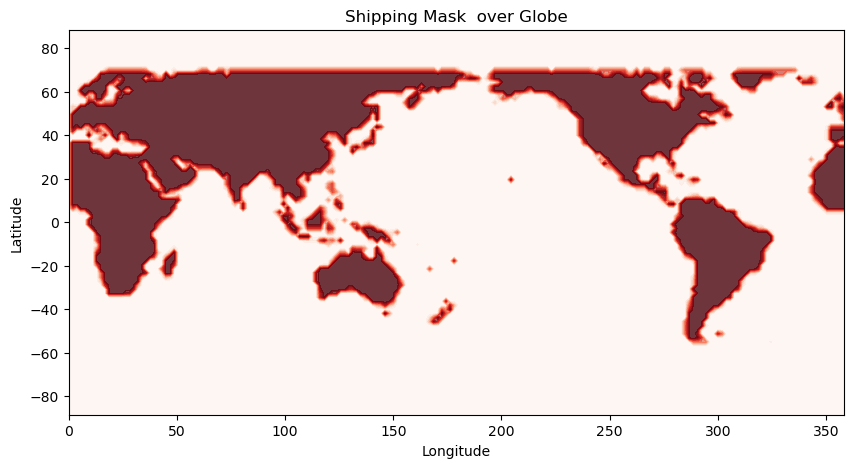

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ds_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask_Ships.nc')

# Base region (e.g. land)
plt.contourf(
    ds_mask.lon,
    ds_mask.lat,
    ds_mask.regional_mask.isel(region=1),  # region index 1
    levels=20,
    cmap='Greys',
    alpha=0.6
)

# Overlay shipping mask (index 25)
plt.contourf(
    ds_mask.lon,
    ds_mask.lat,
    ds_mask.regional_mask.isel(region=1),
    levels=20,
    cmap='Reds',
    alpha=0.5
)

plt.title("Shipping Mask  over Globe")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [3]:

lats_so = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').lat.sel(lat=slice(-60, -30))
lons = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').lon

AOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').TAU_2D_550nm
AOD_SO = AOD.sel(lat=slice(-60, -30))

SSA = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/SSA_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__
SSA_SO = SSA.sel(lat=slice(-60, -30))
SSA_masked = SSA.where(AOD[:,-1] > 0.2)

ANG = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/ANG_POLDER_Interpolated_MODEL.nc').ANG_440nm_670nm
ANG_SO = ANG.sel(lat=slice(-60, -30))

CN_Burden = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CN_BURDEN_POLDER_Interpolated_MODEL.nc').CN_BURDEN
AI = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AI_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__

# AOD_ppe = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TAU_2D_550nm_hifreq_PPE.nc').TAU_2D_550nm.groupby('time.month').mean()
# ANG_ppe = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ANG_440nm_670nm_hifreq_PPE.nc').ANG_440nm_670nm.groupby('time.month').mean()

land_mask = xr.open_dataset('/home/ybhatti2/prjs1474/Pace_PPE_Output/PPE_Experiments/PPE_ENS_1/PPE_ENS_1_202408.01_echam.nc').slm[0]
    
land_mask_interp = land_mask.interp(lat=AOD_SO.lat, lon=AOD_SO.lon)

AAOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AAOD_POLDER_Interpolated_MODEL.nc').AAOD


AOD_m_1= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_1_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__

AOD_m_2= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_2_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CI_550nm

AOD_m_3= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_3_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CS_550nm

ERF = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERF_PPE.nc').__xarray_dataarray_variable__
ERFaci = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFaci_PPE.nc').__xarray_dataarray_variable__
ERFari = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFari_PPE.nc').__xarray_dataarray_variable__

# CDNC_OCI= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_OCI_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')
# CDNC_SPEX= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_SPEX_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')
# CDNC_HARP= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_HARP_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')

# # ERF_SW = top_net_SW_PD - top_net_SW_PI
# # ERF_LW = top_net_LW_PD - top_net_LW_PI 

# # ERF = (ERF_SW + ERF_LW)

def quick_pdf(ensemble, lats):
    area_average=areaweight(ensemble, lats)
    timed_average = area_average.mean('time')
    return area_average,timed_average



In [19]:
# def ERFs_from_vars():
#     #--------------------------
#     # --- Shortwave components (W/m²)
#     #--------------------------
#     # ARI (Aerosol-Radiation Interactions)
#     RFari_sw = (
#         (top_net_SW_PD - (top_up_SW_PD - top_up_SW_Clean_Sky_PD))
#         - (top_net_SW_PI - (top_up_SW_PI - top_up_SW_Clean_Sky_PI))
#     )

#     RFari_sw_cs = (
#         ((top_net_SW_Clear_Sky_PD) - (top_up_SW_Clear_Sky_PD - top_up_SW_Clean_Clear_Sky_PD))
#         - ((top_net_SW_Clear_Sky_PI) - (top_up_SW_Clear_Sky_PI - top_up_SW_Clean_Clear_Sky_PI))
#     )

#     #--------------------------
#     # --- Longwave components
#     #--------------------------
#     RFari_lw = (
#         (top_net_LW_PD - (top_up_LW_PD - top_up_LW_Clean_Sky_PD))
#         - (top_net_LW_PI - (top_up_LW_PI - top_up_LW_Clean_Sky_PI))
#     )

#     RFari_lw_cs = (
#         ((top_net_LW_Clear_Sky_PD) - (top_up_LW_Clear_Sky_PD - top_up_LW_Clean_Clear_Sky_PD))
#         - ((top_net_LW_Clear_Sky_PI) - (top_up_LW_Clear_Sky_PI - top_up_LW_Clean_Clear_Sky_PI))
#     )

#     #--------------------------
#     # --- Clear-sky total (SW+LW)
#     #--------------------------
#     RFari_net_cs = (
#         (top_net_SW_Clear_Sky_PD + top_net_LW_Clear_Sky_PD)
#         - (top_net_SW_Clear_Sky_PI + top_net_LW_Clear_Sky_PI)
#     )

#     #--------------------------
#     # --- ACI (Aerosol-Cloud Interactions)
#     #--------------------------
#     # ERFaci_sw = (
#     #     ((top_up_SW_Clean_Sky_PD - top_up_SW_Clean_Clear_Sky_PD)
#     #      - (top_up_SW_Clean_Sky_PI - top_up_SW_Clean_Clear_Sky_PI))
#     # )

#     # ERFaci_lw = (
#     #     ((top_up_LW_Clean_Sky_PD - top_up_LW_Clean_Clear_Sky_PD)
#     #      - (top_up_LW_Clean_Sky_PI - top_up_LW_Clean_Clear_Sky_PI))
#     # )
    
#     #--------------------------
#     # ERFaci_sw
#     #--------------------------
#     # net sw flux for PI (all-sky)
#     F_PInoa =- top_up_SW_Clean_Sky_PI
#     F_PI_csnoa =- top_up_SW_Clean_Clear_Sky_PI
#     # net sw flux for PD (all-sky)
#     F_PDnoa =- top_up_SW_Clean_Sky_PD
#     F_PD_csnoa = - top_up_SW_Clean_Clear_Sky_PD
#     ERFaci_sw = (F_PDnoa - F_PD_csnoa) - (F_PInoa - F_PI_csnoa)
#     #--------------------------
#     # ERFaci_lw
#     #--------------------------
#     # net lw flux for PI (all-sky)
#     F_PInoa =- top_up_LW_Clean_Sky_PI
#     F_PI_csnoa = - top_up_LW_Clean_Clear_Sky_PI
#     # net lw flux for PD (all-sky)
#     F_PDnoa = - top_up_LW_Clean_Sky_PD
#     F_PD_csnoa = - top_up_LW_Clean_Clear_Sky_PD
#     ERFaci_lw = (F_PDnoa - F_PD_csnoa) - (F_PInoa - F_PI_csnoa)

#     #--------------------------
#     # --- Total aerosol forcing (ERFaer)
#     #--------------------------
#     ERFaer_sw = top_net_SW_PD - top_net_SW_PI
#     ERFaer_lw = top_net_LW_PD - top_net_LW_PI

#     #--------------------------
#     # --- Return mean over time (monthly to annual)
#     #--------------------------
#     return {
#         'RFari_sw': RFari_sw,#.mean('time'),
#         'RFari_sw_cs': RFari_sw_cs,#.mean('time'),
#         'RFari_lw': RFari_lw,#.mean('time'),
#         'RFari_lw_cs': RFari_lw_cs,#.mean('time'),
#         'RFari_net_cs': RFari_net_cs,#.mean('time'),
#         'ERFaci_sw': ERFaci_sw,#.mean('time'),
#         'ERFaci_lw': ERFaci_lw,#.mean('time'),
#         'ERFaer_sw': ERFaer_sw,#.mean('time'),
#         'ERFaer_lw': ERFaer_lw#.mean('time'),
#     }



In [58]:
def ERFs_jia(ds_PD, ds_PI):

    #--------------------------

    # RFari_sw & RFari_sw_cs

    #--------------------------

    # net sw flux for PI (all-sky)

    F_PI = ds_PI.rsdt - ds_PI.rsut

    F_PI_na = ds_PI.rsdt - ds_PI.rsutnoa

    # net sw flux for PD (all-sky)

    F_PD = ds_PD.rsdt - ds_PD.rsut

    F_PD_na = ds_PD.rsdt - ds_PD.rsutnoa

 

    # net sw flux for PI (clear-sky)

    F_PI_cs = ds_PI.rsdt - ds_PI.rsutcs

    F_PI_cs_na = ds_PI.rsdt - ds_PI.rsutcsnoa

    # net sw flux for PD (clear-sky)

    F_PD_cs = ds_PD.rsdt - ds_PD.rsutcs

    F_PD_cs_na = ds_PD.rsdt - ds_PD.rsutcsnoa

 

    RFari_sw = (F_PD - F_PD_na) - (F_PI - F_PI_na)

    RFari_sw_cs = (F_PD_cs - F_PD_cs_na) - (F_PI_cs - F_PI_cs_na)

 

    #--------------------------

    # RFari_lw & RFari_lw_cs

    #--------------------------

    # net lw flux for PI (all-sky)

    F_PI =  - ds_PI.rlut

    F_PI_na =  - ds_PI.rlutnoa

    # net lw flux for PD (all-sky)

    F_PD = - ds_PD.rlut

    F_PD_na = - ds_PD.rlutnoa

 

    # net lw flux for PI (clear-sky)

    F_PI_cs =  - ds_PI.rlutcs

    F_PI_cs_na =  - ds_PI.rlutcsnoa

    # net lw flux for PD (clear-sky)

    F_PD_cs = - ds_PD.rlutcs

    F_PD_cs_na = - ds_PD.rlutcsnoa

 

    RFari_lw = (F_PD - F_PD_na) - (F_PI - F_PI_na)

    RFari_lw_cs = (F_PD_cs - F_PD_cs_na) - (F_PI_cs - F_PI_cs_na)

 

    #--------------------------

    # RFari_net (sw+lw) clear

    #--------------------------

    RFari_net_cs = ( ds_PD.rsdt - ds_PD.rsutcs - ds_PD.rlutcs) - (ds_PI.rsdt - ds_PI.rsutcs - ds_PI.rlutcs)

 

    #--------------------------

    # ERFaci_sw

    #--------------------------

    # net sw flux for PI (all-sky)

    F_PI_na = ds_PI.rsdt - ds_PI.rsutnoa

    F_PI_cs_na = ds_PI.rsdt - ds_PI.rsutcsnoa

    # net sw flux for PD (all-sky)

    F_PD_na = ds_PD.rsdt - ds_PD.rsutnoa

    F_PD_cs_na = ds_PD.rsdt - ds_PD.rsutcsnoa

 

    ERFaci_sw = (F_PD_na - F_PD_cs_na) - (F_PI_na - F_PI_cs_na)

 

    #--------------------------

    # ERFaci_lw

    #--------------------------

    # net lw flux for PI (all-sky)

    F_PI_na =- ds_PI.rlutnoa

    F_PI_cs_na = - ds_PI.rlutcsnoa

    # net lw flux for PD (all-sky)

    F_PD_na =  - ds_PD.rlutnoa

    F_PD_cs_na =  - ds_PD.rlutcsnoa

 

    ERFaci_lw = (F_PD_na - F_PD_cs_na) - (F_PI_na - F_PI_cs_na)

 

    #--------------------------

    # ERFaer_sw

    #--------------------------

    # net sw flux for PI (all-sky)

    F_PI = ds_PI.rsdt - ds_PI.rsut

    # net sw flux for PD (all-sky)

    F_PD = ds_PD.rsdt - ds_PD.rsut

 

    ERFaer_sw = F_PD - F_PI

 

    #--------------------------

    # ERFaer_lw

    #--------------------------

    # # net lw flux for PI (all-sky)

    F_PI =  - ds_PI.rlut

    # net lw flux for PD (all-sky)

    F_PD =  - ds_PD.rlut

 

    ERFaer_lw = F_PD - F_PI

 

 

    return( {

               'RFari_sw':    RFari_sw,

               'RFari_sw_cs': RFari_sw_cs,

               'RFari_lw':    RFari_lw,

               'RFari_lw_cs': RFari_lw_cs,

               'ERFaci_sw':   ERFaci_sw,

               'ERFaci_lw':   ERFaci_lw,

               'ERFaer_sw':   ERFaer_sw,

               'ERFaer_lw':   ERFaer_lw,

               'RFari_net_cs':   RFari_net_cs,

            }

        )


results = ERFs_jia(ds_PD, ds_PI)
RFari_sw = results['RFari_sw']
# RFari_sw_cs = results['RFari_sw_cs']
RFari_lw = results['RFari_lw']
# RFari_lw_cs = results['RFari_lw_cs']
# RFari_net_cs = results['RFari_net_cs']
ERFaci_sw = results['ERFaci_sw']
ERFaci_lw = results['ERFaci_lw']
ERFaer_sw = results['ERFaer_sw']
ERFaer_lw = results['ERFaer_lw']

ERFaer = ERFaer_sw + ERFaer_lw
ERFaci = ERFaci_sw + ERFaci_lw
ERFari = RFari_lw + RFari_sw
ERFaer.groupby('time.month').mean().to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERF_PPE.nc')
ERFari.groupby('time.month').mean().to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFari_PPE.nc')
ERFaci.groupby('time.month').mean().to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFaci_PPE.nc')


ERROR! Session/line number was not unique in database. History logging moved to new session 738


In [35]:
# def ERFs(ds_PD, ds_PI):
#     '''
#     ds_PD: dataset for PD, should be in (time, lat, lon)
#     ds_PI: dataset for PD, should be in (time, lat, lon), where 'time' is month
#     return 2D ERFs
#     '''
#     #--------------------------
#     # RFari_sw & RFari_sw_cs
#     #--------------------------
#     # net sw flux for PI (all-sky)
#     F_PI = ds_PI.rsdt - ds_PI.rsut
#     F_PInoa = ds_PI.rsdt - ds_PI.rsutnoa
#     # net sw flux for PD (all-sky)
#     F_PD = ds_PD.rsdt - ds_PD.rsut
#     F_PDnoa = ds_PD.rsdt - ds_PD.rsutnoa
#     # net sw flux for PI (clear-sky)
#     F_PI_cs = ds_PI.rsdt - ds_PI.rsutcs
#     F_PI_csnoa = ds_PI.rsdt - ds_PI.rsutcsnoa
#     # net sw flux for PD (clear-sky)
#     F_PD_cs = ds_PD.rsdt - ds_PD.rsutcs
#     F_PD_csnoa = ds_PD.rsdt - ds_PD.rsutcsnoa
#     RFari_sw = (F_PD - F_PDnoa) - (F_PI - F_PInoa)
#     RFari_sw_cs = (F_PD_cs - F_PD_csnoa) - (F_PI_cs - F_PI_csnoa)
#     #--------------------------
#     # RFari_lw & RFari_lw_cs
#     #--------------------------
#     # net lw flux for PI (all-sky)
#     F_PI = - ds_PI.rlut
#     F_PInoa = - ds_PI.rlutnoa
#     # net lw flux for PD (all-sky)
#     F_PD = - ds_PD.rlut
#     F_PDnoa = - ds_PD.rlutnoa
#     # net lw flux for PI (clear-sky)
#     F_PI_cs = - ds_PI.rlutcs
#     F_PI_csnoa = - ds_PI.rlutcsnoa
#     # net lw flux for PD (clear-sky)
#     F_PD_cs = - ds_PD.rlutcs
#     F_PD_csnoa = - ds_PD.rlutcsnoa
#     RFari_lw = (F_PD - F_PDnoa) - (F_PI - F_PInoa)
#     RFari_lw_cs = (F_PD_cs - F_PD_csnoa) - (F_PI_cs - F_PI_csnoa)
#     #--------------------------
#     # RFari_net (sw+lw) clear
#     #--------------------------
#     RFari_net_cs = ( ds_PD.rsdt - ds_PD.rsutcs - ds_PD.rlutcs) - (ds_PI.rsdt - ds_PI.rsutcs - ds_PI.rlutcs)
#     #--------------------------
#     # ERFaci_sw
#     #--------------------------
#     # net sw flux for PI (all-sky)
#     F_PInoa = ds_PI.rsdt - ds_PI.rsutnoa
#     F_PI_csnoa = ds_PI.rsdt - ds_PI.rsutcsnoa
#     # net sw flux for PD (all-sky)
#     F_PDnoa = ds_PD.rsdt - ds_PD.rsutnoa
#     F_PD_csnoa = ds_PD.rsdt - ds_PD.rsutcsnoa
#     ERFaci_sw = (F_PDnoa - F_PD_csnoa) - (F_PInoa - F_PI_csnoa)
#     #--------------------------
#     # ERFaci_lw
#     #--------------------------
#     # net lw flux for PI (all-sky)
#     F_PInoa =- ds_PI.rlutnoa
#     F_PI_csnoa = - ds_PI.rlutcsnoa
#     # net lw flux for PD (all-sky)
#     F_PDnoa = - ds_PD.rlutnoa
#     F_PD_csnoa = - ds_PD.rlutcsnoa
#     ERFaci_lw = (F_PDnoa - F_PD_csnoa) - (F_PInoa - F_PI_csnoa)
#     #--------------------------
#     # ERFaer_sw
#     #--------------------------
#     # net sw flux for PI (all-sky)
#     F_PI = ds_PI.rsdt - ds_PI.rsut
#     # net sw flux for PD (all-sky)
#     F_PD = ds_PD.rsdt - ds_PD.rsut
#     ERFaer_sw = F_PD - F_PI
#     #--------------------------
#     # ERFaer_lw
#     #--------------------------
#     # # net lw flux for PI (all-sky)
#     F_PI = - ds_PI.rlut
#     # net lw flux for PD (all-sky)
#     F_PD = - ds_PD.rlut
#     ERFaer_lw = F_PD - F_PI
#     return( {
#     'RFari_sw': RFari_sw.mean(dim='time'),
#     'RFari_sw_cs': RFari_sw_cs.mean(dim='time'),
#     'RFari_lw': RFari_lw.mean(dim='time'),
#     'RFari_lw_cs': RFari_lw_cs.mean(dim='time'),
#     'ERFaci_sw': ERFaci_sw.mean(dim='time'),
#     'ERFaci_lw': ERFaci_lw.mean(dim='time'),
#     'ERFaer_sw': ERFaer_sw.mean(dim='time'),
#     'ERFaer_lw': ERFaer_lw.mean(dim='time'),
#     'RFari_net_cs': RFari_net_cs.mean(dim='time'),
#     }
#     )

In [34]:
import xarray as xr

base_PD = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD"
base_PI = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI"

# =========================
# --- LOAD NET FLUXES (to reconstruct rsdt)
# =========================
# --- PD ---
top_net_SW_PD = xr.open_dataset(f"{base_PD}/top_net_sw_PPE.nc")["srad0"]
top_net_LW_PD = xr.open_dataset(f"{base_PD}/top_net_lw_PPE.nc")["trad0"]

# --- PI ---
top_net_SW_PI = xr.open_dataset(f"{base_PI}/top_net_sw_PPE.nc")["srad0"]
top_net_LW_PI = xr.open_dataset(f"{base_PI}/top_net_lw_PPE.nc")["trad0"]

# =========================
# --- ALL-SKY upward fluxes
# =========================
# --- PD ---
rsut_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_all_sky_PPE.nc"
)["rsut"]

rlut_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_all_sky_PPE.nc"
)["rlut"]

rsdt_PD = xr.open_dataset(
    f"{base_PD}/top_incoming_solar_rad_srad0d_PPE.nc"
)["srad0d"]


# --- PI ---
rsut_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_all_sky_PPE.nc"
)["rsut"]

rlut_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_all_sky_PPE.nc"
)["rlut"]

rsdt_PI = xr.open_dataset(
    f"{base_PI}/top_incoming_solar_rad_srad0d_PPE.nc"
)["srad0d"]

# =========================
# --- CLEAN-SKY (no aerosol)
# =========================
rsutnoa_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc"
)["rsutnoa"]

rlutnoa_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc"
)["rlutnoa"]

rsutnoa_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc"
)["rsutnoa"]

rlutnoa_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc"
)["rlutnoa"]

# =========================
# --- CLEAR-SKY (with aerosol)
# =========================
rsutcs_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_assuming_clear_sky_PPE.nc"
)["rsutcs"]

rlutcs_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_assuming_clear_sky_PPE.nc"
)["rlutcs"]

rsutcs_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_assuming_clear_sky_PPE.nc"
)["rsutcs"]

rlutcs_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_assuming_clear_sky_PPE.nc"
)["rlutcs"]

# =========================
# --- CLEAN + CLEAR (no aerosol, no clouds)
# =========================
rsutcsnoa_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rsutcsnoa"]

rlutcsnoa_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rlutcsnoa"]

rsutcsnoa_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rsutcsnoa"]

rlutcsnoa_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rlutcsnoa"]

# =========================
# --- RECONSTRUCT rsdt
# =========================
# net SW = rsdt - rsut  →  rsdt = net + rsut

# rsdt_PD = top_net_SW_PD + rsut_PD
# rsdt_PI = top_net_SW_PI + rsut_PI

# =========================
# --- BUILD DATASETS
# =========================
ds_PD = xr.Dataset({
    "rsdt": rsdt_PD,
    "rsut": rsut_PD,
    "rsutnoa": rsutnoa_PD,
    "rsutcs": rsutcs_PD,
    "rsutcsnoa": rsutcsnoa_PD,
    "rlut": rlut_PD,
    "rlutnoa": rlutnoa_PD,
    "rlutcs": rlutcs_PD,
    "rlutcsnoa": rlutcsnoa_PD,
})

ds_PI = xr.Dataset({
    "rsdt": rsdt_PI,
    "rsut": rsut_PI,
    "rsutnoa": rsutnoa_PI,
    "rsutcs": rsutcs_PI,
    "rsutcsnoa": rsutcsnoa_PI,
    "rlut": rlut_PI,
    "rlutnoa": rlutnoa_PI,
    "rlutcs": rlutcs_PI,
    "rlutcsnoa": rlutcsnoa_PI,
})

In [16]:
import xarray as xr

# --- PD ---
SW_up_PD = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TOA_upward_shortwave_flux_all_sky_PPE.nc").rsut
LW_up_PD = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TOA_upward_longwave_flux_all_sky_PPE.nc").rlut

SW_up_clean_PD = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc").rsutnoa
LW_up_clean_PD = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc").rlutnoa

# --- PI ---
SW_up_PI = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI/TOA_upward_shortwave_flux_all_sky_PPE.nc").rsut
LW_up_PI = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI/TOA_upward_longwave_flux_all_sky_PPE.nc").rlut

SW_up_clean_PI = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc").rsutnoa
LW_up_clean_PI = xr.open_dataset("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc").rlutnoa

F_PD_all = -(SW_up_PD + LW_up_PD)
F_PI_all = -(SW_up_PI + LW_up_PI)

F_PD_clean = -(SW_up_clean_PD + LW_up_clean_PD)
F_PI_clean = -(SW_up_clean_PI + LW_up_clean_PI)
# Total ERF
ERFaer = F_PD_all - F_PI_all

# ERFari
ERFari = (F_PD_all - F_PD_clean) - (F_PI_all - F_PI_clean)

# ERFaci
ERFaci = F_PD_clean - F_PI_clean

In [ ]:
import xarray as xr

base_PD = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD"
base_PI = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PI"

# =========================
# --- NET fluxes
# =========================
# --- PD ---
top_net_SW_PD = xr.open_dataset(f"{base_PD}/top_net_sw_PPE.nc")["srad0"]
top_net_LW_PD = xr.open_dataset(f"{base_PD}/top_net_lw_PPE.nc")["trad0"]

top_net_SW_Clear_Sky_PD = xr.open_dataset(f"{base_PD}/top_net_sw_clear_sky_PPE.nc")["sraf0"]
top_net_LW_Clear_Sky_PD = xr.open_dataset(f"{base_PD}/top_net_lw_clear_sky_PPE.nc")["traf0"]

# --- PI ---
top_net_SW_PI = xr.open_dataset(f"{base_PI}/top_net_sw_PPE.nc")["srad0"]
top_net_LW_PI = xr.open_dataset(f"{base_PI}/top_net_lw_PPE.nc")["trad0"]

top_net_SW_Clear_Sky_PI = xr.open_dataset(f"{base_PI}/top_net_sw_clear_sky_PPE.nc")["sraf0"]
top_net_LW_Clear_Sky_PI = xr.open_dataset(f"{base_PI}/top_net_lw_clear_sky_PPE.nc")["traf0"]

# =========================
# --- ALL-SKY upward fluxes
# =========================
# --- PD ---
top_up_SW_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_all_sky_PPE.nc"
)["rsut"]

top_up_LW_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_all_sky_PPE.nc"
)["rlut"]

# --- PI ---
top_up_SW_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_all_sky_PPE.nc"
)["rsut"]

top_up_LW_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_all_sky_PPE.nc"
)["rlut"]

# =========================
# --- CLEAN-SKY (no aerosol, with clouds)
# =========================
# --- PD ---
top_up_SW_Clean_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc"
)["rsutnoa"]

top_up_LW_Clean_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc"
)["rlutnoa"]

# --- PI ---
top_up_SW_Clean_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_without_aerosols_all_sky_PPE.nc"
)["rsutnoa"]

top_up_LW_Clean_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_without_aerosols_all_sky_PPE.nc"
)["rlutnoa"]

# =========================
# --- CLEAN + CLEAR SKY (no aerosol, no clouds)
# =========================
# --- PD ---
top_up_SW_Clean_Clear_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rsutcsnoa"]

top_up_LW_Clean_Clear_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rlutcsnoa"]

# --- PI ---
top_up_SW_Clean_Clear_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rsutcsnoa"]

top_up_LW_Clean_Clear_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_without_aerosols_assuming_clear_sky_PPE.nc"
)["rlutcsnoa"]

# =========================
# --- CLEAR-SKY (with aerosols, no clouds)
# =========================
# --- PD ---
top_up_SW_Clear_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_shortwave_flux_assuming_clear_sky_PPE.nc"
)["rsutcs"]

top_up_LW_Clear_Sky_PD = xr.open_dataset(
    f"{base_PD}/TOA_upward_longwave_flux_assuming_clear_sky_PPE.nc"
)["rlutcs"]

# --- PI ---
top_up_SW_Clear_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_shortwave_flux_assuming_clear_sky_PPE.nc"
)["rsutcs"]

top_up_LW_Clear_Sky_PI = xr.open_dataset(
    f"{base_PI}/TOA_upward_longwave_flux_assuming_clear_sky_PPE.nc"
)["rlutcs"]

In [56]:
# =========================
# Net TOA flux (SW + LW)
# =========================
F_PD_all = top_net_SW_PD + top_net_LW_PD
F_PI_all = top_net_SW_PI + top_net_LW_PI

F_PD_clean = top_net_SW_Clean_Sky_PD + top_net_LW_Clean_Sky_PD
F_PI_clean = top_net_SW_Clean_Sky_PI + top_net_LW_Clean_Sky_PI

# =========================
# ERF components
# =========================

# Total aerosol ERF
ERFaer = F_PD_all - F_PI_all

# ERFari (direct + semi-direct)
ERFari = (F_PD_all - F_PD_clean) - (F_PI_all - F_PI_clean)

# ERFaci (cloud-mediated)
ERFaci = F_PD_clean - F_PI_clean

NameError: name 'top_net_SW_PD' is not defined

In [9]:
# Read in table of parameters and their perturbations

ppe_normalized = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/Normalized_PPE_Parameters.csv')
ppe_param = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Parameters.csv')
ppe_normalized.set_index(ppe_normalized.columns[0], inplace=True)
ppe_param.set_index(ppe_param.columns[0], inplace=True)


In [10]:
import copy

#aod_monthly=AOD.groupby('time.month').mean()[:,:-1]
# aod_monthly=AOD_SO.mean('time')[:-1]
# ppe_var = copy.deepcopy(aod_monthly).fillna(0)
#ppe_var_aod_ppe = copy.deepcopy(AOD_ppe[:]).fillna(0)

ppe_var_aod_m_1 = copy.deepcopy(AOD_m_1[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_aod_m_1 = ppe_var_aod_m_1.transpose("ensemble", "month", "lat", "lon")

ppe_var_aod_m_2 = copy.deepcopy(AOD_m_2[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_aod_m_2 = ppe_var_aod_m_2.transpose("ensemble", "month", "lat", "lon")

ppe_var_aod_m_3 = copy.deepcopy(AOD_m_3[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_aod_m_3 = ppe_var_aod_m_3.transpose("ensemble", "month", "lat", "lon")

ppe_var_aaod = copy.deepcopy(AAOD[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_aaod = ppe_var_aaod.transpose("ensemble", "month", "lat", "lon")

ppe_var_ssa = copy.deepcopy(SSA_masked[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_ssa = ppe_var_ssa.transpose("ensemble", "month", "lat", "lon")

ppe_var_erf = ERF.transpose("ensemble", "month", "lat", "lon")
ppe_var_erfaci = ERFaci.transpose("ensemble", "month", "lat", "lon")
ppe_var_erfari = ERFari.transpose("ensemble", "month", "lat", "lon")


# ppe_var_cn = copy.deepcopy(CN_Burden[:,:-1]).groupby('time.month').mean().fillna(0)
# ppe_var_cn = ppe_var_cn.transpose("ensemble", "month", "lat", "lon")
ppe_var_cdnc = copy.deepcopy(CDNC_OCI[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_cdnc = ppe_var_cdnc.transpose("ensemble", "month", "lat", "lon")


ppe_var = copy.deepcopy(AOD[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var = ppe_var.transpose("ensemble", "month", "lat", "lon")

ppe_var_ang = copy.deepcopy(ANG_SO[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_ang = copy.deepcopy(ANG[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_ang = ppe_var_ang.transpose("ensemble", "month", "lat", "lon")

ppe_var_ai = copy.deepcopy(AI[:,:-1]).groupby('time.month').mean().fillna(0)
ppe_var_ai = ppe_var_ai.transpose("ensemble", "month", "lat", "lon")

#ppe_var_ang_ppe = copy.deepcopy(ANG_ppe[:]).fillna(0)

n_total = len(ppe_param)
n_test = 70  # Number of test samples

# Generate randomized indices for splitting the data
random_indices = np.random.permutation(n_total)
random_indices = np.concatenate((random_indices, [0]))

# Split the randomized indices into test and train sets
test_indices = random_indices[:n_test]
train_indices = random_indices[n_test:]

X_test, X_train = ppe_normalized.iloc[test_indices], ppe_normalized.iloc[train_indices]
Y_test, Y_train = ppe_var.isel(ensemble=test_indices), ppe_var.isel(ensemble=train_indices)

Y_test_ang, Y_train_ang = ppe_var_ang.isel(ensemble=test_indices), ppe_var_ang.isel(ensemble=train_indices)
Y_test_aaod, Y_train_aaod = ppe_var_aaod.isel(ensemble=test_indices), ppe_var_aaod.isel(ensemble=train_indices)
Y_test_ssa, Y_train_ssa = ppe_var_ssa.isel(ensemble=test_indices), ppe_var_ssa.isel(ensemble=train_indices)
Y_test_aod_m_1, Y_train_aod_m_1 = ppe_var_aod_m_1.isel(ensemble=test_indices), ppe_var_aod_m_1.isel(ensemble=train_indices)
Y_test_aod_m_2, Y_train_aod_m_2 = ppe_var_aod_m_2.isel(ensemble=test_indices), ppe_var_aod_m_2.isel(ensemble=train_indices)
Y_test_aod_m_3, Y_train_aod_m_3 = ppe_var_aod_m_3.isel(ensemble=test_indices), ppe_var_aod_m_3.isel(ensemble=train_indices)
Y_test_ai, Y_train_ai = ppe_var_ai.isel(ensemble=test_indices), ppe_var_ai.isel(ensemble=train_indices)
Y_test_erf, Y_train_erf = ppe_var_erf.isel(ensemble=test_indices), ppe_var_erf.isel(ensemble=train_indices)
Y_test_erfaci, Y_train_erfaci = ppe_var_erfaci.isel(ensemble=test_indices), ppe_var_erfaci.isel(ensemble=train_indices)
Y_test_erfari, Y_train_erfari = ppe_var_erfari.isel(ensemble=test_indices), ppe_var_erfari.isel(ensemble=train_indices)
Y_test_cdnc, Y_train_cdnc = ppe_var_cdnc.isel(ensemble=test_indices), ppe_var_cdnc.isel(ensemble=train_indices)

# Y_test_cn, Y_train_cn = ppe_var_cn.isel(ensemble=test_indices), ppe_var_cn.isel(ensemble=train_indices)

# Y_test_ang_ppe, Y_train_ang_ppe = ppe_var_ang_ppe.isel(ensemble=test_indices), ppe_var_ang_ppe.isel(ensemble=train_indices)
# Y_test_aod_ppe, Y_train_aod_ppe = ppe_var_aod_ppe.isel(ensemble=test_indices), ppe_var_aod_ppe.isel(ensemble=train_indices)


In [5]:
###################################
### EMULATOR ###
###################################

kernal=['Linear','Matern52'] # for  ERF, AOD_M_1, AOD_M_3
#kernal=['Bias','Matern52','Polynomial'] # ANG
gp_model_aod_m1 = gp_model(X_train, Y_train_aod_m_1, kernel=kernal)
gp_model_aod_m1.train()

gp_model_aod_m3 = gp_model(X_train, Y_train_aod_m_3, kernel=kernal)
gp_model_aod_m3.train()

kernal=['Matern52']  # AOD, CDNC
#when the underlying function exhibits certain degrees of smoothness, Matern can be used. the higher the matern, the smoother the covariance and contineous 
gp_model_ = gp_model(X_train, Y_train, kernel=kernal)
gp_model_.train()

gp_model_cdnc = gp_model(X_train, Y_train_cdnc, kernel=kernal)
gp_model_cdnc.train()

print(f"Memory usage: {get_memory_usage()} GB")

kernal=['Bias','Matern52','Polynomial'] # ANG , SSA, AOD_M_2, AI
gp_model_ang = gp_model(X_train, Y_train_ang, kernel=kernal)
gp_model_ang.train()

gp_model_ssa = gp_model(X_train, Y_train_ssa, kernel=kernal)
gp_model_ssa.train()

gp_model_aod_m2 = gp_model(X_train, Y_train_aod_m_2, kernel=kernal)
gp_model_aod_m2.train()

gp_model_ai = gp_model(X_train, Y_train_ai, kernel=kernal)
gp_model_ai.train()

kernal=['Matern52']  # AAOD

# gp_model_aaod = gp_model(X_train, Y_train_aaod, kernel=kernal)
# gp_model_aaod.train()


print(f"Memory usage: {get_memory_usage()} GB")


2025-11-02 17:12:48.263643: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Memory usage: 12.58389504 GB
Memory usage: 13.886066688 GB


2025-11-18 18:44:09.320775: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


283352


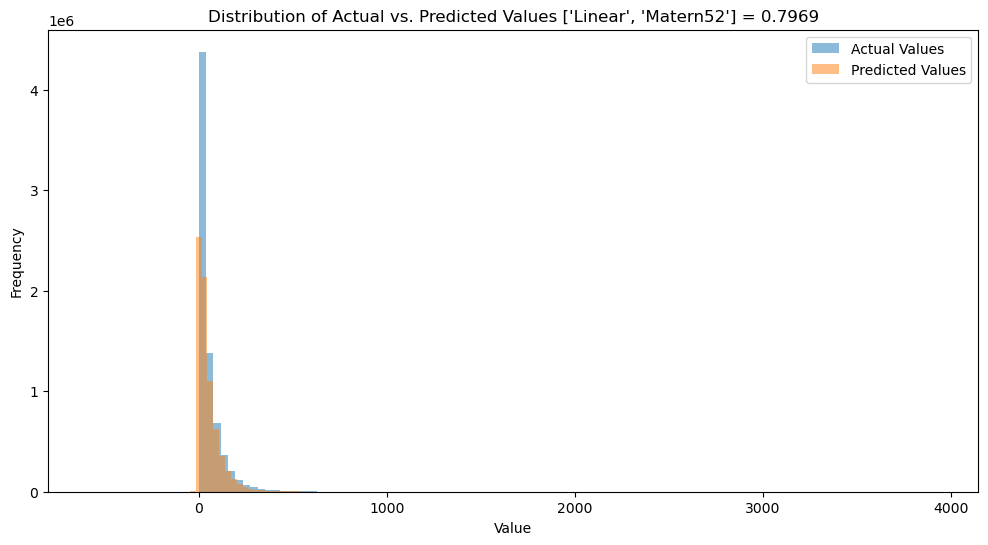

In [69]:
kernal=['Bias','Matern52','Polynomial'] # ANG , SSA
#kernal=['Linear','Matern52'] # for SSA, ERF
kernal=['Linear','Matern52'] # for  ERF, AOD_M_1, AOD_M_3

gp_model_aaod = gp_model(X_train, Y_train_cdnc, kernel=kernal)
gp_model_aaod.train()

# Plot distributions
gp_predictions, _ = gp_model_aaod.predict(X_test.values)

# Flatten arrays
y_true = Y_test_cdnc.data.flatten()
y_pred = gp_predictions.data.flatten()
print(len(np.where(y_pred<0)[0]))
# Create mask to drop zeros and NaNs
mask = (y_true != 0) & (y_pred != 0) & ~np.isnan(y_true) & ~np.isnan(y_pred)

# Apply mask
y_true = y_true[mask]
y_pred = y_pred[mask]

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(y_true, bins=100, alpha=0.5, label='Actual Values')
plt.hist(y_pred, bins=100, alpha=0.5, label='Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f'Distribution of Actual vs. Predicted Values {kernal} = {np.corrcoef(y_true, y_pred)[1][0]**2:.4f}')
plt.legend()
plt.show()


2025-11-19 10:56:30.478047: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


239498


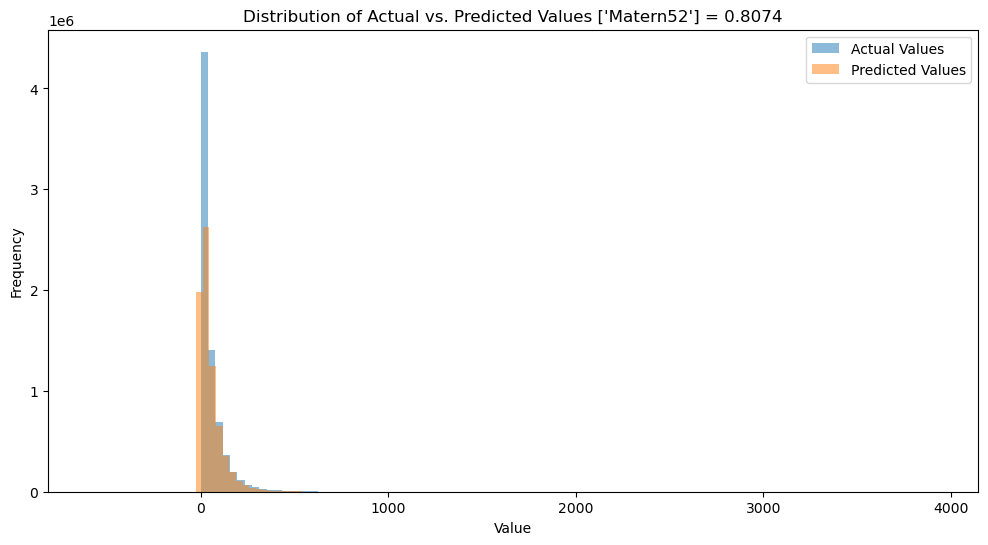

In [11]:
kernal=['Bias','Matern52','Polynomial'] # ANG , SSA, 
#kernal=['Linear','Matern52'] # for SSA, ERF
kernal=['Matern52']  # AOD 0.9353
#kernal=['Linear','Matern52'] # for  AOD 0.9421

gp_model_aaod = gp_model(X_train, Y_train_cdnc, kernel=kernal)
gp_model_aaod.train()

# Plot distributions
gp_predictions, _ = gp_model_aaod.predict(X_test.values)

# Flatten arrays
y_true = Y_test_cdnc.data.flatten()
y_pred = gp_predictions.data.flatten()
print(len(np.where(y_pred<0)[0]))
# Create mask to drop zeros and NaNs
mask = (y_true != 0) & (y_pred != 0) & ~np.isnan(y_true) & ~np.isnan(y_pred)


# Apply mask
y_true = y_true[mask]
y_pred = y_pred[mask]

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(y_true, bins=100, alpha=0.5, label='Actual Values')
plt.hist(y_pred, bins=100, alpha=0.5, label='Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f'Distribution of Actual vs. Predicted Values {kernal} = {np.corrcoef(y_true, y_pred)[1][0]**2:.4f}')
plt.legend()
plt.show()


609739


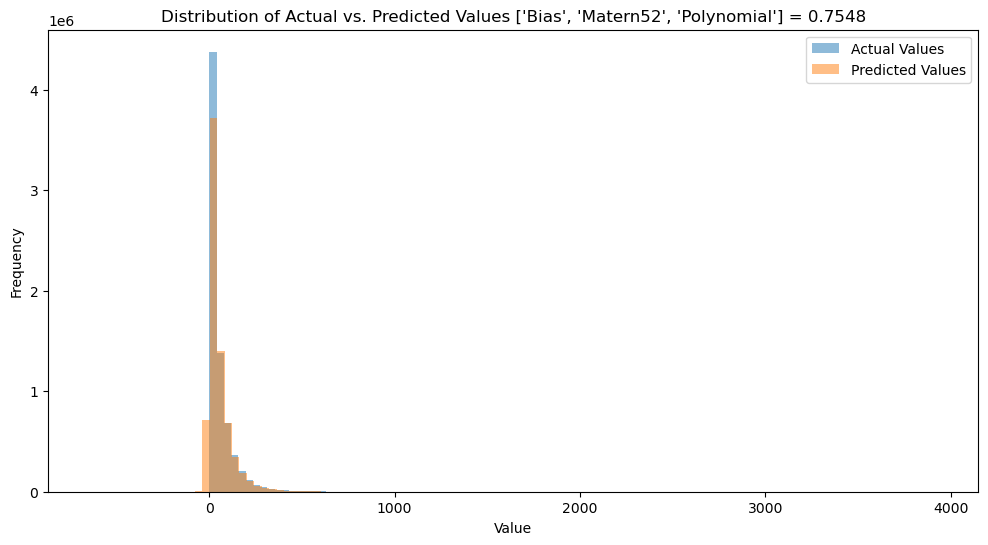

In [71]:
kernal=['Bias','Matern52','Polynomial'] # ANG , SSA
#kernal=['Linear','Matern52'] # for SSA, ERF
#kernal=['Matern52']  # AOD 0.9353
#kernal=['Linear','Matern52'] # for  AOD 0.9421

gp_model_aaod = gp_model(X_train, Y_train_cdnc, kernel=kernal)
gp_model_aaod.train()

# Plot distributions
gp_predictions, _ = gp_model_aaod.predict(X_test.values)

# Flatten arrays
y_true = Y_test_cdnc.data.flatten()
y_pred = gp_predictions.data.flatten()
print(len(np.where(y_pred<0)[0]))
# Create mask to drop zeros and NaNs
mask = (y_true != 0) & (y_pred != 0) & ~np.isnan(y_true) & ~np.isnan(y_pred)


# Apply mask
y_true = y_true[mask]
y_pred = y_pred[mask]

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(y_true, bins=100, alpha=0.5, label='Actual Values')
plt.hist(y_pred, bins=100, alpha=0.5, label='Predicted Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f'Distribution of Actual vs. Predicted Values {kernal} = {np.corrcoef(y_true, y_pred)[1][0]**2:.4f}')
plt.legend()
plt.show()


In [6]:
import os
import itertools
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import copy

def test_emulator_for_variable(var_name, base_dir, n_samples=26000):

    # --------------------------
    # Directories
    # --------------------------
    base_dir_regional = f"{base_dir}"
    # os.makedirs(f"{base_dir_regional}/{var_name}", exist_ok=True)

    # --------------------------
    # Load data
    # --------------------------
    # models = xr.open_dataset(
    #     f"{base_dir_regional}/{var_name}/Regional_Uncertainty_{var_name.lower()}_{n_samples}.nc"
    # )
    models = xr.open_dataset(
        f"{base_dir_regional}/{var_name}/emulated_{var_name.lower()}_{n_samples}.nc"
    )

    varname = list(models.data_vars.keys())[0]
    model = models[varname].transpose("sample", "month", "region")
    ppe_var = copy.deepcopy(model[:-1]).fillna(0)

    print(f"Loaded {var_name}")

    # --------------------------
    # Kernel sets for variable
    # --------------------------
    kernel_dict = {
        "AOD": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "AAOD": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "ANG": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "SSA": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "AI": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "CDNC": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "CDNC_Filtered": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "REFFL_CT": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "AOD_Mode_1": ['Linear','Matern52'],
        "AOD_Mode_2": ['Bias','Matern52','Polynomial'],
        "AOD_Mode_3": ['Linear','Matern52'],
        "AOD_Mode_Coarse": ['Bias','Matern52','Polynomial'],
        "ERF": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "ERFaci": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
        "ERFari": ['Bias', 'Linear', 'Matern52', 'Polynomial'],
    }

    if var_name not in kernel_dict:
        raise ValueError(f"Unknown variable {var_name}")

    kernels_to_test = kernel_dict[var_name]

    # All combinations (size 1..n)
    kernel_combinations = []
    for r in range(1, len(kernels_to_test)+1):
        kernel_combinations.extend(itertools.combinations(kernels_to_test, r))

    print(f"Testing {len(kernel_combinations)} kernel combinations for {var_name}")

    # --------------------------
    # Load parameters
    # --------------------------
    ppe_normalized = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/Normalized_PPE_Parameters.csv')
    ppe_param = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Parameters.csv')

    ppe_normalized.set_index(ppe_normalized.columns[0], inplace=True)
    ppe_param.set_index(ppe_param.columns[0], inplace=True)

    n_total = len(ppe_param)
    n_test = 80

    random_idx = np.random.permutation(n_total)
    random_idx = np.concatenate((random_idx, [0]))

    test_indices = random_idx[:n_test]
    train_indices = random_idx[n_test:]

    X_test, X_train = ppe_normalized.iloc[test_indices], ppe_normalized.iloc[train_indices]
    Y_test, Y_train = ppe_var.isel(sample=test_indices), ppe_var.isel(sample=train_indices)

    print("Split train/test")

    # --------------------------
    # Loop over kernel combos
    # --------------------------

    results = {}

    for kernal in kernel_combinations:

        print(f"\n--- Training kernel combo: {kernal} ---")

        gp = gp_model(X_train, Y_train, kernel=list(kernal))
        gp.train()

        preds, _ = gp.predict(X_test.values)

        y_true = Y_test.data.flatten()
        y_pred = preds.data.flatten()

        r2 = np.corrcoef(y_true, y_pred)[1, 0] ** 2
        results[kernal] = r2

        # --------------------------
        # Histogram plot
        # --------------------------
        plt.figure(figsize=(12, 6))
        plt.hist(y_true, bins=40, alpha=0.5, label='Actual')
        plt.hist(y_pred, bins=40, alpha=0.5, label='Predicted')
        plt.xlabel("Value")
        plt.ylabel("Frequency")
        plt.title(f"{var_name}: Kernel {kernal} — R² = {r2:.4f}")
        plt.legend()

        out_plot = f"{base_dir_regional}/{var_name}/hist_kernel_{'_'.join(kernal)}.png"
      #  plt.show()
        plt.close()

        print(f"Saved histogram → {out_plot}")
        print(f"R² = {r2:.4f}")

    print("\nFinished all kernel combinations.")
    return results

base_dir = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional"

variables = [
    "AOD","AAOD","ANG","AOD_Mode_1","AOD_Mode_2","AOD_Mode_3",
    "SSA","AI","AOD_Mode_Coarse","CDNC"
]
variables = [
  "REFFL_CT"
]

all_results = {}

for v in variables:
    print(f"\n########## {v} ##########")
    all_results[v] = test_emulator_for_variable(v, base_dir, n_samples=100000)



########## REFFL_CT ##########
Loaded REFFL_CT
Testing 15 kernel combinations for REFFL_CT
Split train/test

--- Training kernel combo: ('Bias',) ---
Saved histogram → /home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/REFFL_CT/hist_kernel_Bias.png
R² = 0.9900

--- Training kernel combo: ('Linear',) ---
Saved histogram → /home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/REFFL_CT/hist_kernel_Linear.png
R² = 0.9098

--- Training kernel combo: ('Matern52',) ---
Saved histogram → /home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/REFFL_CT/hist_kernel_Matern52.png
R² = 0.9900

--- Training kernel combo: ('Polynomial',) ---
Saved histogram → /home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/REFFL_CT/hist_kernel_Polynomial.png
R² = 0.9896

--- Training kernel combo: ('Bias', 'Linear') ---
Saved histogram → /h

In [21]:
# #########################################################################################

# This method resample along each column’s empirical distribution 
# (i.e., bootstrap from the actual values in ppe_normalized), so 
# the marginal distribution shape of each parameter is preserved, 
# instead of just sampling uniformly.


# deep copy of your normalized PPE params
ppe_dist = copy.deepcopy(ppe_param)

# extract control row
control_row = ppe_dist.loc[["PPE_Control"]]

# number of new samples
n_samples = 200000
n_samples = 4000

# sample each column with replacement from its empirical distribution
sampled_cols = {
    col: np.random.choice(ppe_dist[col].values, size=n_samples, replace=True)
    for col in ppe_dist.columns
}


new_samples_empirical = pd.DataFrame(sampled_cols)

# concat control row on top
ppe_non_normalized_new_samples = pd.concat([control_row, new_samples_empirical], ignore_index=True)
ppe_normalized_new_samples = (ppe_non_normalized_new_samples - ppe_non_normalized_new_samples.min()) / (ppe_non_normalized_new_samples.max() - ppe_non_normalized_new_samples.min())


In [22]:
# # create DataFrame
# new_samples_empirical = pd.DataFrame(sampled_cols)

# # concat control row on top
# ppe_non_normalized_new_samples = pd.concat([control_row, new_samples_empirical], ignore_index=True)
# ppe_normalized_new_samples = (ppe_non_normalized_new_samples - ppe_non_normalized_new_samples.min()) / (ppe_non_normalized_new_samples.max() - ppe_non_normalized_new_samples.min())

# excluded_columns = [
#     'SCALE_EMI_DMS',
#     'SCALE_EMI_SS_ACC',
#     'SCALE_EMI_SS_COARSE'
# ]

# # Store the original values of the excluded columns
# original_excluded_data = ppe_normalized_new_samples[excluded_columns].copy()
# # Get the first row's values
# first_row_values = ppe_normalized_new_samples.iloc[0].values
# # Create a new DataFrame where each row is a copy of the first row
# # This uses NumPy broadcasting for efficienc
# ppe_normalized_new_samples.loc[:, :] = first_row_values
# # Restore the original values for the excluded columns
# ppe_normalized_new_samples[excluded_columns] = original_excluded_data


# new_samples_empirical = ppe_non_normalized_new_samples[excluded_columns].copy()
# ppe_non_normalized_new_samples.loc[:, :] = ppe_non_normalized_new_samples.iloc[0].values
# # Restore the original values for the excluded columns
# ppe_non_normalized_new_samples[excluded_columns] = new_samples_empirical


# -------------
## AE  ##
# -------------
# emulated_ang, var_ang_ = gp_model_ang.predict(ppe_normalized_new_samples.values)
# # emulated_ang = emulated_ang.where(~land_mask_interp.isnull())
# obs_vec = ANG[:,-1].groupby('time.month').mean()
# valid_mask = ~np.isnan(obs_vec)
# emulated_ang_masked = emulated_ang.where(valid_mask)
# var_ang_masked = var_ang_.where(valid_mask)

# # -------------
# ## AOD  ##
# # -------------
# #emulated_ang.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/for_aerocom/Emulated_ANG_Southern_Ocean_DMS_SSA.nc')
# emulated_aod, var_aod = gp_model_.predict(ppe_normalized_new_samples.values)
# # emulated_aod = emulated_aod.where(~land_mask_interp.isnull())
# obs_vec = AOD[:,-1].groupby('time.month').mean()
# valid_mask = ~np.isnan(obs_vec)
# emulated_aod_masked = emulated_aod.where(valid_mask)
# var_aod_masked = var_aod.where(valid_mask)

# # -------------
# ## SSA  ##
# # -------------
# emulated_ssa, var_ssa = gp_model_ssa.predict(ppe_normalized_new_samples.values)
# # emulated_aod = emulated_aod.where(~land_mask_interp.isnull())
# obs_vec = SSA[:,-1].groupby('time.month').mean()
# valid_mask = ~np.isnan(obs_vec)
# emulated_ssa_masked = emulated_ssa.where(valid_mask)#.where(land_mask==1)
# var_ssa_masked = var_ssa.where(valid_mask)#.where(land_mask==1)

# #AI 

# emulated_ai, var_ai = gp_model_ai.predict(ppe_normalized_new_samples.values)
# # emulated_aod = emulated_aod.where(~land_mask_interp.isnull())
# obs_vec = AI[:,-1].groupby('time.month').mean()
# valid_mask = ~np.isnan(obs_vec)
# emulated_ai_masked = emulated_ssa.where(valid_mask)#.where(land_mask==1)
# var_ai_masked = var_ai.where(valid_mask)#.where(land_mask==1)


emulated_cdnc, var_cdnc = gp_model_aaod.predict(ppe_normalized_new_samples.values)
# emulated_aod = emulated_aod.where(~land_mask_interp.isnull())
obs_vec = CDNC_OCI[-1].groupby('time.month').mean()
valid_mask = ~np.isnan(obs_vec)


# -------------
## AAOD  ##
# -------------
# emulated_ssa, var_ssa = gp_model_aaod.predict(ppe_normalized_new_samples.values)
# # emulated_aod = emulated_aod.where(~land_mask_interp.isnull())
# obs_vec = AAOD[:,-1].groupby('time.month').mean()
# valid_mask = ~np.isnan(obs_vec)
# emulated_ssa_masked = emulated_ssa.where(valid_mask).where(land_mask==1)
# var_ssa_masked = var_ssa.where(valid_mask).where(land_mask==1)

# emulated_ang_ppe, var_ang_ppe = gp_model_ang_ppe.predict(ppe_normalized_new_samples.values)

# emulated_aod_ppe, var_aod_ppe = gp_model_aod_ppe.predict(ppe_normalized_new_samples.values)

# emulated_aod.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/for_aerocom/Emulated_AOD_Southern_Ocean_DMS_SSA.nc')

# ppe_normalized_new_samples.to_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/for_aerocom/samples_20001_monthly.csv')
# new_samples_empirical.to_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/for_aerocom/samples_20001_monthly_non.csv')
print(f"Memory usage: {get_memory_usage()} GB")


Memory usage: 169.77004544 GB


# Step 1: Calculate implausibility across globe


In [54]:
import numpy as np
import xarray as xr

# --- Define uncertainties ---
instr_frac_aod = 0.15   # 10% fractional instrument uncertainty
instr_abs_aod  = 0.035   # absolute instrument uncertainty
instr_frac_ang = 0.20   # 20% fractional instrument uncertainty

instr_abs_ang = 0.20   # 0.2  instrument uncertainty
repr_frac      = 0.10   # 10% representation uncertainty
Var_S          = 0.0    # structural uncertainty (neglected)
repr_ang= 0.10   # 0.1 representation uncertainty for ANG

instr_frac_ssa = 0.10   # 10% fractional instrument uncertainty
instr_abs_ssa  = 0.05   # absolute instrument uncertainty
repr_ang= 0.10   # 0.1 representation uncertainty for ssa

instr_abs_aaod = 0.01
instr_frac_ssa  = 0.1   # absolute instrument uncertainty
instr_abs_ssa_filter  = 0.06   # absolute instrument uncertainty

instr_frac_cdnc = 0.15   # 10% fractional instrument uncertainty
instr_abs_cdnc  = 0.035   # absolute instrument uncertainty
instr_frac_cdnc = 0.4   # 20% fractional instrument uncertainty

# --- Compute monthly means (global obs PACE) ---
# aod_pace_monthly_global = AOD[:, -1].groupby('time.month').mean()
# ang_pace_monthly_global = ANG[:, -1].groupby('time.month').mean()
# ssa_pace_monthly_global = SSA[:, -1].groupby('time.month').mean()
# ssa_filter_pace_monthly_global = SSA_masked[:, -1].groupby('time.month').mean()
# ai_pace_monthly_global = AI[:, -1].groupby('time.month').mean()
cdnc_pace_monthly_global = CDNC_OCI[-1].groupby('time.month').mean()

#ssa_pace_monthly_global = SSA[:, -1].groupby('time.month').mean().where(land_mask==1)

#aaod_pace_monthly_global = AAOD[:, -1].groupby('time.month').mean().where(land_mask==1)

# --- Function to compute variance for R and O ---
def compute_variances(obs, instr_frac, repr_frac, var='AOD'):
    """
    obs: xr.DataArray (month, lat, lon)
    instr_frac: fractional instrument uncertainty (e.g., 0.1)
    repr_frac: fractional representation uncertainty (e.g., 0.1)
    var: 'AOD' or 'ANG'
    """
    if var == 'AOD' or 'AI':
        # Elementwise: choose larger of fractional (10%) or absolute (0.03)
        frac_unc = instr_frac * obs
        abs_unc = xr.full_like(obs, instr_abs_aod)
        instr_unc = xr.where(frac_unc > abs_unc, frac_unc, abs_unc)

        # mask NaNs from obs
        instr_unc = instr_unc.where(~np.isnan(obs))
        Var_O = instr_unc**2
        Var_R = (repr_frac * obs)**2

    elif var == 'ANG':
        abs_unc = xr.full_like(obs, instr_frac_ang)
        Var_O = (abs_unc.where(~np.isnan(obs)))**2

        # Var_O = (instr_frac_ang * obs)**2 # change to absolute
        abs_unc = xr.full_like(obs, repr_frac)
        Var_R = (abs_unc.where(~np.isnan(obs)))**2

    elif var == 'SSA':
        abs_unc = xr.full_like(obs, instr_frac)
        Var_O = (abs_unc.where(~np.isnan(obs)))**2

        # frac_unc = instr_frac * obs
        # Var_O = (frac_unc.where(~np.isnan(obs)))**2

        # Var_O = (instr_frac_ssa * obs)**2 # change to absolute
        abs_unc = xr.full_like(obs, repr_frac)
        Var_R = (abs_unc.where(~np.isnan(obs)))**2
        
    elif var == 'AAOD':
        # Elementwise: choose larger of fractional (10%) or absolute (0.03)
        
        frac_unc = instr_frac * obs
        abs_unc = xr.full_like(obs, instr_abs_aaod)
        instr_unc = xr.where(frac_unc > abs_unc, frac_unc, abs_unc)

        # mask NaNs from obs
        instr_unc = instr_unc.where(~np.isnan(obs))
        Var_O = instr_unc**2
        Var_R = (repr_frac * obs)**2

    elif var == 'CDNC':
        # abs_unc = xr.full_like(obs, instr_frac)
        # Var_O = (abs_unc.where(~np.isnan(obs)))**2

        frac_unc = instr_frac * obs
        Var_O = (frac_unc.where(~np.isnan(obs)))**2

        # Var_O = (instr_frac_ssa * obs)**2 # change to absolute
        abs_unc = xr.full_like(obs, repr_frac)
        Var_R = (abs_unc.where(~np.isnan(obs)))**2


    else:
        raise ValueError("var must be 'AOD' or 'ANG' or 'SSA'")

    return Var_O, Var_R

# --- Compute observation-dependent variances ---
# Var_O_aod, Var_R_aod = compute_variances(aod_pace_monthly_global, instr_frac_aod, repr_frac, var='AOD')
# Var_O_ang, Var_R_ang = compute_variances(ang_pace_monthly_global, instr_abs_ang, repr_ang, var='ANG')
# Var_O_ssa, Var_R_ssa = compute_variances(ssa_filter_pace_monthly_global, instr_abs_ssa_filter, repr_frac, var='SSA')
#Var_O_aaod, Var_R_aaod = compute_variances(aaod_pace_monthly_global, instr_abs_aaod, repr_frac, var='AAOD')
#Var_O_ai, Var_R_ai = compute_variances(ai_pace_monthly_global, instr_frac_aod, repr_frac, var='AI')
Var_O_cdnc, Var_R_cdnc = compute_variances(cdnc_pace_monthly_global, instr_frac_cdnc, repr_frac, var='CDNC')

# --- Implausibility function ---
def compute_implausibility(emulated, var_emulated, obs, Var_O, Var_R=0.0, Var_S=0.0):
    """
    emulated: xr.DataArray (sample, month, lat, lon)
    var_emulated: xr.DataArray (sample, month, lat, lon) variance in the emulator
    obs: xr.DataArray (month, lat, lon)
    Var_O: scalar (obs variance) variance in the measurement 10& (i.e. instrument or retrieval uncertainty),
    Var_R: scalar or xr.DataArray representativeness error
    Var_S: scalar Structure error
    
    Returns:
        I_field: xr.DataArray (sample, month, lat, lon)
        I_max: xr.DataArray (sample,)
    """
    # Broadcast obs to all samples
    diff_ = emulated - obs
    diff = np.abs(diff_)
    # Total variance = emulator predictive + obs + rep + structure
    Var_total = var_emulated + Var_O + Var_R + Var_S

    # Implausibility
    I_field = diff / np.sqrt(Var_total)
    I_abs = np.abs(I_field)

    I_max = I_abs.max(dim=("month", "lat", "lon"))

    return I_field, I_max


# --- Compute implausibility for AOD and ANG ---
#I_field_aod, I_max_aod = compute_implausibility(
#     emulated_aod, var_aod, aod_pace_monthly_global, Var_O_aod, Var_R_aod, Var_S
# )

# I_field_ang, I_max_ang = compute_implausibility(
#     emulated_ang, var_ang_, ang_pace_monthly_global, Var_O_ang, Var_R_ang, Var_S
# )

# I_field_ssa, I_max_ssa = compute_implausibility(
#     emulated_ssa, var_ssa, ssa_filter_pace_monthly_global, Var_O_ssa, Var_R_ssa, Var_S
# )

# I_field_ai, I_max_ai = compute_implausibility(
#     emulated_ai, var_ai, ai_pace_monthly_global, Var_O_ai, Var_R_ai, Var_S
# )

I_field_cdnc, I_max_cdnc = compute_implausibility(
    emulated_cdnc, var_cdnc, cdnc_pace_monthly_global, Var_O_cdnc, Var_R_cdnc, Var_S
)


# # --- Thresholding ---
# threshold = 3.5
# accepted_samples = I_max_aod[I_max_aod < threshold].sample.values
# print(f"Accepted samples: {len(accepted_samples)} / {emulated_aod.sizes['sample']}")


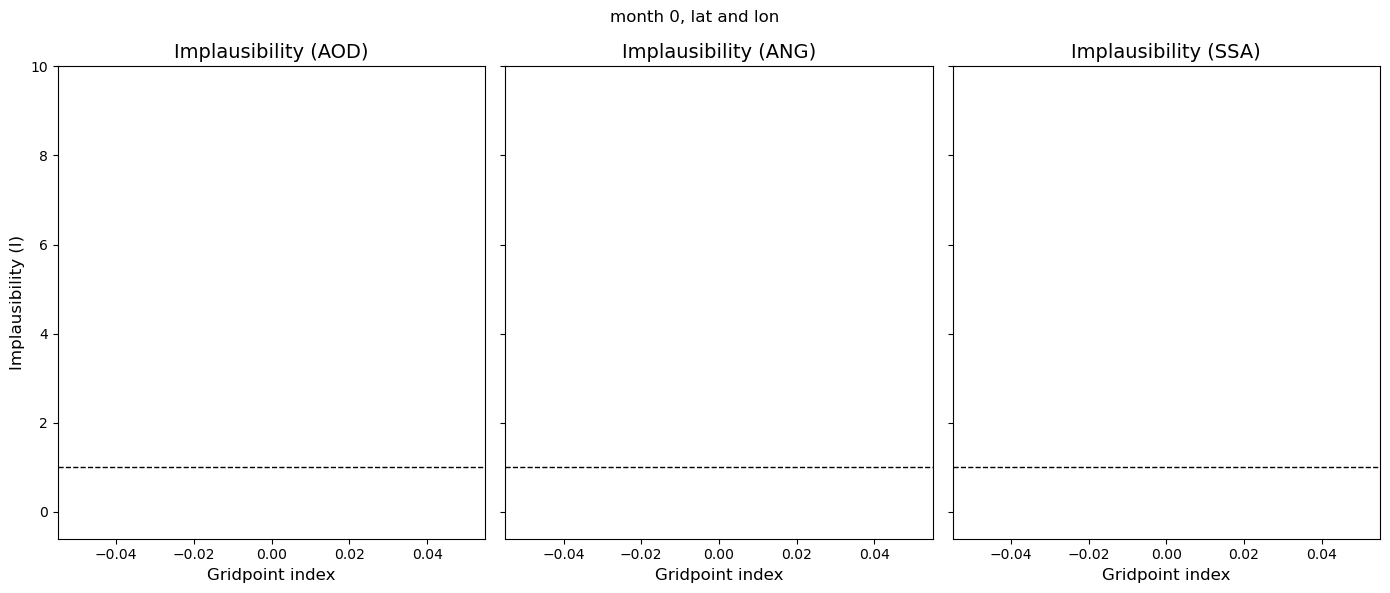

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def summary_stats(I_subset, threshold=1.0):
    """Compute required stats for implausibility distributions."""
    stats = []
    for i in range(I_subset.sizes["point"]):
        vals = I_subset.isel(point=i).values
        vals = vals[~np.isnan(vals)]  # drop NaN
        if len(vals) < 1:
            stats.append({
                "vmin": np.nan, "vmax": np.nan,
                "q2p5": np.nan, "q25": np.nan, "q50": np.nan, 
                "q75": np.nan, "q97p5": np.nan,
                "reject": np.nan
            })
        else:
            q2p5, q25, q50, q75, q97p5 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])
            vmin, vmax = np.min(vals), np.max(vals)
            reject = vmax > threshold
            stats.append({
                "vmin": vmin, "vmax": vmax,
                "q2p5": q2p5, "q25": q25, "q50": q50, 
                "q75": q75, "q97p5": q97p5,
                "reject": reject
            })
    return stats

# --- Subset region ---
lat_idx = np.arange(0, 90)
lon_idx = np.arange(0, 1)
month_ind = 0

# I_subset_aod = I_field_aod.isel(lat=lat_idx, lon=lon_idx, month = month_ind).stack(point=("lat","lon"))
# I_subset_ang = I_field_ang.isel(lat=lat_idx, lon=lon_idx, month = month_ind).stack(point=("lat","lon"))
# I_subset_ssa = I_field_ssa.isel(lat=lat_idx, lon=lon_idx, month = month_ind).stack(point=("lat","lon"))
#I_subset_ai = I_field_ai.isel(lat=lat_idx, lon=lon_idx, month = month_ind).stack(point=("lat","lon"))
I_subset_cdnc = I_field_cdnc.isel(lat=lat_idx, lon=lon_idx, month = month_ind).stack(point=("lat","lon"))


# --- Compute summaries ---
# stats_aod = summary_stats(I_subset_aod)
# stats_ang = summary_stats(I_subset_ang)
# stats_ssa = summary_stats(I_subset_ssa)
stats_cdnc = summary_stats(I_subset_cdnc)

threshold = 1

# --- Plot like Johnson et al. Fig. 4a ---
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

for ax, stats, title in zip(axes, [stats_cdnc, stats_cdnc,stats_cdnc], ["AOD", "ANG","SSA"]):
    for i, s in enumerate(stats):
      #  color = "red" if s["reject"] else "blue"
        if s["q2p5"] > threshold:
            color = "red"   # fully rejected
        elif s["q97p5"] > threshold:
            color = "blue"  # partially over threshold
        else:
            color = "blue"  # accepted

        # Full range
        ax.plot([i, i], [s["vmin"], s["vmax"]], color=color, marker="+", markersize=8, linewidth=0)
        
        # 95% CI
        ax.plot([i, i], [s["q2p5"], s["q97p5"]], color=color, linewidth=2)
        
        # IQR
        ax.plot([i-0.2, i+0.2], [s["q25"], s["q25"]], color=color, linewidth=2)
        ax.plot([i-0.2, i+0.2], [s["q75"], s["q75"]], color=color, linewidth=2)
        ax.set_ylim([-0.6,10])
        # Median
        ax.scatter(i, s["q50"], color=color, marker="s", s=40, zorder=3)
    
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Implausibility ({title})", fontsize=14)
    ax.set_xlabel("Gridpoint index", fontsize=12)
plt.suptitle(f"month {month_ind}, lat and lon")
axes[0].set_ylabel("Implausibility (I)", fontsize=12)
plt.tight_layout()
plt.show()


In [56]:
import numpy as np
import xarray as xr

def rejection_map_monthly(I_field, threshold=1, return_stats=False):
    """
    Compute monthly rejection mask, percentile statistics, and implausibility mask
    where q25 > threshold.

    Parameters
    ----------
    I_field : xr.DataArray
        Implausibility field (sample, month, lat, lon)
    threshold : float
        Threshold for rejection (default 3.5)
    return_stats : bool
        If True, also return percentile stats for later plotting.

    Returns
    -------
    reject_mask : xr.DataArray (month, lat, lon)
        Boolean array: True where q25 > threshold
    implaus_mask : xr.DataArray (sample, month, lat, lon)
        Implausibility field values where q25 > threshold; NaN elsewhere
    stats_ds : xr.Dataset (optional)
        q2.5, q25, q50, q75, q97.5, vmin, vmax fields for each cell
    """

    n_sample = I_field.sizes["sample"]
    n_month = I_field.sizes["month"]
    n_lat = I_field.sizes["lat"]
    n_lon = I_field.sizes["lon"]

    # Initialize outputs
    reject_mask = np.full((n_month, n_lat, n_lon), True)
    implaus_mask = np.full((n_sample, n_month, n_lat, n_lon), np.nan)

    if return_stats:
        q2p5_arr = np.full((n_month, n_lat, n_lon), np.nan)
        q25_arr  = np.full((n_month, n_lat, n_lon), np.nan)
        q50_arr  = np.full((n_month, n_lat, n_lon), np.nan)
        q75_arr  = np.full((n_month, n_lat, n_lon), np.nan)
        q97p5_arr= np.full((n_month, n_lat, n_lon), np.nan)
        vmin_arr = np.full((n_month, n_lat, n_lon), np.nan)
        vmax_arr = np.full((n_month, n_lat, n_lon), np.nan)

    # --- Main loop ---
    for m in range(n_month):
        print(m)

        for lat_i in range(n_lat):
            for lon_i in range(n_lon):
                vals = I_field.isel(month=m, lat=lat_i, lon=lon_i).values
                vals = vals[~np.isnan(vals)]

                # q2p5, q25, q50, q75, q97p5 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])
                # vmin, vmax = np.min(vals), np.max(vals)
                q2p5 = np.nanpercentile(vals,2.5)

                # Rejection condition (q25 > threshold)
                if np.isnan(q2p5):
                    reject_mask[m, lat_i, lon_i] = False

                elif q2p5 > threshold:
                    reject_mask[m, lat_i, lon_i] = False
                else:
                    implaus_mask[:, m, lat_i, lon_i] = I_field[:, m, lat_i, lon_i]

                # Save stats
                if return_stats:
                    q2p5_arr[m, lat_i, lon_i] = q2p5
                    q25_arr[m, lat_i, lon_i]  = q25
                    q50_arr[m, lat_i, lon_i]  = q50
                    q75_arr[m, lat_i, lon_i]  = q75
                    q97p5_arr[m, lat_i, lon_i]= q97p5
                    vmin_arr[m, lat_i, lon_i] = vmin
                    vmax_arr[m, lat_i, lon_i] = vmax

    # --- Convert to xarray objects ---
    reject_mask = xr.DataArray(
        reject_mask,
        coords={"month": I_field.month, "lat": I_field.lat, "lon": I_field.lon},
        dims=("month", "lat", "lon"),
        name="reject_mask"
    )

    implaus_mask = xr.DataArray(
        implaus_mask,
        coords={"sample": I_field.sample, "month": I_field.month, "lat": I_field.lat, "lon": I_field.lon},
        dims=("sample", "month", "lat", "lon"),
        name="implaus_mask"
    )

    if not return_stats:
        return reject_mask, implaus_mask

    stats_ds = xr.Dataset(
        {
            "q2p5": (("month", "lat", "lon"), q2p5_arr),
            "q25":  (("month", "lat", "lon"), q25_arr),
            "q50":  (("month", "lat", "lon"), q50_arr),
            "q75":  (("month", "lat", "lon"), q75_arr),
            "q97p5":(("month", "lat", "lon"), q97p5_arr),
            "vmin": (("month", "lat", "lon"), vmin_arr),
            "vmax": (("month", "lat", "lon"), vmax_arr),
        },
        coords={"month": I_field.month, "lat": I_field.lat, "lon": I_field.lon},
        attrs={"threshold": threshold}
    )

    return reject_mask, implaus_mask, stats_ds
# reject_map_aod, implaus_mask_aod = rejection_map_monthly(I_field_aod, threshold=1)
# reject_map_ang, implaus_mask_ang = rejection_map_monthly(I_field_ang, threshold=1)
# reject_map_ssa, implaus_mask_ssa = rejection_map_monthly(I_field_ssa, threshold=1)
#reject_map_ai, implaus_mask_ai = rejection_map_monthly(I_field_ai, threshold=1)
reject_map_cdnc, implaus_mask_cdnc = rejection_map_monthly(I_field_cdnc, threshold=1)

# implaus_mask_ang.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_ang.nc')
# implaus_mask_aod.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_aod.nc')

0


/home/ybhatti2/miniconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1562: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


1
2
3
4
5
6
7
8
9
10
11


63760 and 28.8% constrainable variables for CDNC (True only)


/scratch-local/ybhatti2.16560082/ipykernel_3481605/309298362.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.92])


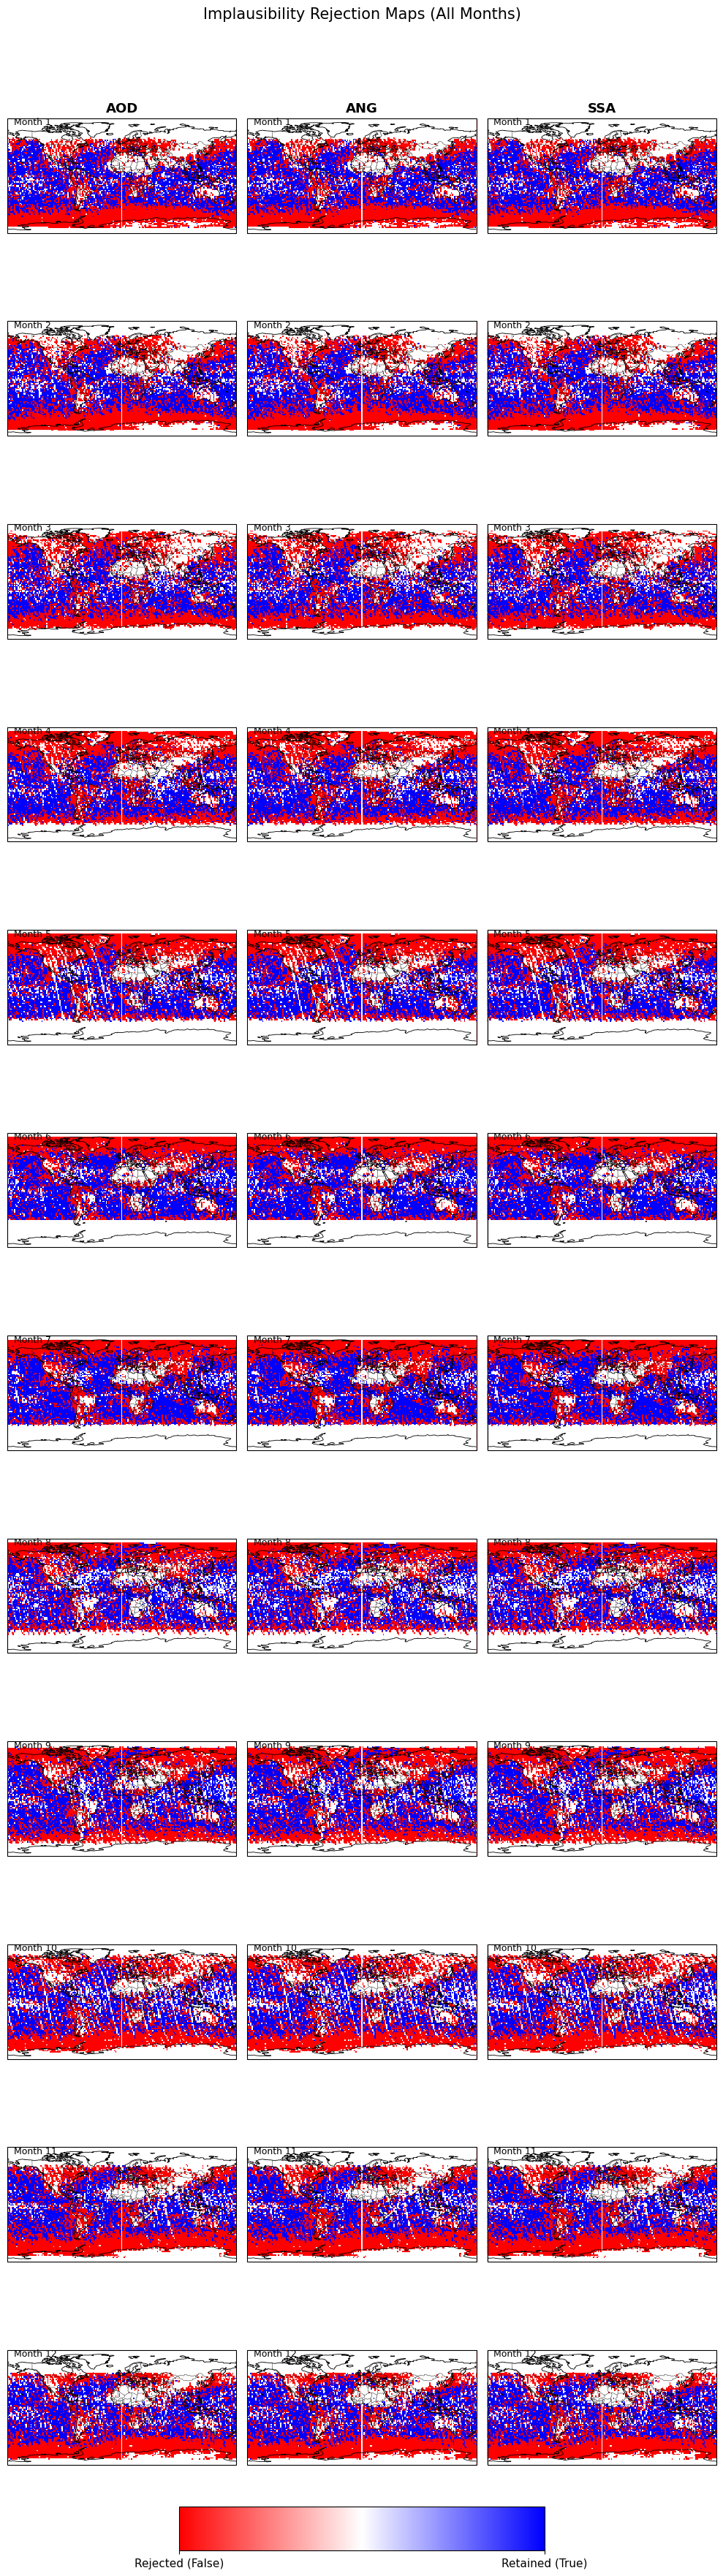

In [57]:
# --- Convert da_masked (where NaN = False, valid = True) ---
# reject_map_aod_imp = ~np.isnan(implaus_mask_aod.mean('sample'))
# print(f"{reject_map_aod_imp.sum().item()} and {(reject_map_aod_imp.sum().item()/reject_map_aod_imp.size) * 100:.1f}% constrainable variables for AOD (True only)")

# reject_map_ang_imp = ~np.isnan(implaus_mask_ang.mean('sample'))
# print(f"{reject_map_ang_imp.sum().item()} and {(reject_map_ang_imp.sum().item()/reject_map_ang_imp.size) * 100:.1f}% constrainable variables for ANG (True only)")

# reject_map_ssa_imp = ~np.isnan(implaus_mask_ssa.mean('sample'))
# print(f"{reject_map_ssa_imp.sum().item()} and {(reject_map_ssa_imp.sum().item()/reject_map_ssa_imp.size) * 100:.1f}% constrainable variables for SA (True only)")

# reject_map_ai_imp = ~np.isnan(implaus_mask_ai.mean('sample'))
# print(f"{reject_map_ai_imp.sum().item()} and {(reject_map_ai_imp.sum().item()/reject_map_ai_imp.size) * 100:.1f}% constrainable variables for AOD (True only)")

reject_map_cdnc_imp = ~np.isnan(implaus_mask_cdnc.mean('sample'))
print(f"{reject_map_cdnc_imp.sum().item()} and {(reject_map_cdnc_imp.sum().item()/reject_map_cdnc_imp.size) * 100:.1f}% constrainable variables for CDNC (True only)")

# --- Setup figure for 12 months (2 columns: AOD left, ANG right) ---
fig, axes = plt.subplots(
    nrows=12, ncols=3, figsize=(10, 40),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, month in enumerate(range(1, 13)):
    for j, (reject_map, title) in enumerate(zip(
        [reject_map_cdnc_imp, reject_map_cdnc_imp, reject_map_cdnc_imp],
        ["AOD", "ANG", "SSA"]
    )):
        ax = axes[i, j]
        ax.coastlines(resolution="110m", linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.set_global()
        ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

        if i == 0:
            ax.set_title(title, fontsize=13, fontweight="bold")
        ax.text(-170, 80, f"Month {month}", fontsize=9, ha="left")

        # Select monthly map
        rm = reject_map.sel(month=month)
        vm = valid_mask.sel(month=month)

        # Plot retained (True=blue) vs rejected (False=red)
        img = ax.pcolormesh(
            rm.lon, rm.lat, rm.astype(int),
            cmap="bwr_r", vmin=0, vmax=1,
            transform=ccrs.PlateCarree()
        )

        # --- Mask invalid (False/NaN) pixels only and plot white ---
        invalid_mask = ~vm
        invalid_mask = invalid_mask.where(invalid_mask, np.nan)  # keep only False cells
        ax.pcolormesh(
            rm.lon, rm.lat, invalid_mask,
            cmap="Greys_r", vmin=0, vmax=1,
            transform=ccrs.PlateCarree(),
            alpha=1.0
        )

# --- Shared colorbar ---
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.015])
cbar = plt.colorbar(img, cax=cbar_ax, orientation='horizontal', ticks=[0, 1])
cbar.ax.set_xticklabels(["Rejected (False)", "Retained (True)"])
cbar.ax.tick_params(labelsize=11)

plt.suptitle("Implausibility Rejection Maps (All Months)", fontsize=15, y=0.92)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/Implausible_Map_Reject.png",dpi=100,bbox_inches = 'tight')
plt.show()


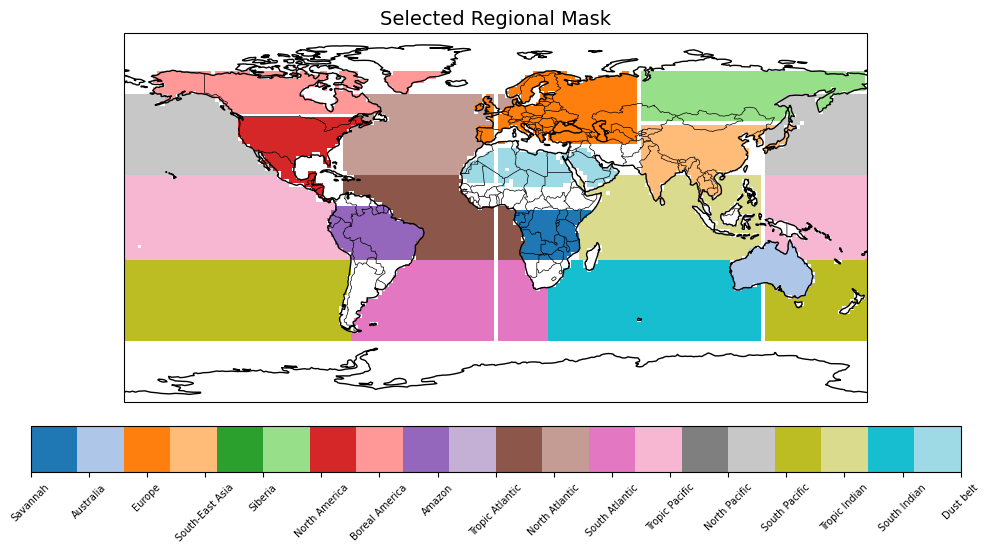

In [58]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
ds_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask.nc')

# --- Your selected region names ---
region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia','Savannah',
    'North America', 'Boreal America',
    'Amazon', 'North Atlantic', 'South Atlantic', 'North Pacific',
    'South Pacific','Tropic Atlantic', 'Tropic Pacific', 'Tropic Indian', 'South Indian',
    'Dust belt','Shipping'
]

# --- Select only those regions ---
mask_subset = ds_mask.regional_mask.sel(region=ds_mask.region_name.isin(region_names))
selected_names = ds_mask.region_name.sel(region=ds_mask.region_name.isin(region_names))

# --- Combine into one labeled map ---
mask_plot = np.full(mask_subset.isel(region=0).shape, np.nan)
for i, name in enumerate(selected_names.values):
    region_mask = mask_subset.isel(region=i)
    mask_plot = np.where(region_mask > 0.5, i, mask_plot)

# --- Plot ---
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds_mask.lon, ds_mask.lat, mask_plot,
    cmap='tab20', transform=ccrs.PlateCarree()
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Selected Regional Mask", fontsize=14)

# --- Add colorbar with region labels ---
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_ticks(np.arange(len(selected_names)))
cbar.set_ticklabels(selected_names.values, rotation=45)
cbar.ax.tick_params(labelsize=7)

plt.show()


In [ ]:
import timeit

def Interpolate_Regional_uncertainty(Predicted, region_name, ds_mask):
    """
    Interpolates Predicted data onto the grid of the selected region
    and applies the regional mask.
    """
    # Extract the region-specific mask
    region_mask = ds_mask.sel(
        region=ds_mask.where(ds_mask.region_name == region_name, drop=True).region[0]
    )
    # Mask the data better
    # # Interpolate predicted field onto the regional grid
    # Predicted_interp = Predicted.interp(
    #     lat=region_mask.lat, lon=region_mask.lon, method="nearest"
    # )

    # Apply the mask (keep only valid region cells)
    masked_array = Predicted.where(region_mask)
    return masked_array

implaus_mask_aaod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_aaod_23000.nc').__xarray_dataarray_variable__
implaus_mask_aod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_aod_23000.nc').__xarray_dataarray_variable__
implaus_mask_ang = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_ang_23000.nc').__xarray_dataarray_variable__
implaus_mask_ssa = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_ssa_23000.nc').__xarray_dataarray_variable__

reject_map_aaod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/reject_map_aaod_23000.nc').reject_mask
reject_map_aod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/reject_map_aod_23000.nc').reject_mask
reject_map_ang = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/reject_map_ang_23000.nc').reject_mask
reject_map_ssa = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/reject_map_ssa_23000.nc').reject_mask


emulated_aaod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/emulated_aaod_23000.nc')['Emulated AAOD']
emulated_aod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/emulated_aod_23000.nc')['Emulated TAU_2D_550nm']
emulated_ang = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/emulated_ang_23000.nc')['Emulated ANG_440nm_670nm']
emulated_ssa = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/emulated_ssa_23000.nc')['Emulated __xarray_dataarray_variable__']


regional_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask.nc').regional_mask.load()
ds_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask.nc')

region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia','Savannah',
    'North America', 'Boreal America',
    'Amazon', 'North Atlantic', 'South Atlantic', 'North Pacific',
    'South Pacific', 'Tropic Atlantic' , 'Tropic Pacific', 'Tropic Indian', 'South Indian',
    'Dust belt'
]

# --- Prepare observation masks ---
obs_vec_aod = AOD[:, -1].groupby('time.month').mean()
valid_mask_aod = ~np.isnan(obs_vec_aod)
emulated_aod_masked_rejected = emulated_aod.where(reject_map_aod).where(valid_mask_aod)
obs_masked_rejected_aod = obs_vec_aod.where(reject_map_aod)
# emulated_aod_ppe_masked_rejected = emulated_aod_ppe.where(reject_map_aod)

obs_vec_ang = ANG[:, -1].groupby('time.month').mean()
valid_mask_ang = ~np.isnan(obs_vec_ang)
emulated_ang_masked_rejected = emulated_ang.where(reject_map_ang).where(valid_mask_ang)
obs_masked_rejected_ang = obs_vec_ang.where(reject_map_ang)
# emulated_ang_ppe_masked_rejected = emulated_ang_ppe.where(reject_map_ang)

obs_vec_ssa = SSA_masked[:, -1].groupby('time.month').mean()
valid_mask_ssa = ~np.isnan(obs_vec_ssa)
emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa)
obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa)
# emulated_ssa_ppe_masked_rejected = emulated_ssa_ppe.where(reject_map_ssa)

# obs_vec_aaod = AAOD[:, -1].groupby('time.month').mean()
# valid_mask_ssa = ~np.isnan(obs_vec_ssa)
# emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa)
# obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa)

# --- Containers for results ---
Region_data_aod = []
Region_data_ang = []
Region_data_ssa = []

Region_data_aod_ppe = []
Region_data_ang_ppe = []

Region_OBS_aod = []
Region_OBS_ang = []
Region_OBS_ssa = []

for region_name in region_names:
    print(region_name)
    region_gp_aod = Interpolate_Regional_uncertainty(
        emulated_aod_masked_rejected, region_name, regional_mask
    ).transpose("sample", "month", "lat", "lon")

    # valid_mask = ~region_gp_aod.isnull().all(dim='month')
    gpmeans_aod = areaweight(region_gp_aod, region_gp_aod.lat)  # (sample, month)
    Region_data_aod.append(gpmeans_aod.values)

    # --- OBSERVATION ---
    region_obs_aod = Interpolate_Regional_uncertainty(
        obs_masked_rejected_aod, region_name, regional_mask
    ).transpose("month", "lat", "lon")
    # Identify where all values are NaN for each (sample, month)
    # valid_mask = ~region_obs_aod.isnull().all(dim='month')
    obsmeans_aod = areaweight(region_obs_aod, region_obs_aod.lat)  # (month)
    # obsmeans_aod = obsmeans_aod.where(~all_nan_mask)
    Region_OBS_aod.append(obsmeans_aod.values)
    print('test ANG')

    # --- ANG ---
    region_gp_ang = Interpolate_Regional_uncertainty(
        emulated_ang_masked_rejected, region_name, regional_mask
    ).transpose("sample", "month", "lat", "lon")
    all_nan_mask = region_gp_ang.isnull().all(dim=("lat", "lon"))
    gpmeans_ang = areaweight(region_gp_ang, region_gp_ang.lat)
    # gpmeans_ang = gpmeans_ang.where(~all_nan_mask)
    Region_data_ang.append(gpmeans_ang.values)

    # # --- ANG PPE ---
    # region_gp_ang_ppe = Interpolate_Regional_uncertainty(
    #     emulated_ang_ppe_masked_rejected, r, regions_nn
    # ).transpose("sample", "month", "lat", "lon")
    # all_nan_mask = region_gp_ang_ppe.isnull().all(dim=("lat", "lon"))
    # gpmeans_ang = areaweight(region_gp_ang_ppe, region_gp_ang_ppe.lat)
    # gpmeans_ang = gpmeans_ang.where(~all_nan_mask)
    # Region_data_ang_ppe.append(gpmeans_ang.values)

    # --- OBSERVATION ---
    region_obs_ang = Interpolate_Regional_uncertainty(
        obs_vec_ang, region_name, regional_mask
    ).transpose("month", "lat", "lon")
    all_nan_mask = region_obs_ang.isnull().all(dim=("lat", "lon"))

    obsmeans_ang = areaweight(region_obs_ang, region_obs_ang.lat)  # (sample, month)
    # Region_OBS_ang.append(xr.where(obsmeans_ang == 0, np.nan, obsmeans_ang).values)

    # obsmeans_ang = obsmeans_ang.where(~all_nan_mask)
    Region_OBS_ang.append(obsmeans_ang.values)
    print('test SSA')
    # --- SSA ---
    # if "Ocean" not in region_name:
    region_gp_ssa_ppe = Interpolate_Regional_uncertainty(
        emulated_ssa_masked_rejected,  region_name, regional_mask
    ).transpose("sample", "month", "lat", "lon")
    all_nan_mask = region_gp_ssa_ppe.isnull().all(dim=("lat", "lon"))
    gpmeans_ssa = areaweight(region_gp_ssa_ppe, region_gp_ssa_ppe.lat)
    # gpmeans_ssa = gpmeans_ssa.where(~all_nan_mask)
    Region_data_ssa.append(gpmeans_ssa.values)

    # --- SSA OBSERVATION ---
    region_obs_ssa = Interpolate_Regional_uncertainty(
        obs_masked_rejected_ssa,  region_name, regional_mask
    ).transpose("month", "lat", "lon")
    all_nan_mask = region_obs_ssa.isnull().all(dim=("lat", "lon"))

    obsmeans_ssa = areaweight(region_obs_ssa, region_obs_ssa.lat)  # (sample, month)
    # Region_OBS_ang.append(xr.where(obsmeans_ang == 0, np.nan, obsmeans_ang).values)
    # obsmeans_ssa = obsmeans_ssa.where(~all_nan_mask)
    Region_OBS_ssa.append(obsmeans_ssa.values)
    # else:
    #     # For ocean regions, append NaNs with correct shape
    #     n_samples = emulated_ssa_masked_rejected.sizes["sample"]
    #     n_months = 12
    #     Region_data_ssa.append(np.full((n_samples, n_months), np.nan))
    #     Region_OBS_ssa.append(np.full((n_months,), np.nan))
print('done all regions')
# --- Convert lists to arrays ---
Region_data_aod = np.array(Region_data_aod)   # (region, sample, month)
Region_data_ang = np.array(Region_data_ang)
Region_data_ssa = np.array(Region_data_ssa)

Region_OBS_aod = np.array(Region_OBS_aod)     # (region, month)
Region_OBS_ang = np.array(Region_OBS_ang)
Region_OBS_ssa = np.array(Region_OBS_ssa)

# Region_data_aod_ppe = np.array(Region_data_aod_ppe)   # (region, sample, month)
# Region_data_ang_ppe = np.array(Region_data_ang_ppe)

# --- Expand obs to match sample dimension (add new "sample=-1") ---
# Append obs along new sample dimension
Region_data_aod = np.concatenate(
    [Region_data_aod, Region_OBS_aod[:, np.newaxis, :]], axis=1
)
Region_data_ang = np.concatenate(
    [Region_data_ang, Region_OBS_ang[:, np.newaxis, :]], axis=1
)

Region_data_ssa = np.concatenate(
    [Region_data_ssa, Region_OBS_ssa[:, np.newaxis, :]], axis=1
)

# --- Create sample coordinate (add -1 at the end) ---
sample_coords = np.append(emulated_ang_masked_rejected.sample.values, -1)

# --- Convert to DataArray ---
Region_data_aod = xr.DataArray(
    Region_data_aod,
    dims=("region", "sample", "month"),
    coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
    name="AOD"
)

Region_data_ang = xr.DataArray(
    Region_data_ang,
    dims=("region", "sample", "month"),
    coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
    name="ANG"
)

Region_data_ssa = xr.DataArray(
    Region_data_ssa,
    dims=("region", "sample", "month"),
    coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
    name="SSA"
)

# Region_data_aod_ppe = xr.DataArray(
#     Region_data_aod_ppe,
#     dims=("region", "sample", "month"),
#     coords={"region": region_names, "sample": emulated_ang_ppe_masked_rejected.sample.values, "month": np.arange(1, 13)},
#     name="AOD_PPE"
# )

# Region_data_ang_ppe = xr.DataArray(
#     Region_data_ang_ppe,
#     dims=("region", "sample", "month"),
#     coords={"region": region_names, "sample": emulated_ang_ppe_masked_rejected.sample.values, "month": np.arange(1, 13)},
#     name="ANG_PPE"
# )

# --- Combine and save ---
# --- Combine and save ---
regional_dataset = xr.Dataset({
    "AOD": Region_data_aod,
    "ANG": Region_data_ang,
    "SSA": Region_data_ssa
})
print('done')

print(f"Memory usage: {get_memory_usage()} GB")


# Step 2: Compute monthly Regional means using Retained Cell

In [14]:
# import numpy as np
# import xarray as xr

# # --- Define function to interpolate and mask regional data ---
# def Interpolate_Regional_uncertainty(Predicted, mask_number, Regions_nc):
#     mask = Regions_nc == mask_number
#     regional_array = Regions_nc.where(mask, drop=True)

#     # Interpolate predicted field onto regional grid
#     Predicted_interp = Predicted.interp(
#         lat=regional_array.lat, lon=regional_array.lon, method="nearest"
#     )

#     # Apply mask: retain only cells matching region number
#     masked_array = Predicted_interp.where(regional_array == mask_number)
#     return masked_array

# # --- Load region mask file ---
# regions_nn = xr.open_dataset('/home/ybhatti/prjs1076/Processed_Data/reg_18_regridded_nn.nc').reg
# regional_mask = xr.open_dataset('/gpfs/home3/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/Regional_Mask.nc').regional_mask.load()
# # --- Define region categories ---
# regions_cat = {
#     "Arctic Ocean": 1, "Arctic Land": 2, "North Pacific Ocean": 3, "North America": 4,
#     "North Atlantic Ocean": 5, "Europe": 6, "Asia": 7, "Tropical Pacific Ocean": 8,
#     "Tropical Atlantic Ocean": 9, "Africa": 10, "Tropical Indian Ocean": 11,
#     "South Pacific Ocean": 12, "South America": 13, "South Atlantic Ocean": 14,
#     "South Indian Ocean": 15, "Australia": 16, "Antarctic Ocean": 17, "Antarctica": 18
# }


# # --- Prepare observation masks ---
# obs_vec_aod = AOD[:, -1].groupby('time.month').mean()
# valid_mask_aod = ~np.isnan(obs_vec_aod)
# emulated_aod_masked_rejected = emulated_aod.where(reject_map_aod).where(valid_mask_aod)
# obs_masked_rejected_aod = obs_vec_aod.where(reject_map_aod)
# # emulated_aod_ppe_masked_rejected = emulated_aod_ppe.where(reject_map_aod)

# obs_vec_ang = ANG[:, -1].groupby('time.month').mean()
# valid_mask_ang = ~np.isnan(obs_vec_ang)
# emulated_ang_masked_rejected = emulated_ang.where(reject_map_ang).where(valid_mask_ang)
# obs_masked_rejected_ang = obs_vec_ang.where(reject_map_ang)
# # emulated_ang_ppe_masked_rejected = emulated_ang_ppe.where(reject_map_ang)

# obs_vec_ssa = SSA_masked[:, -1].groupby('time.month').mean()
# valid_mask_ssa = ~np.isnan(obs_vec_ssa)
# emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa)
# obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa)
# # emulated_ssa_ppe_masked_rejected = emulated_ssa_ppe.where(reject_map_ssa)

# # obs_vec_aaod = AAOD[:, -1].groupby('time.month').mean()
# # valid_mask_ssa = ~np.isnan(obs_vec_ssa)
# # emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa)
# # obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa)

# # --- Containers for results ---
# Region_data_aod = []
# Region_data_ang = []
# Region_data_ssa = []

# Region_data_aod_ppe = []
# Region_data_ang_ppe = []

# region_names = list(regions_cat.keys())
# Region_OBS_aod = []
# Region_OBS_ang = []
# Region_OBS_ssa = []

# # --- Loop over all regions ---
# for region_name, r in regions_cat.items():
#     print(region_name)
#     # --- AOD ---
#     region_gp_aod = Interpolate_Regional_uncertainty(
#         emulated_aod_masked_rejected, r, regions_nn
#     ).transpose("sample", "month", "lat", "lon")
#     # Identify where all values are NaN for each (sample, month)
#     all_nan_mask = region_gp_aod.isnull().all(dim=("lat", "lon"))
#     # Perform area weighting as usual
#     gpmeans_aod = areaweight(region_gp_aod, region_gp_aod.lat)
#     # Reassign NaN where the entire region was NaN
#     gpmeans_aod = gpmeans_aod.where(~all_nan_mask)
#     Region_data_aod.append(gpmeans_aod.values)

#     # # --- AOD PPE ---
#     # region_gp_aod_ppe = Interpolate_Regional_uncertainty(
#     #     emulated_ang_ppe_masked_rejected, r, regions_nn
#     # ).transpose("sample", "month", "lat", "lon")
#     # # Identify where all values are NaN for each (sample, month)
#     # all_nan_mask = region_gp_aod_ppe.isnull().all(dim=("lat", "lon"))
#     # # Perform area weighting as usual
#     # gpmeans_aod = areaweight(region_gp_aod_ppe, region_gp_aod_ppe.lat)
#     # # Reassign NaN where the entire region was NaN
#     # gpmeans_aod = gpmeans_aod.where(~all_nan_mask)
#     # Region_data_aod_ppe.append(gpmeans_aod.values)

#     # --- OBSERVATION ---
#     region_obs_aod = Interpolate_Regional_uncertainty(
#         obs_masked_rejected_aod, r, regions_nn
#     ).transpose("month", "lat", "lon")
#     # Identify where all values are NaN for each (sample, month)
#     all_nan_mask = region_obs_aod.isnull().all(dim=("lat", "lon"))
#     obsmeans_aod = areaweight(region_obs_aod, region_obs_aod.lat)  # (sample, month)
#     obsmeans_aod = obsmeans_aod.where(~all_nan_mask)
#    # gpmeans_aod_mean = gpmeans_aod.mean(dim="sample")           # regional mean (month)
#     # Region_OBS_aod.append(xr.where(obsmeans_aod == 0, np.nan, obsmeans_aod).values)
#     Region_OBS_aod.append(obsmeans_aod.values)

#     # --- ANG ---
#     region_gp_ang = Interpolate_Regional_uncertainty(
#         emulated_ang_masked_rejected, r, regions_nn
#     ).transpose("sample", "month", "lat", "lon")
#     all_nan_mask = region_gp_ang.isnull().all(dim=("lat", "lon"))
#     gpmeans_ang = areaweight(region_gp_ang, region_gp_ang.lat)
#     gpmeans_ang = gpmeans_ang.where(~all_nan_mask)
#     Region_data_ang.append(gpmeans_ang.values)

#     # # --- ANG PPE ---
#     # region_gp_ang_ppe = Interpolate_Regional_uncertainty(
#     #     emulated_ang_ppe_masked_rejected, r, regions_nn
#     # ).transpose("sample", "month", "lat", "lon")
#     # all_nan_mask = region_gp_ang_ppe.isnull().all(dim=("lat", "lon"))
#     # gpmeans_ang = areaweight(region_gp_ang_ppe, region_gp_ang_ppe.lat)
#     # gpmeans_ang = gpmeans_ang.where(~all_nan_mask)
#     # Region_data_ang_ppe.append(gpmeans_ang.values)

#     # --- OBSERVATION ---
#     region_obs_ang = Interpolate_Regional_uncertainty(
#         obs_vec_ang, r, regions_nn
#     ).transpose("month", "lat", "lon")
#     all_nan_mask = region_obs_ang.isnull().all(dim=("lat", "lon"))

#     obsmeans_ang = areaweight(region_obs_ang, region_obs_ang.lat)  # (sample, month)
#     # Region_OBS_ang.append(xr.where(obsmeans_ang == 0, np.nan, obsmeans_ang).values)

#     obsmeans_ang = obsmeans_ang.where(~all_nan_mask)
#     Region_OBS_ang.append(obsmeans_ang.values)

#     # --- SSA ---
#     # if "Ocean" not in region_name:
#     region_gp_ssa_ppe = Interpolate_Regional_uncertainty(
#         emulated_ssa_masked_rejected, r, regions_nn
#     ).transpose("sample", "month", "lat", "lon")
#     all_nan_mask = region_gp_ssa_ppe.isnull().all(dim=("lat", "lon"))
#     gpmeans_ssa = areaweight(region_gp_ssa_ppe, region_gp_ssa_ppe.lat)
#     gpmeans_ssa = gpmeans_ssa.where(~all_nan_mask)
#     Region_data_ssa.append(gpmeans_ssa.values)

#     # --- SSA OBSERVATION ---
#     region_obs_ssa = Interpolate_Regional_uncertainty(
#         obs_masked_rejected_ssa, r, regions_nn
#     ).transpose("month", "lat", "lon")
#     all_nan_mask = region_obs_ssa.isnull().all(dim=("lat", "lon"))

#     obsmeans_ssa = areaweight(region_obs_ssa, region_obs_ssa.lat)  # (sample, month)
#     # Region_OBS_ang.append(xr.where(obsmeans_ang == 0, np.nan, obsmeans_ang).values)
#     obsmeans_ssa = obsmeans_ssa.where(~all_nan_mask)
#     Region_OBS_ssa.append(obsmeans_ssa.values)
#     # else:
#     #     # For ocean regions, append NaNs with correct shape
#     #     n_samples = emulated_ssa_masked_rejected.sizes["sample"]
#     #     n_months = 12
#     #     Region_data_ssa.append(np.full((n_samples, n_months), np.nan))
#     #     Region_OBS_ssa.append(np.full((n_months,), np.nan))

# # --- Convert lists to arrays ---
# Region_data_aod = np.array(Region_data_aod)   # (region, sample, month)
# Region_data_ang = np.array(Region_data_ang)
# Region_data_ssa = np.array(Region_data_ssa)

# Region_OBS_aod = np.array(Region_OBS_aod)     # (region, month)
# Region_OBS_ang = np.array(Region_OBS_ang)
# Region_OBS_ssa = np.array(Region_OBS_ssa)

# # Region_data_aod_ppe = np.array(Region_data_aod_ppe)   # (region, sample, month)
# # Region_data_ang_ppe = np.array(Region_data_ang_ppe)

# # --- Expand obs to match sample dimension (add new "sample=-1") ---
# # Append obs along new sample dimension
# Region_data_aod = np.concatenate(
#     [Region_data_aod, Region_OBS_aod[:, np.newaxis, :]], axis=1
# )
# Region_data_ang = np.concatenate(
#     [Region_data_ang, Region_OBS_ang[:, np.newaxis, :]], axis=1
# )

# Region_data_ssa = np.concatenate(
#     [Region_data_ssa, Region_OBS_ssa[:, np.newaxis, :]], axis=1
# )

# # --- Create sample coordinate (add -1 at the end) ---
# sample_coords = np.append(emulated_ang_masked_rejected.sample.values, -1)

# # --- Convert to DataArray ---
# Region_data_aod = xr.DataArray(
#     Region_data_aod,
#     dims=("region", "sample", "month"),
#     coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
#     name="AOD"
# )

# Region_data_ang = xr.DataArray(
#     Region_data_ang,
#     dims=("region", "sample", "month"),
#     coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
#     name="ANG"
# )

# Region_data_ssa = xr.DataArray(
#     Region_data_ssa,
#     dims=("region", "sample", "month"),
#     coords={"region": region_names, "sample": sample_coords, "month": np.arange(1, 13)},
#     name="SSA"
# )

# # Region_data_aod_ppe = xr.DataArray(
# #     Region_data_aod_ppe,
# #     dims=("region", "sample", "month"),
# #     coords={"region": region_names, "sample": emulated_ang_ppe_masked_rejected.sample.values, "month": np.arange(1, 13)},
# #     name="AOD_PPE"
# # )

# # Region_data_ang_ppe = xr.DataArray(
# #     Region_data_ang_ppe,
# #     dims=("region", "sample", "month"),
# #     coords={"region": region_names, "sample": emulated_ang_ppe_masked_rejected.sample.values, "month": np.arange(1, 13)},
# #     name="ANG_PPE"
# # )

# # --- Combine and save ---
# # --- Combine and save ---
# regional_dataset = xr.Dataset({
#     "AOD": Region_data_aod,
#     "ANG": Region_data_ang,
#     "SSA": Region_data_ssa
# })


# # # --- Combine and save ---
# # regional_dataset_ppe = xr.Dataset({
# #     "AOD": Region_data_aod_ppe,
# #     "ANG": Region_data_ang_ppe
# # })

# # regional_dataset.to_netcdf("Regional_Uncertainty_Monthly.nc")


Arctic Ocean
Arctic Land
North Pacific Ocean
North America
North Atlantic Ocean
Europe
Asia
Tropical Pacific Ocean
Tropical Atlantic Ocean
Africa
Tropical Indian Ocean
South Pacific Ocean
South America
South Atlantic Ocean
South Indian Ocean
Australia
Antarctic Ocean
Antarctica


# Step 3: Use uncertainties from observation and constrain PPE using monthly regional averages

In [57]:
#Lets try trying extreme regions :
ds_filtered = regional_dataset.where(~regional_dataset.region.isin(["Arctic Land", "Antarctica","Antarctica Ocean", "Arctic Ocean"]), drop=True)

# We need to stack region and month so that each ensemble member * 216.
constrainable_AOD = ds_filtered.AOD.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_ANG = ds_filtered.ANG.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_SSA = ds_filtered.SSA.stack(z=("region","month")).dropna(dim="z", how="any")

# We then need to compute the absolute difference between ensemble to obs for each ensemble member:
# obs_AOD = xr.where(constrainable_AOD[-1] == 0, np.nan, constrainable_AOD[-1]).values
# obs_ANG = xr.where(constrainable_ANG[-1] == 0, np.nan, constrainable_ANG[-1]).values

Abs_Diff_AOD = abs(constrainable_AOD[:len(constrainable_AOD.sample)-1] - constrainable_AOD[-1])
Abs_Diff_ANG = abs(constrainable_ANG[:len(constrainable_ANG.sample)-1] - constrainable_ANG[-1])
Abs_Diff_SSA = abs(constrainable_SSA[:len(constrainable_SSA.sample)-1] - constrainable_SSA[-1])

# --- AOD: compute threshold per grid cell (max of 0.02 or 10%) ---
obs_AOD = constrainable_AOD[-1]                     # observation
obs_SSA = constrainable_SSA[-1]                     # observation

#threshold_AOD = xr.ufuncs.maximum(0.045, 0.25 * obs_AOD)  # element-wise max
threshold_AOD = xr.ufuncs.maximum(0.035, 0.15 * obs_AOD)  # element-wise max
#threshold_SSA = xr.ufuncs.maximum(0.01, 0.10 * obs_SSA)  # element-wise max

fraction_per_sample_aod = (Abs_Diff_AOD < threshold_AOD).mean(dim="z")
fraction_per_sample_ang = (Abs_Diff_ANG < 0.25).mean(dim="z")
#fraction_per_sample_ssa = (Abs_Diff_SSA < threshold_SSA).mean(dim="z")
fraction_per_sample_ssa = (Abs_Diff_SSA < 0.045).mean(dim="z")

#fraction_per_sample_ang = (Abs_Diff_ANG < 0.2).mean(dim="z")

test = xr.concat(fraction_per_sample_ang,fraction_per_sample_aod)
test = xr.concat(test,fraction_per_sample_ssa)

accepted_overall = test > 0.67

# --- Identify accepted samples (where > 67% of z-points are within threshold) ---
accepted_aod = fraction_per_sample_aod > 0.67
accepted_ang = fraction_per_sample_ang > 0.67
accepted_ssa= fraction_per_sample_ssa> 0.67
# --- Combine: only accept samples passing both AOD and ANG constraints ---
accepted_both = accepted_aod & accepted_ang & accepted_ssa
accepted_both = accepted_aod & accepted_ang 

# --- Compute final percentage ---
accepted_pct = 100 * accepted_both.sum().item() / accepted_both.size
accepted_pct_overall = 100 * accepted_overall.sum().item() / accepted_overall.size

print(f"Accepted AOD-only = {(accepted_aod.sum().item() / accepted_aod.size) * 100:.2f}%")
print(f"Accepted ANG-only = {(accepted_ang.sum().item() / accepted_ang.size) * 100:.2f}%")
print(f"Accepted SSA-only = {(accepted_ssa.sum().item() / accepted_ssa.size) * 100:.2f}%")
print(f"Accepted BOTH = {accepted_pct:.2f}%")
print(f"Accepted aod+ang togehter = {(accepted_overall.sum().item() / accepted_overall.size) * 100:.2f}%")

print(f"Memory usage: {get_memory_usage()} GB")


Accepted AOD-only = 26.21%
Accepted ANG-only = 41.73%
Accepted SSA-only = 20.66%
Accepted BOTH = 4.31%
Accepted aod+ang togehter = 41.73%
Memory usage: 404.253405184 GB


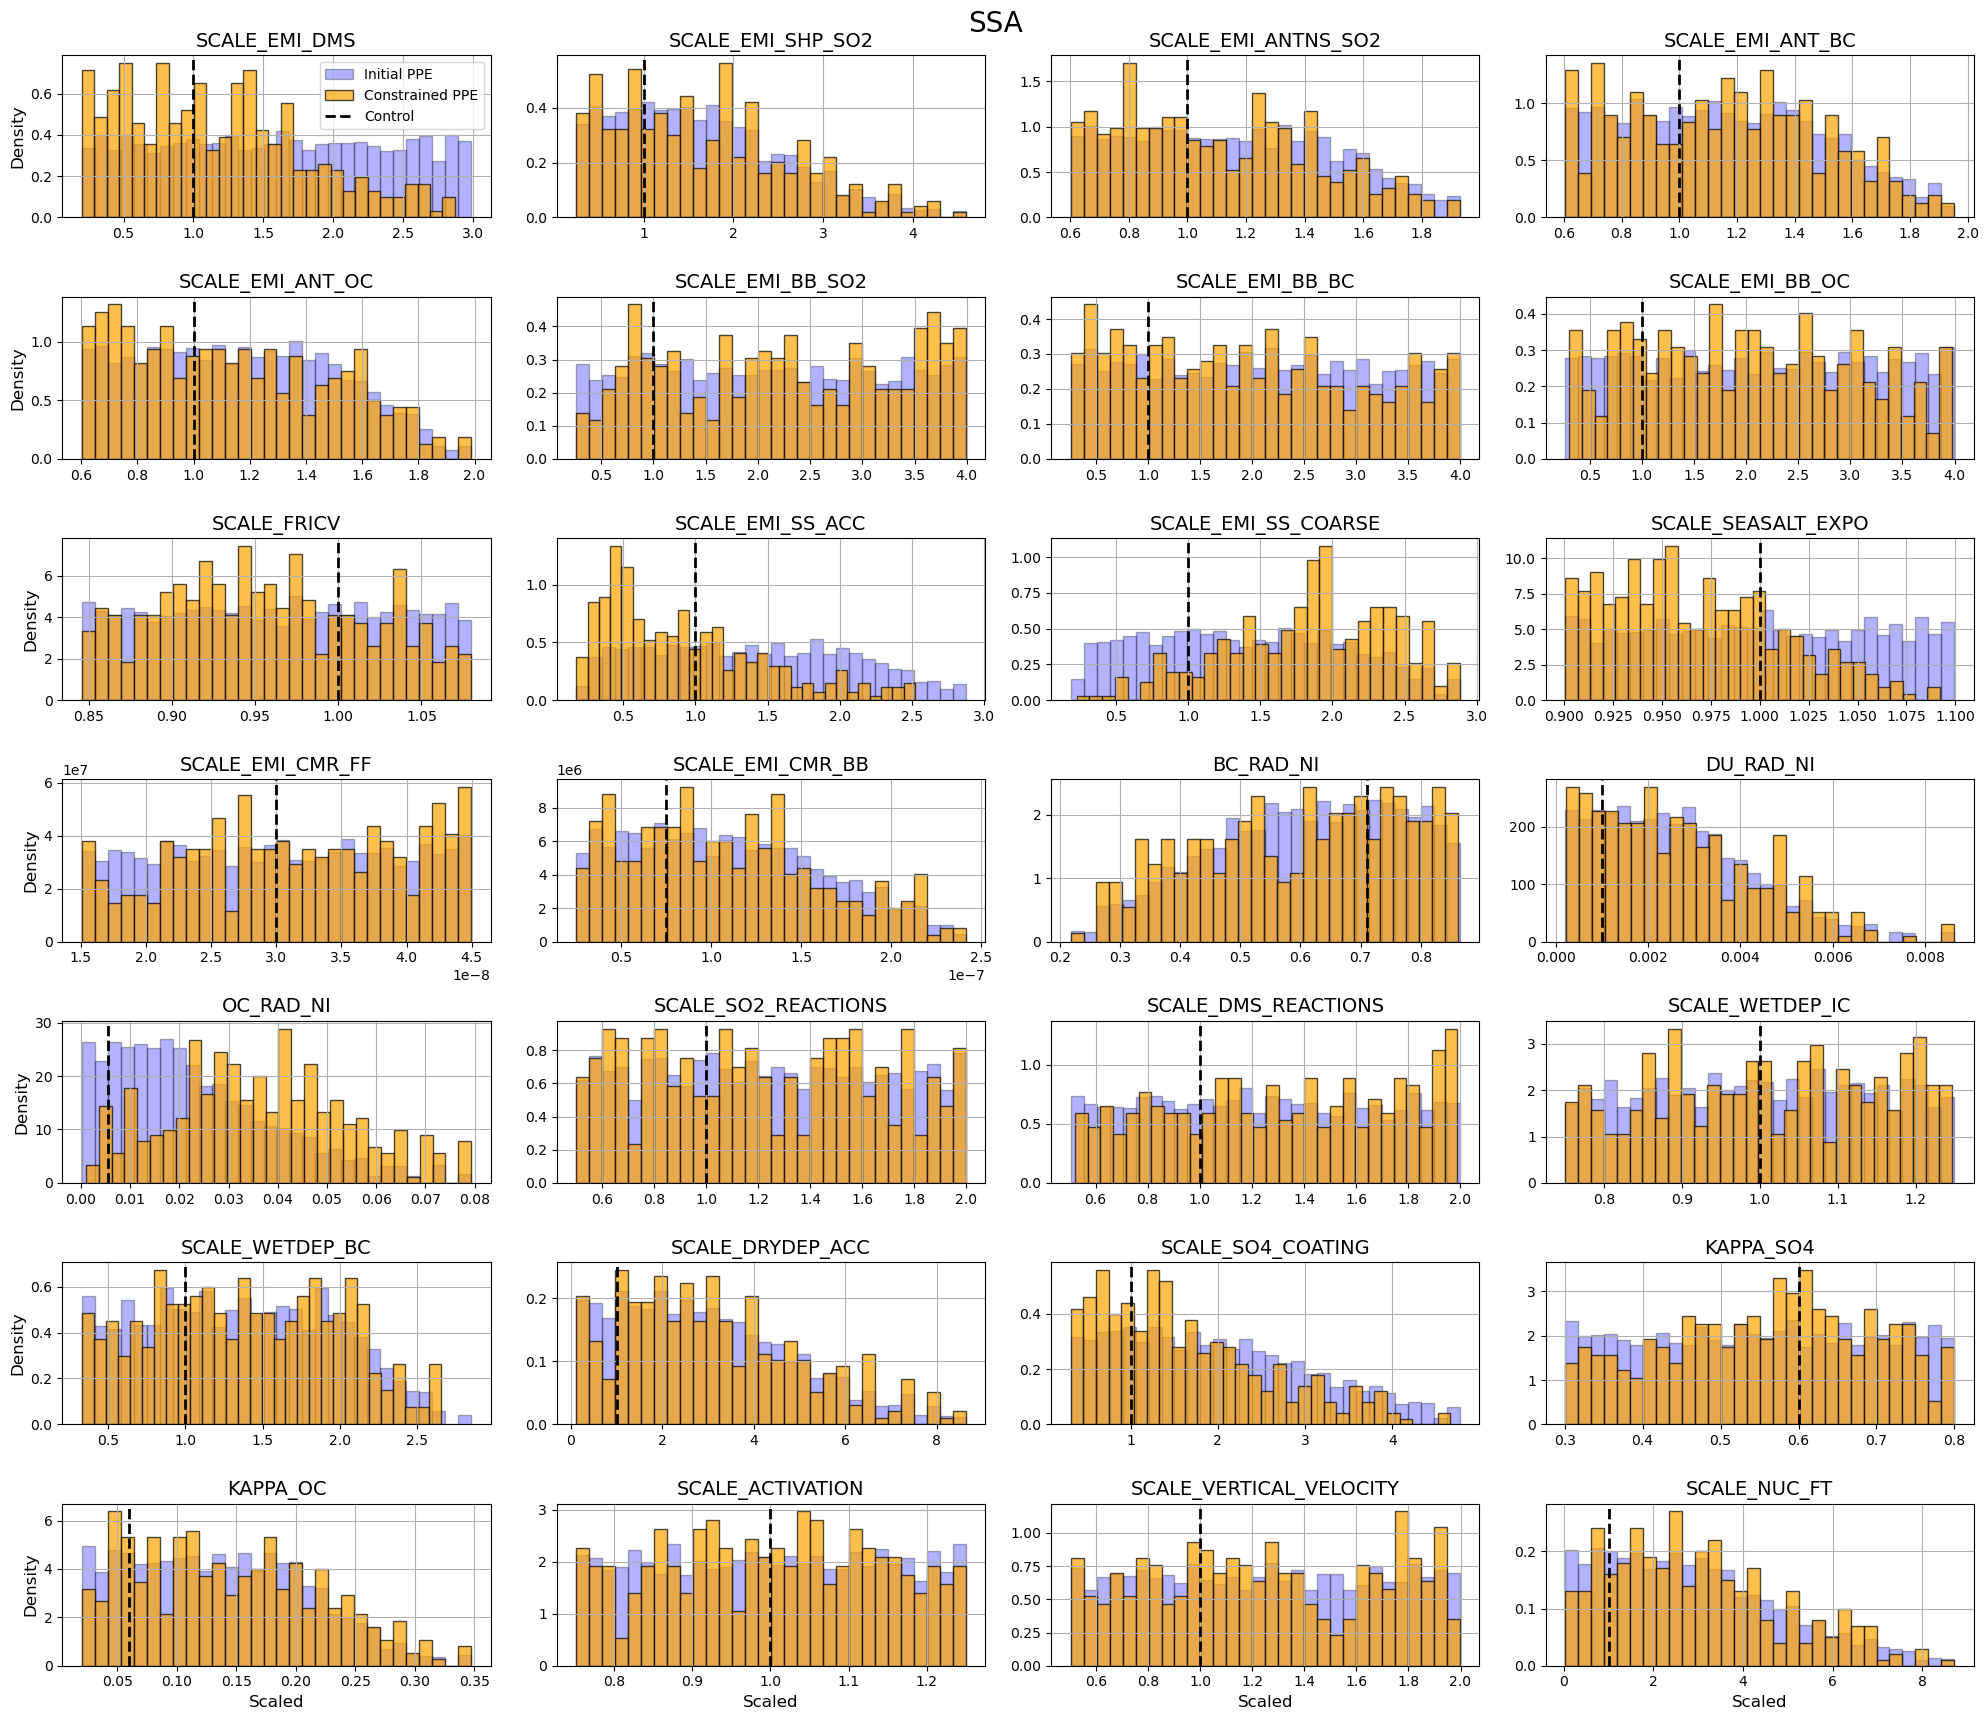

In [58]:
accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[accepted_members_best]
control_values = ppe_non_normalized_new_samples.iloc[0]
# best_member_values = ppe_non_normalized_new_samples.iloc[best_idx]
num_cols = len(shared_dataset_Southern_Ocean.columns)
cols_per_row = 4
rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

# First pass: compute max density across all plots
ymax = 0
for col in shared_dataset_Southern_Ocean.columns:
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
    ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                          color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_Southern_Ocean[col].hist(ax=ax, bins=30, edgecolor='black',
                             color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2, label="Control")
    # ax.axvline(best_values[col], color="red", linestyle="--", linewidth=2, label="Best Ensemble")
    # ax.axvline(shared[col].median(), color="green", linestyle="dashdot", linewidth=2, label="Median")

    # Inside the plotting loop, after the control line:
    # ax.axvline(best_member_values[col], color='green', linestyle='-', linewidth=2, label='Best-fit')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label
    if i % cols_per_row != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label
    if i < (rows - 1) * cols_per_row:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
   # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('SSA',fontsize=20)
plt.tight_layout()
plt.show()


In [269]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Prepare constrained members masks ---
accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

# --- Prepare observation masks ---
obs_vec_aod = AOD[:, -1].groupby('time.month').mean()
valid_mask_aod = ~np.isnan(obs_vec_aod)
emulated_aod_masked_rejected = emulated_aod.where(reject_map_aod).where(valid_mask_aod).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_aod = obs_vec_aod.where(reject_map_aod).mean('month')

obs_vec_ang = ANG[:, -1].groupby('time.month').mean()
valid_mask_ang = ~np.isnan(obs_vec_ang)
emulated_ang_masked_rejected = emulated_ang.where(reject_map_ang).where(valid_mask_ang).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_ang = obs_vec_ang.where(reject_map_ang).mean('month')

obs_vec_ssa = SSA_masked[:, -1].groupby('time.month').mean()
valid_mask_ssa = ~np.isnan(obs_vec_ssa)
emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa).mean('month')

obs_vec_aod_Original = AOD[:, -1].mean('time')
valid_mask_aod = ~np.isnan(obs_vec_aod_Original)
emulated_aod_masked_rejected_Original = emulated_aod.where(reject_map_ssa).where(valid_mask_aod).mean('month')

obs_vec_ang_Original = ANG[:, -1].mean('time')
valid_mask_ang = ~np.isnan(obs_vec_ang_Original)
emulated_ang_masked_rejected_Original = emulated_ang.where(reject_map_ssa).where(valid_mask_ang).mean('month')

obs_vec_ssa_Original = SSA_masked[:, -1].mean('time')
valid_mask_ssa = ~np.isnan(obs_vec_ssa_Original)
emulated_ssa_masked_rejected_Original = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa).mean('month')


# Define regions and their corresponding numerical indices
regions_cat = {
    "Arctic Ocean": 1, "Arctic Land": 2, "North Pacific Ocean": 3, "North America": 4,
    "North Atlantic Ocean": 5, "Europe": 6, "Asia": 7, "Tropical Pacific Ocean": 8,
    "Tropical Atlantic Ocean": 9, "Africa": 10, "Tropical Indian Ocean": 11,
    "South Pacific Ocean": 12, "South America": 13, "South Atlantic Ocean": 14,
    "South Indian Ocean": 15, "Australia": 16, "Antarctic Ocean": 17, "Antarctica": 18,
    "Global": 19
}

# Prepare data storage
boxplot_data_aod, boxplot_data_ang, boxplot_data_ssa = [], [], []
polder_means_aod, polder_means_ang, polder_means_ssa = [], [], []
boxplot_data_aod_control, boxplot_data_ang_control, boxplot_data_ssa_control = [], [], []

boxplot_data_aod_og, boxplot_data_ang_og, boxplot_data_ssa_og = [], [], []
polder_means_aod_og, polder_means_ang_og, polder_means_ssa_og = [], [], []
boxplot_data_aod_control_og, boxplot_data_ang_control_og, boxplot_data_ssa_control_og = [], [], []

# Loop through each region to compute statistics
for region_name, r in regions_cat.items():
    # AOD Processing
    region_gp_aod = Interpolate_Regional_uncertainty(emulated_aod_masked_rejected, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask = region_gp_aod.isnull().all(dim=("lat", "lon"))
    gpmeans_aod = areaweight(region_gp_aod, region_gp_aod.lat)
    gpmeans_aod[gpmeans_aod < 0] = 0
    gpmeans_aod = gpmeans_aod.where(~all_nan_mask)
    boxplot_data_aod.append(gpmeans_aod.values)
    boxplot_data_aod_control.append(gpmeans_aod[0].values)

    region_obs_aod = Interpolate_Regional_uncertainty(obs_masked_rejected_aod, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs = region_obs_aod.isnull().all(dim=("lat", "lon"))
    obs_aod = areaweight(region_obs_aod, region_obs_aod.lat).values
    polder_means_aod.append(obs_aod)

    # --- ORIGINAL (OG) AOD ---
    region_gp_aod_og = Interpolate_Regional_uncertainty(emulated_aod_masked_rejected_Original, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask_og = region_gp_aod_og.isnull().all(dim=("lat", "lon"))
    gpmeans_aod_og = areaweight(region_gp_aod_og, region_gp_aod_og.lat)
    gpmeans_aod_og[gpmeans_aod_og < 0] = 0
    gpmeans_aod_og = gpmeans_aod_og.where(~all_nan_mask_og)
    boxplot_data_aod_og.append(gpmeans_aod_og.values)
    boxplot_data_aod_control_og.append(gpmeans_aod_og[0].values)

    region_obs_aod_og = Interpolate_Regional_uncertainty(obs_vec_aod_Original, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs_og = region_obs_aod_og.isnull().all(dim=("lat", "lon"))
    obs_aod_og = areaweight(region_obs_aod_og, region_obs_aod_og.lat).values
    polder_means_aod_og.append(obs_aod_og)
    
    # ANG Processing
    region_gp_ang = Interpolate_Regional_uncertainty(emulated_ang_masked_rejected, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask = region_gp_ang.isnull().all(dim=("lat", "lon"))
    gpmeans_ang = areaweight(region_gp_ang, region_gp_ang.lat)
    gpmeans_ang = gpmeans_ang.where(~all_nan_mask)
    boxplot_data_ang.append(gpmeans_ang.values)
    boxplot_data_ang_control.append(gpmeans_ang[0].values)

    region_obs_ang = Interpolate_Regional_uncertainty(obs_masked_rejected_ang, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs = region_obs_ang.isnull().all(dim=("lat", "lon"))
    obs_ang = areaweight(region_obs_ang, region_obs_ang.lat).values
    polder_means_ang.append(obs_ang)

    # --- ORIGINAL (OG) ANG ---
    region_gp_ang_og = Interpolate_Regional_uncertainty(emulated_ang_masked_rejected_Original, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask_og = region_gp_ang_og.isnull().all(dim=("lat", "lon"))
    gpmeans_ang_og = areaweight(region_gp_ang_og, region_gp_ang_og.lat)
    gpmeans_ang_og = gpmeans_ang_og.where(~all_nan_mask_og)
    boxplot_data_ang_og.append(gpmeans_ang_og.values)
    boxplot_data_ang_control_og.append(gpmeans_ang_og[0].values)

    region_obs_ang_og = Interpolate_Regional_uncertainty(obs_vec_ang_Original, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs_og = region_obs_ang_og.isnull().all(dim=("lat", "lon"))
    obs_ang_og = areaweight(region_obs_ang_og, region_obs_ang_og.lat).values
    polder_means_ang_og.append(obs_ang_og)


    # SSA Processing
    region_gp_ssa = Interpolate_Regional_uncertainty(emulated_ssa_masked_rejected, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask = region_gp_ssa.isnull().all(dim=("lat", "lon"))
    gpmeans_ssa = areaweight(region_gp_ssa, region_gp_ssa.lat)
    gpmeans_ssa[gpmeans_ssa < 0] = 0
    gpmeans_ssa = gpmeans_ssa.where(~all_nan_mask)
    boxplot_data_ssa.append(gpmeans_ssa.values)
    boxplot_data_ssa_control.append(gpmeans_ssa[0].values)

    region_obs_ssa = Interpolate_Regional_uncertainty(obs_masked_rejected_ssa, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs = region_obs_ssa.isnull().all(dim=("lat", "lon"))
    obs_ssa = areaweight(region_obs_ssa, region_obs_ssa.lat).values
    polder_means_ssa.append(obs_ssa)

    # --- ORIGINAL (OG) SSA ---
    region_gp_ssa_og = Interpolate_Regional_uncertainty(emulated_ssa_masked_rejected_Original, r, regions_nn).transpose("sample", "lat", "lon")
    all_nan_mask_og = region_gp_ssa_og.isnull().all(dim=("lat", "lon"))
    gpmeans_ssa_og = areaweight(region_gp_ssa_og, region_gp_ssa_og.lat)
    gpmeans_ssa_og[gpmeans_ssa_og < 0] = 0
    gpmeans_ssa_og = gpmeans_ssa_og.where(~all_nan_mask_og)
    boxplot_data_ssa_og.append(gpmeans_ssa_og.values)
    boxplot_data_ssa_control_og.append(gpmeans_ssa_og[0].values)

    region_obs_ssa_og = Interpolate_Regional_uncertainty(obs_vec_ssa_Original, r, regions_nn).transpose("lat", "lon")
    all_nan_mask_obs_og = region_obs_ssa_og.isnull().all(dim=("lat", "lon"))
    obs_ssa_og = areaweight(region_obs_ssa_og, region_obs_ssa_og.lat).values
    polder_means_ssa_og.append(obs_ssa_og)

    print(r)
    if r == 18:
        break

# Ensure global statistics are included
boxplot_data_aod.append(areaweight(emulated_aod_masked_rejected, emulated_aod_masked_rejected.lat).values)
polder_means_aod.append(areaweight(obs_masked_rejected_aod, obs_masked_rejected_aod.lat).values)
boxplot_data_aod_control.append(areaweight(emulated_aod_masked_rejected[0], emulated_aod_masked_rejected.lat).values)

boxplot_data_ang.append(areaweight(emulated_ang_masked_rejected, emulated_ang_masked_rejected.lat).values)
polder_means_ang.append(areaweight(obs_masked_rejected_ang, obs_masked_rejected_ang.lat).values)
boxplot_data_ang_control.append(areaweight(emulated_ang_masked_rejected[0], emulated_ang_masked_rejected.lat).values)

boxplot_data_ssa.append(areaweight(emulated_ssa_masked_rejected, emulated_ssa_masked_rejected.lat).values)
polder_means_ssa.append(areaweight(obs_masked_rejected_ssa, obs_masked_rejected_ssa.lat).values)
boxplot_data_ssa_control.append(areaweight(emulated_ssa_masked_rejected[0], emulated_ssa_masked_rejected.lat).values)

boxplot_data_aod_og.append(areaweight(emulated_aod_masked_rejected_Original, emulated_aod_masked_rejected_Original.lat).values)
polder_means_aod_og.append(areaweight(obs_vec_aod_Original, obs_vec_aod_Original.lat).values)
boxplot_data_aod_control_og.append(areaweight(emulated_aod_masked_rejected_Original[0], emulated_aod_masked_rejected_Original.lat).values)

boxplot_data_ang_og.append(areaweight(emulated_ang_masked_rejected_Original, emulated_ang_masked_rejected_Original.lat).values)
polder_means_ang_og.append(areaweight(obs_vec_ang_Original, obs_vec_ang_Original.lat).values)
boxplot_data_ang_control_og.append(areaweight(emulated_ang_masked_rejected_Original[0], emulated_ang_masked_rejected_Original.lat).values)

boxplot_data_ssa_og.append(areaweight(emulated_ssa_masked_rejected_Original, emulated_ssa_masked_rejected_Original.lat).values)
polder_means_ssa_og.append(areaweight(obs_vec_ssa_Original, obs_vec_ssa_Original.lat).values)
boxplot_data_ssa_control_og.append(areaweight(emulated_ssa_masked_rejected_Original[0], emulated_ssa_masked_rejected_Original.lat).values)

ppe_aod_mean = np.nanmean(boxplot_data_aod,axis=1); ppe_aod_std = np.nanstd(boxplot_data_aod,axis=1)
ppe_ang_mean = np.nanmean(boxplot_data_ang,axis=1); ppe_ang_std = np.nanstd(boxplot_data_ang,axis=1)
ppe_ssa_mean = np.nanmean(boxplot_data_ssa,axis=1); ppe_ang_std = np.nanstd(boxplot_data_ssa,axis=1)

# Map means to regions
region_names = list(regions_cat.keys())

print(f"Memory usage: {get_memory_usage()} GB")

# land_std = np.array(land_std)
# land_means = np.array(land_means)
# ocean_std = np.array(ocean_std)
# ocean_means = np.array(ocean_means)
# print(f"Land is {((land_means.mean()/ocean_means.mean())-1)*100} % over oceans")
# print(f"Land relative uncertainty is {((land_std.mean()/ocean_std.mean())-1)*100} % over ocean")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


/scratch-local/ybhatti2.15638073/ipykernel_1243409/433584285.py:172: RuntimeWarning: Mean of empty slice
  ppe_ssa_mean = np.nanmean(boxplot_data_ssa,axis=1); ppe_ang_std = np.nanstd(boxplot_data_ssa,axis=1)
/home/ybhatti2/miniconda3/envs/myenv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/scratch-local/ybhatti2.15638073/ipykernel_1243409/3300364178.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(data_og, vert=False, labels=list(regions_cat.keys()), patch_artist=True,
/scratch-local/ybhatti2.15638073/ipykernel_1243409/3300364178.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_right.boxplot(data_c, vert=False, labels=list(regions_cat.keys()), patch_artist=True,
/scratch-local/ybhatti2.15638073/ipykernel_1243409/3300364178.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_left.boxplot(data_og, vert=False, labels=list(regions_cat.keys()), patch_artist=True,
/scratch-loca

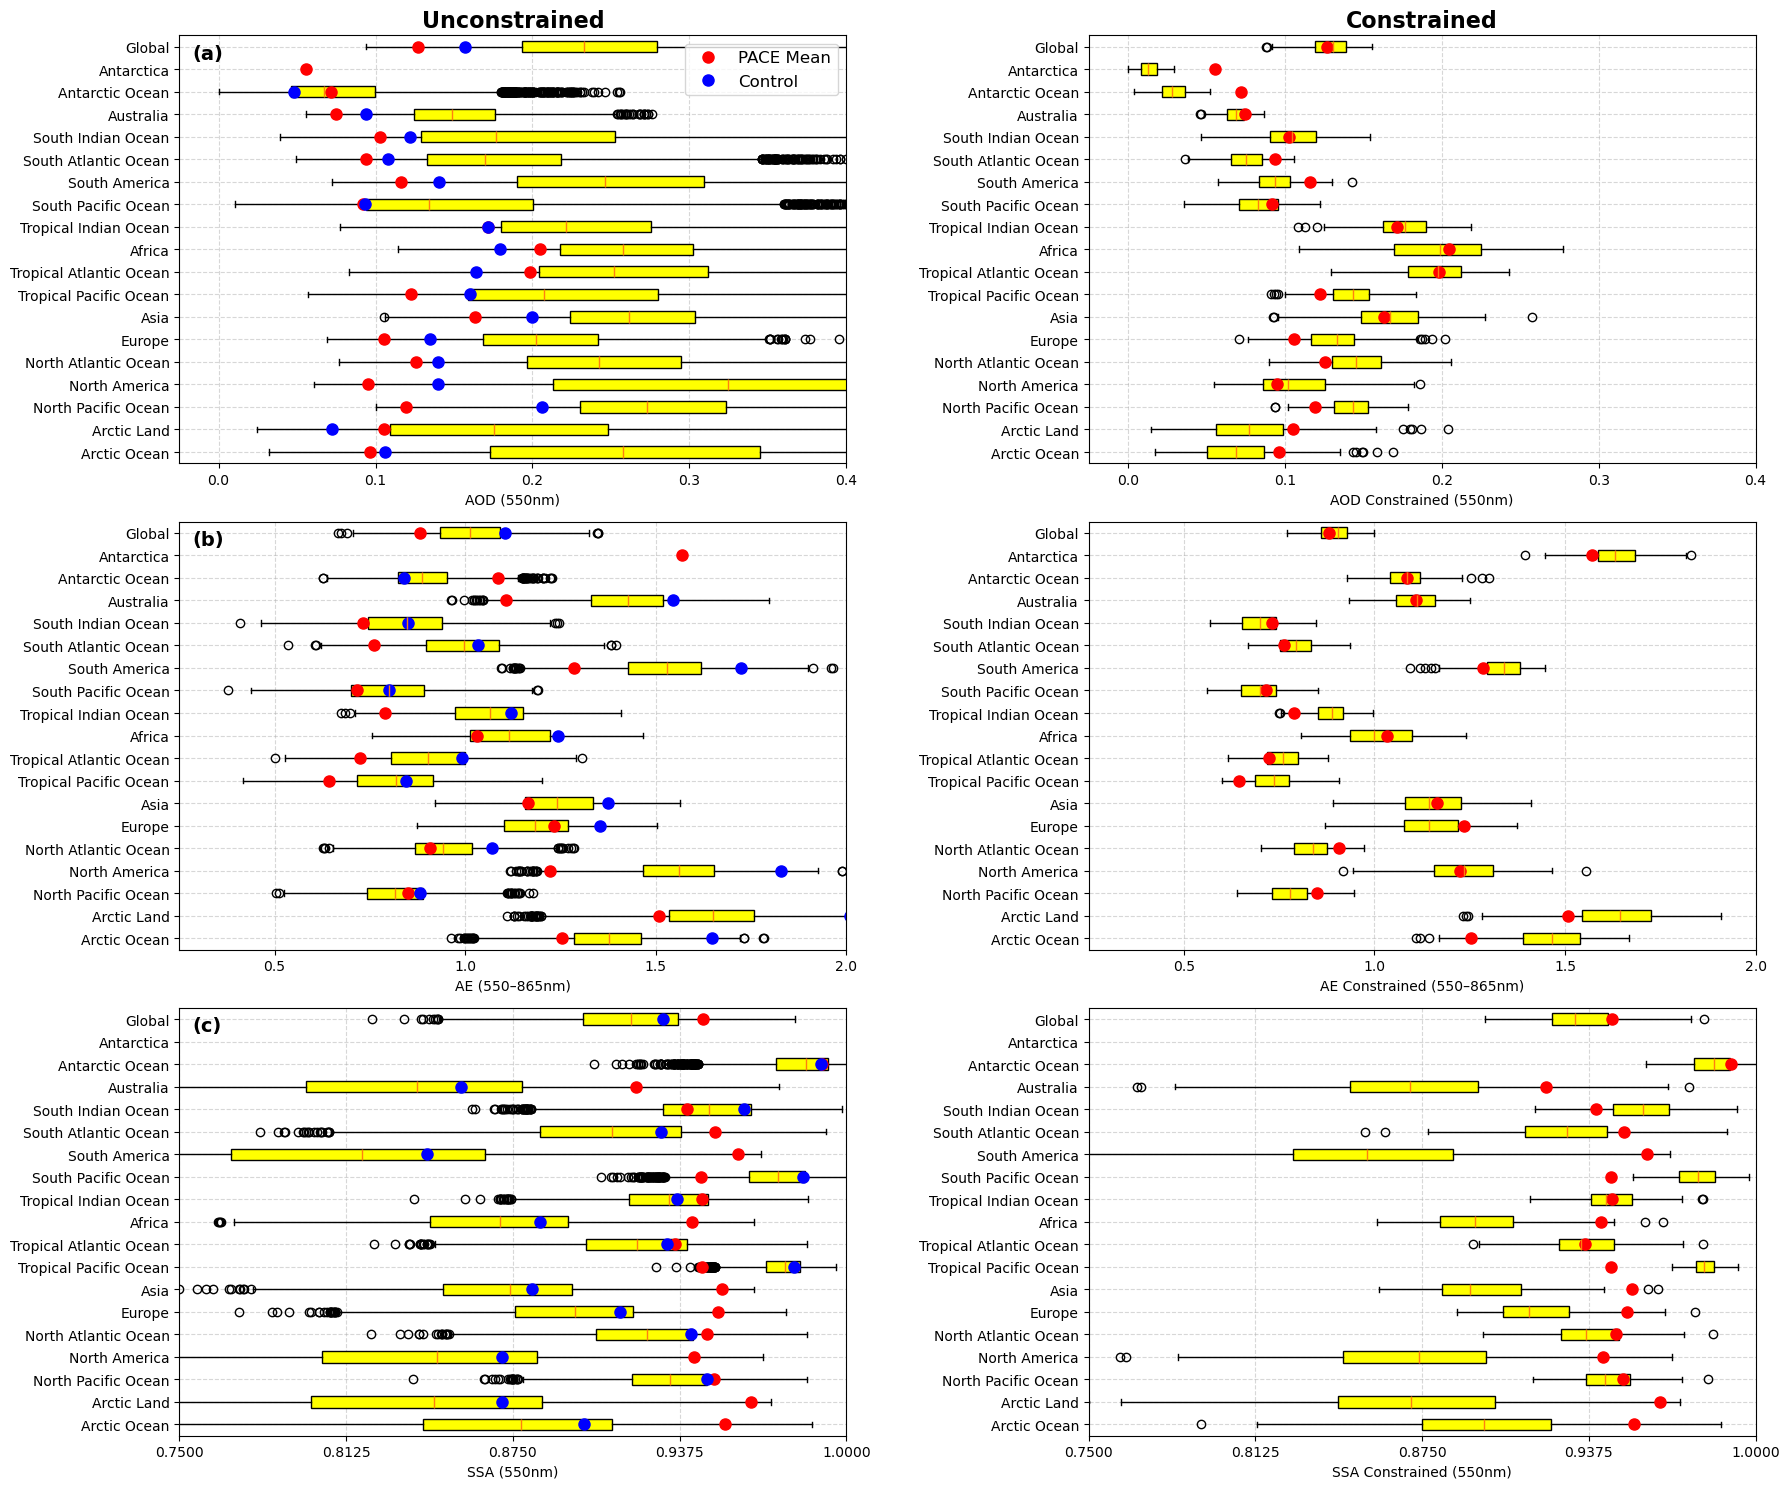

In [266]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)

# --- Define both sets ---
metrics_unconstrained = [
    (boxplot_data_aod_og, polder_means_aod, boxplot_data_aod_control_og, "AOD (550nm)", (-0.025, 0.4), np.linspace(0, 0.4, 5)),
    (boxplot_data_ang_og, polder_means_ang, boxplot_data_ang_control_og, "AE (550–865nm)", (0.25, 2), np.linspace(0.5, 2, 4)),
    (boxplot_data_ssa_og, polder_means_ssa, boxplot_data_ssa_control_og, "SSA (550nm)", (0.75, 1), np.linspace(0.75, 1, 5)),
]
    # (boxplot_data_ssa_og, polder_means_ssa_og,boxplot_data_ssa_control_og, "AAOD", (-0.001, 0.04), np.linspace(0, 0.04, 5)),

metrics_constrained = [
    (boxplot_data_aod, polder_means_aod, boxplot_data_aod_control, "AOD Constrained (550nm)", (-0.025, 0.4), np.linspace(0, 0.4, 5)),
    (boxplot_data_ang, polder_means_ang, boxplot_data_ang_control, "AE Constrained (550–865nm)", (0.25, 2), np.linspace(0.5, 2, 4)),
    (boxplot_data_ssa, polder_means_ssa, boxplot_data_ssa_control, "SSA Constrained (550nm)", (0.75, 1), np.linspace(0.75, 1, 5)),
]
#     (boxplot_data_ang, polder_means_ang,boxplot_data_ang_control, "AE Constrained (550nm to 865nm)", (0.25, 2), np.linspace(0.5, 2, 4)),

subplot_labels = ["(a)", "(b)", "(c)"]

# --- Plot both sets ---
for row, ((data_og, means_og, ctrl_og, xlabel_og, xlim_og, xticks_og),
           (data_c, means_c, ctrl_c, xlabel_c, xlim_c, xticks_c),
           label) in enumerate(zip(metrics_unconstrained, metrics_constrained, subplot_labels)):

    # --- Left column: Unconstrained ---
    ax_left = axes[row, 0]
    ax_left.boxplot(data_og, vert=False, labels=list(regions_cat.keys()), patch_artist=True,
                    boxprops=dict(facecolor='yellow'))
    for i, mean in enumerate(means_og):
        ax_left.plot(mean, i + 1, 'ro', markersize=8, label="PACE Mean" if i == 0 else "")
    for i, mean in enumerate(ctrl_og):
        ax_left.plot(mean, i + 1, 'o', color='blue', markersize=8, label="Control" if i == 0 else "")
    ax_left.set_xlim(xlim_og)
    ax_left.set_xticks(xticks_og)
    ax_left.set_xlabel(xlabel_og)
    ax_left.grid(True, linestyle="--", alpha=0.5)
    ax_left.text(0.02, 0.98, label, transform=ax_left.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
    if row == 0:
        ax_left.set_title("Unconstrained", fontsize=16, fontweight='bold')
        ax_left.legend(loc='upper right', fontsize=12)

    # --- Right column: Constrained ---
    ax_right = axes[row, 1]
    ax_right.boxplot(data_c, vert=False, labels=list(regions_cat.keys()), patch_artist=True,
                     boxprops=dict(facecolor='yellow'))
    for i, mean in enumerate(means_c):
        ax_right.plot(mean, i + 1, 'ro', markersize=8, label="PACE Mean" if i == 0 else "")
    # for i, mean in enumerate(ctrl_c):
    #     ax_right.plot(mean, i + 1, 'o', color='blue', markersize=8, label="Control" if i == 0 else "")
    ax_right.set_xlim(xlim_c)
    ax_right.set_xticks(xticks_c)
    ax_right.set_xlabel(xlabel_c)
    ax_right.grid(True, linestyle="--", alpha=0.5)
    if row == 0:
        ax_right.set_title("Constrained", fontsize=16, fontweight='bold')

plt.tight_layout(w_pad=3.5)
# plt.show()
# plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/PPE_Observation_BOX_Unconstrained_vs_Constrained.png", dpi=100, bbox_inches='tight')
plt.show()


In [ ]:

accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

# --- Prepare observation masks ---
obs_vec_aod = AOD[:, -1].groupby('time.month').mean()
valid_mask_aod = ~np.isnan(obs_vec_aod)
emulated_aod_masked_rejected = emulated_aod.where(reject_map_aod).where(valid_mask_aod).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_aod = obs_vec_aod.where(reject_map_aod)

obs_vec_ang = ANG[:, -1].groupby('time.month').mean()
valid_mask_ang = ~np.isnan(obs_vec_ang)
emulated_ang_masked_rejected = emulated_ang.where(reject_map_ang).where(valid_mask_ang).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_ang = obs_vec_ang.where(reject_map_ang)

obs_vec_ssa = SSA_masked[:, -1].groupby('time.month').mean()
valid_mask_ssa = ~np.isnan(obs_vec_ssa)
emulated_ssa_masked_rejected = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa).mean('month').sel(sample=accepted_members_best)
obs_masked_rejected_ssa = obs_vec_ssa.where(reject_map_ssa)

obs_vec_aod_Original = AOD[:, -1].mean('time')
valid_mask_aod = ~np.isnan(obs_vec_aod_Original)
emulated_aod_masked_rejected_Original = emulated_aod.where(reject_map_ssa).where(valid_mask_aod).mean('month')

obs_vec_ang_Original = ANG[:, -1].mean('time')
valid_mask_ang = ~np.isnan(obs_vec_ang_Original)
emulated_ang_masked_rejected_Original = emulated_ang.where(reject_map_ssa).where(valid_mask_ang).mean('month')

obs_vec_ssa_Original = SSA_masked[:, -1].mean('time')
valid_mask_ssa = ~np.isnan(obs_vec_ssa_Original)
emulated_ssa_masked_rejected_Original = emulated_ssa.where(reject_map_ssa).where(valid_mask_ssa).mean('month')


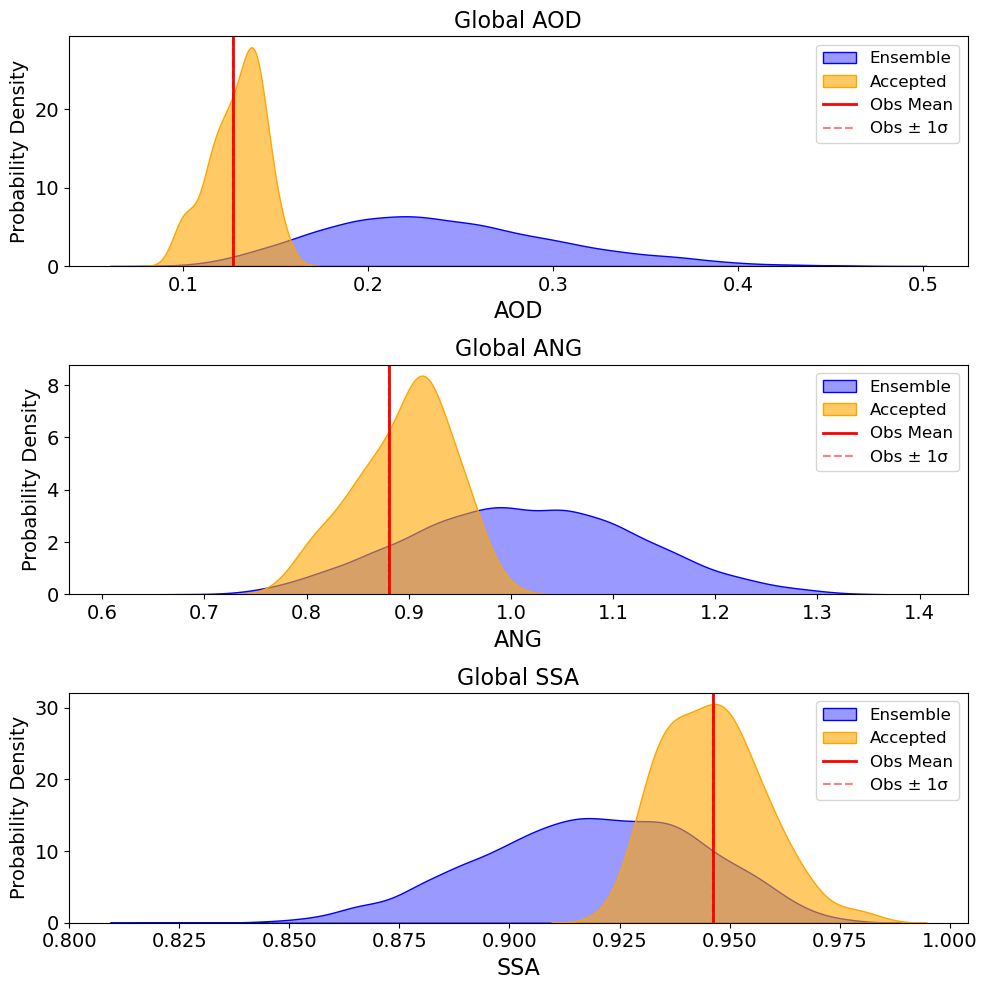

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 10))  # 2 rows: AOD and ANG



# Prepare accepted datasets
# Accepted_AOD = areaweight(emulated_aod.sel(sample=accepted_members_best),lats).mean('month')
# Accepted_ANG = areaweight(emulated_ang.sel(sample=accepted_members_best),lats).mean('month')
Accepted_AOD = areaweight(emulated_aod_masked_rejected,lats)
Accepted_ANG = areaweight(emulated_ang_masked_rejected,lats)
Accepted_SSA = areaweight(emulated_ssa_masked_rejected,lats)

areaweighted_emulated_aod = areaweight(emulated_aod_masked_rejected_Original, lats)
areaweighted_emulated_ang = areaweight(emulated_ang_masked_rejected_Original, lats)
areaweighted_emulated_ssa = areaweight(emulated_ssa_masked_rejected_Original, lats)

# ang_pace_time = areaweight(ANG[:, -1],lats)
# aod_pace_time = areaweight(AOD[:, -1],lats)
ang_pace_time = areaweight(obs_masked_rejected_ang,lats)
aod_pace_time = areaweight(obs_masked_rejected_aod,lats)
ssa_pace_time = areaweight(obs_masked_rejected_ssa,lats)


# BEST_AOD = areaweight(emulated_aod.sel(sample=accepted_members_best),lats).mean('month')
# BEST_ANG = areaweight(emulated_ang.sel(sample=accepted_members_best),lats).mean('month')
n=1
# Loop through variables (AOD, ANG)
for ax, (full_data, accepted_data, label, obs) in zip(
    axes,
    [
        (areaweighted_emulated_aod, Accepted_AOD, "AOD", aod_pace_time),
        (areaweighted_emulated_ang, Accepted_ANG, "ANG", ang_pace_time),
        (areaweighted_emulated_ssa, Accepted_SSA, "SSA", ssa_pace_time),
    ]
):
    # Flatten ensemble and accepted values
    full_values = full_data.values.flatten()
    accepted_values = accepted_data.values.flatten()

    # Obs mean/std across time
    obs_mean = obs.mean().item()
    obs_std = obs.std().item()

    # Plot ensemble PDF (blue)
    sns.kdeplot(full_values, fill=True, ax=ax, label="Ensemble", color="blue", alpha=0.4)

    # Plot accepted subset PDF (orange, semi-transparent)
    sns.kdeplot(accepted_values, fill=True, ax=ax, label="Accepted", color="orange", alpha=0.6)

    # Obs mean and ±0.5σ
    ax.axvline(obs_mean, color="red", linestyle="-", linewidth=2, label="Obs Mean")
    ax.axvline(obs_mean - 1 * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5, label=f"Obs ± {n}σ")
    ax.axvline(obs_mean + 1 * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5)
    # ax.axvline(best, color="green", linestyle="dashdot", linewidth=2, label="Least Sq Best")

    # Labels & styling
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.set_title(f"Global {label}", fontsize=16)
    ax.legend(fontsize=12)

plt.tight_layout()
# plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/Aerocom/PDF_PPE_to_Observations.png", dpi=100, bbox_inches="tight")
plt.show()


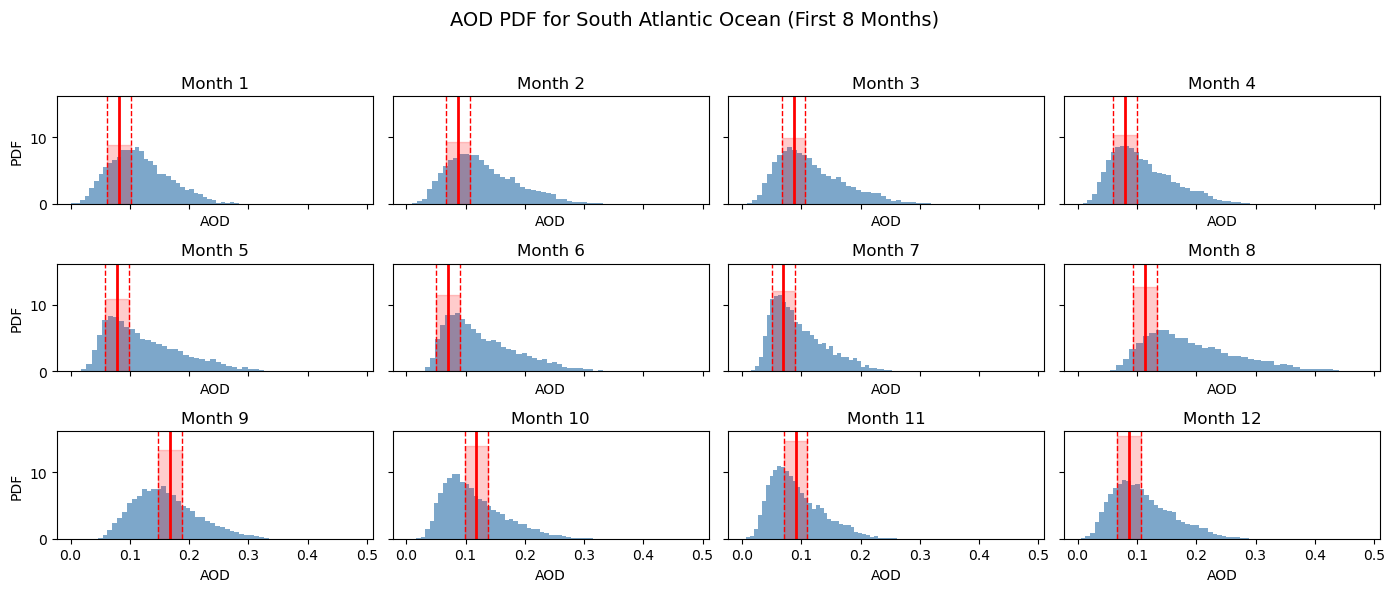

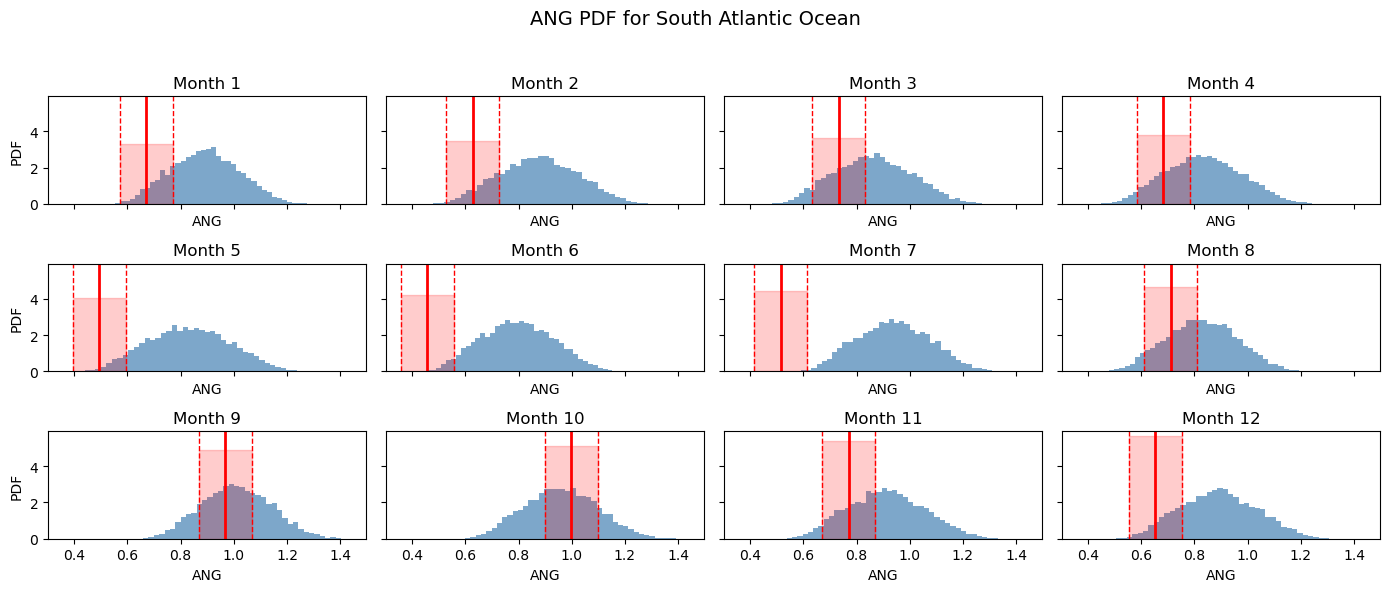

In [90]:
#MAX[0.02,10%] for AOD, 0.10 for AE, 0.02 for SSA.

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# --- Select region and extract data ---
region = "South Atlantic Ocean"
aod_region = regional_dataset.AOD.sel(region=region)
samples = aod_region.sel(sample=slice(0, 8000))  # all except obs
obs = aod_region.sel(sample=-1)                # observation
#obs = Region_OBS_aod[13]                # observation

# --- Create figure ---
fig, axes = plt.subplots(3, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, month in enumerate(range(1, 13)):  # plot first 8 months
    ax = axes[i]
    data = samples.sel(month=month).values
    data = data[~np.isnan(data)]
    obs_val = obs.sel(month=month).values.item()

   # obs_val = obs[i-1]
    # --- Compute error (max of 0.02 or 10%) ---
    err = max(0.02, 0.1 * obs_val)

    # --- Plot histogram (PDF) ---
    ax.hist(data, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='none')

    # --- Plot observation line ---
    ax.axvline(obs_val, color='red', lw=2, label='Observation')

    # --- Plot ±error bounds ---
    ax.axvline(obs_val - err, color='red', linestyle='--', lw=1)
    ax.axvline(obs_val + err, color='red', linestyle='--', lw=1)
    ax.fill_betweenx([0, ax.get_ylim()[1]], obs_val - err, obs_val + err, color='red', alpha=0.2)

    ax.set_title(f"Month {month}")
    ax.set_xlabel("AOD")
    if i % 4 == 0:
        ax.set_ylabel("PDF")

fig.suptitle(f"AOD PDF for {region} (First 8 Months)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

ang_region = regional_dataset.ANG.sel(region=region)
samples = ang_region.sel(sample=slice(0, 8000))  # all ensemble samples
obs = ang_region.sel(sample=-1)                  # observation

# --- Create figure ---
fig, axes = plt.subplots(3, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, month in enumerate(range(1, 13)):
    ax = axes[i]
    data = samples.sel(month=month).values
    data = data[~np.isnan(data)]
    obs_val = obs.sel(month=month).values.item()

    # --- Compute error (fixed ±0.10 for ANG) ---
    err = 0.10

    # --- Plot histogram (PDF) ---
    ax.hist(data, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='none')

    # --- Plot observation and uncertainty region ---
    ax.axvline(obs_val, color='red', lw=2, label='Observation')
    ax.axvline(obs_val - err, color='red', linestyle='--', lw=1)
    ax.axvline(obs_val + err, color='red', linestyle='--', lw=1)
    ax.fill_betweenx([0, ax.get_ylim()[1]], obs_val - err, obs_val + err, color='red', alpha=0.2)

    ax.set_title(f"Month {month}")
    ax.set_xlabel("ANG")
    if i % 4 == 0:
        ax.set_ylabel("PDF")

fig.suptitle(f"ANG PDF for {region}", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Lets identify the ensemble members that are accepted across 12 months * 18 regions * 2 diagnostics 

In [114]:
accepted_masks = {}

for var_name in ["AOD", "ANG"]:
    var_data = regional_dataset[var_name]
    accepted_list = []

    for region in var_data.region.values:
        region_data = var_data.sel(region=region)
        samples = region_data.sel(sample=slice(0, 8000))
        obs = region_data.sel(sample=-1)

        # Define error rule per variable
        if var_name == "AOD":
            err = xr.apply_ufunc(lambda x: np.maximum(0.02, 0.1 * x), obs)
        elif var_name == "ANG":
            err = xr.full_like(obs, 0.10)

        # --- Condition for acceptance ---
        accepted = (samples >= (obs - err)) & (samples <= (obs + err))
        accepted_list.append(accepted)

    # Combine all regions into one DataArray
    accepted_masks[var_name] = xr.concat(accepted_list, dim="region")
    accepted_masks[var_name]["region"] = var_data.region
    accepted_masks[var_name].name = f"{var_name}_accepted"

# --- Combine into single dataset ---
accepted_ds = xr.Dataset(accepted_masks)
accepted_ds.attrs["description"] = "Boolean masks of accepted ensemble members within observational uncertainty"

# --- Optionally save ---
# accepted_ds.to_netcdf("Accepted_Ensemble_Members.nc")

# --- Count True/False values across all regions, months, and samples ---
aod_true = accepted_ds.AOD.sum().item()
aod_false = accepted_ds.AOD.size - aod_true

ang_true = accepted_ds.ANG.sum().item()
ang_false = accepted_ds.ANG.size - ang_true

# --- Convert to percentages ---
aod_pct = 100 * aod_true / accepted_ds.AOD.size
ang_pct = 100 * ang_true / accepted_ds.ANG.size

print(f"AOD: {aod_true:.0f} accepted ({aod_pct:.2f}%), {aod_false:.0f} rejected")
print(f"ANG: {ang_true:.0f} accepted ({ang_pct:.2f}%), {ang_false:.0f} rejected")


AOD: 568159 accepted (32.88%), 1160057 rejected
ANG: 490951 accepted (28.41%), 1237265 rejected


In [7]:
# I_field_aod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_aod.nc').__xarray_dataarray_variable__
# I_field_ang = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/I_field_ang.nc').__xarray_dataarray_variable__

# implaus_mask_aod = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_masked_aod.nc').__xarray_dataarray_variable__
# implaus_mask_ang = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_masked_ang.nc').__xarray_dataarray_variable__



0
1
2
3
4
5
6
7
8
9
10
11
0
1
2
3
4
5
6
7
8
9
10
11


In [ ]:
# # Compute 2.5th percentile along the 'sample' dimension
# q2p5 = I_field_aod.quantile(0.025, dim='sample')
# # Create a mask where the 2.5th percentile > 1
# mask = q2p5 > 1
# # Apply the mask across all samples efficiently
# da_I_field_aod = I_field_aod.where(mask)
# da_I_field_aod.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_masked_aod.nc')

# # Compute 2.5th percentile along the 'sample' dimension
# q2p5 = I_field_ang.quantile(0.025, dim='sample')
# # Create a mask where the 2.5th percentile > 1
# mask = q2p5 > 1
# # Apply the mask across all samples efficiently
# da_I_field_ang = I_field_ang.where(mask)
# da_I_field_ang.to_netcdf('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/implausibility_values_masked_ang.nc')


In [ ]:

# --- Setup figure for 12 months (2 columns: AOD left, ANG right) ---
fig, axes = plt.subplots(
    nrows=12, ncols=2, figsize=(10, 40),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for i, month in enumerate(range(1, 13)):
    for j, (reject_map, title) in enumerate(zip(
        [reject_map_aod, reject_map_ang],
        ["AOD", "ANG"]
    )):
        ax = axes[i, j]
        ax.coastlines(resolution="110m", linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.set_global()
        ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

        if i == 0:
            ax.set_title(title, fontsize=13, fontweight="bold")
        ax.text(-170, 80, f"Month {month}", fontsize=9, ha="left")

        # Select monthly map
        rm = reject_map.sel(month=month)
        vm = valid_mask.sel(month=month)

        # Plot retained (True=blue) vs rejected (False=red)
        img = ax.pcolormesh(
            rm.lon, rm.lat, rm.astype(int),
            cmap="bwr_r", vmin=0, vmax=1,
            transform=ccrs.PlateCarree()
        )

        # --- Mask invalid (False/NaN) pixels only and plot white ---
        invalid_mask = ~vm
        invalid_mask = invalid_mask.where(invalid_mask, np.nan)  # keep only False cells
        ax.pcolormesh(
            rm.lon, rm.lat, invalid_mask,
            cmap="Greys", vmin=0, vmax=1,
            transform=ccrs.PlateCarree(),
            alpha=1.0
        )

# --- Shared colorbar ---
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.015])
cbar = plt.colorbar(img, cax=cbar_ax, orientation='horizontal', ticks=[0, 1])
cbar.ax.set_xticklabels(["Rejected (False)", "Retained (True)"])
cbar.ax.tick_params(labelsize=11)

plt.suptitle("Implausibility Rejection Maps (All Months)", fontsize=15, y=0.92)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()


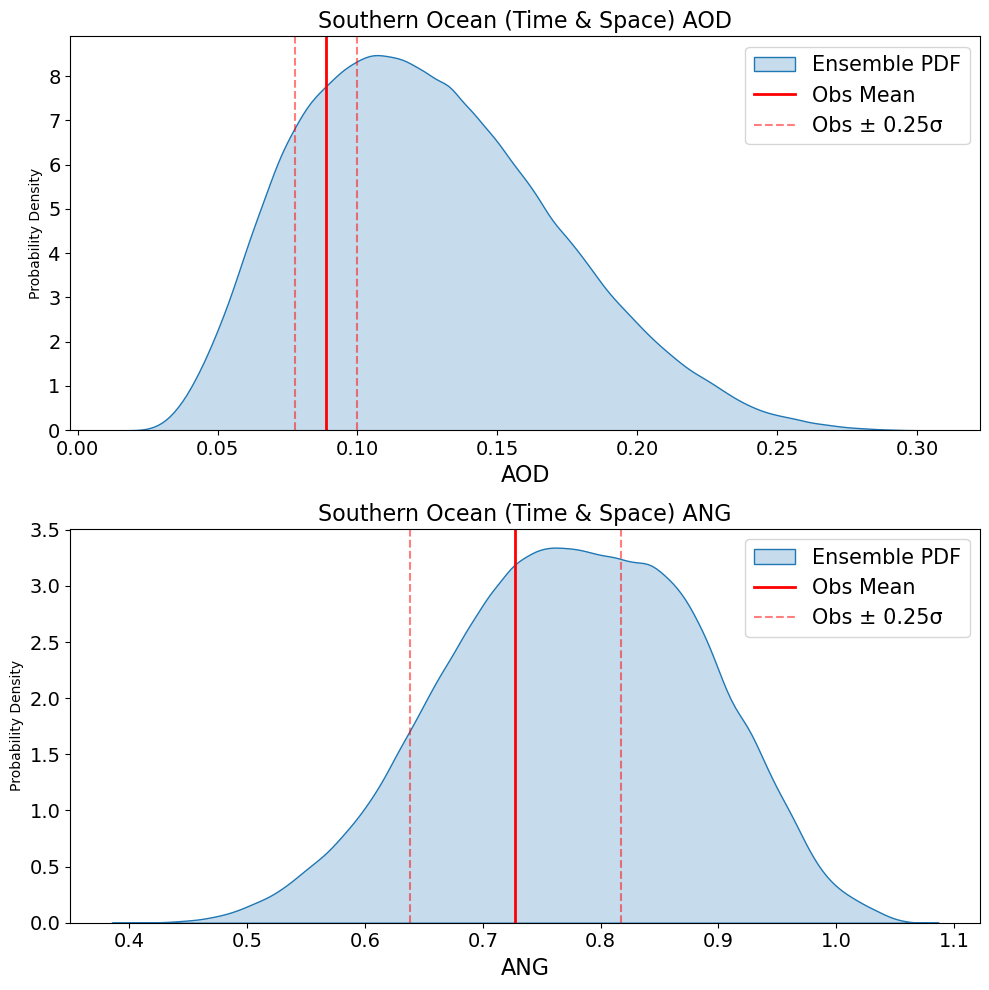

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# How many ensemble members to plot
n_show = 3000
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # AOD on top, ANG on bottom

for ax, data, label, obs in zip(
    axes,
    [emulated_aod, emulated_ang],   # full PPE (20000 members)
    ["AOD", "ANG"],
    [aod_pace_monthly, ang_pace_monthly] # observations (time, lat, lon)
):
    # Flatten observations (time × lat × lon)
    obs_flat = obs.values.reshape(-1)
    obs_flat = obs_flat[~np.isnan(obs_flat)]

    # Pick random ensemble members
    samples = rng.choice(data.sizes["sample"], size=n_show, replace=False)

    for s in samples:
        # Flatten one ensemble member
        ens_flat = data.isel(sample=s).values.reshape(-1)
        ens_flat = ens_flat[~np.isnan(ens_flat)]
        if len(ens_flat) > 0:
            sns.kdeplot(
                ens_flat, ax=ax, color="blue", alpha=0.05, linewidth=1
            )

    # Overlay observation KDE
    sns.kdeplot(
        obs_flat, ax=ax, color="red", linewidth=2, label="Observations"
    )

    # Labels & styling
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_title(f"Southern Ocean {label} Distribution (3000 Ensemble Members)", fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [9]:
# --- 1. Compute obs mean ± std ranges ---
aod_mean, aod_std = aod_pace_time.mean().item(), aod_pace_time.std().item()
ang_mean, ang_std = ang_pace_time.mean().item(), ang_pace_time.std().item()

# aod_range = (aod_mean - aod_std, aod_mean + aod_std)
# ssa_range = (ssa_mean - ssa_std, ssa_mean + ssa_std)
# ang_range = (ang_mean - ang_std, ang_mean + ang_std)
n=0.25
aod_range = (aod_mean - n * aod_std, aod_mean + n * aod_std)
ang_range = (ang_mean - n * ang_std, ang_mean + n * ang_std)


print("Obs AOD range:", aod_range)
print("Obs ANG range:", ang_range)

# --- 2. Compute ensemble means for each member ---
# --- 3. Apply acceptance criteria ---
accepted = (
    (areaweighted_emulated_aod_avg >= aod_range[0]) & (areaweighted_emulated_aod_avg <= aod_range[1]) &
    # (areaweighted_emulated_ssa >= ssa_range[0]) & (areaweighted_emulated_ssa <= ssa_range[1]) &
    (areaweighted_emulated_ang_avg >= ang_range[0]) & (areaweighted_emulated_ang_avg <= ang_range[1])
)

accepted_members = areaweighted_emulated_aod_avg.sample[accepted]

print(f"Number of accepted ensembles: {accepted.sum().item()}")
#print("Accepted ensemble IDs:", accepted_members.values)
shared_dataset_southern_ocean = ppe_normalized_new_samples.iloc[accepted_members]
control_values = ppe_normalized_new_samples.iloc[0]
shared_dataset_southern_ocean_non_normalized = ppe_non_normalized_new_samples.iloc[accepted_members]


###########################################
######## least-squares norm (Euclidean distance):
 
# ###########################################
# ######## least-squares norm (Euclidean distance) for AOD + ANG
# ###########################################

# # --- Prepare observed vectors (Southern Ocean mean over time) ---
# # AOD
# obs_vec_aod = aod_pace_monthly.values.ravel()
# mask_aod = ~np.isnan(obs_vec_aod)
# obs_vec_aod = obs_vec_aod[mask_aod]

# # ANG
# obs_vec_ang = ang_pace_monthly.values.ravel()
# mask_ang = ~np.isnan(obs_vec_ang)
# obs_vec_ang = obs_vec_ang[mask_ang]

# # --- Ensemble vectors ---
# # AOD
# ens_aod = emulated_aod.stack(z=("month", "lat", "lon"))
# ens_vec_aod = ens_aod.values[:, mask_aod]  # shape: (samples, points)

# # ANG
# ens_ang = emulated_ang.stack(z=("month", "lat", "lon"))
# ens_vec_ang = ens_ang.values[:, mask_ang]

# # --- Combine AOD + ANG ---
# # Concatenate along spatial axis → joint state vector
# ens_vec = np.concatenate([ens_vec_aod, ens_vec_ang], axis=1)   # shape: (samples, n_points_total)
# obs_vec = np.concatenate([obs_vec_aod, obs_vec_ang])           # shape: (n_points_total,)

# # --- Misfit: Euclidean distance ---
# diff = ens_vec - obs_vec
# misfit = np.linalg.norm(diff, axis=1)

# # --- Best match ---
# best_idx = int(np.argmin(misfit))
# print("Best-fitting ensemble index (AOD+ANG):", best_idx)

# best_member_so_aod = emulated_aod.isel(sample=best_idx)
# best_member_so_ang = emulated_ang.isel(sample=best_idx)

# Best_ensemble = ppe_normalized_new_samples.iloc[best_idx]
# Best_ensemble_non_normal = ppe_non_normalized_new_samples.iloc[best_idx]

# # Accept ensembles within X% of best misfit
# best = misfit.min()
# threshold = best * 1.25   # e.g. accept all within 25% of best
# accepted_members_range = np.where(misfit <= threshold)[0]



Obs AOD range: (0.08162652583154324, 0.09172861275981105)
Obs ANG range: (0.6823832400035384, 0.7808690970297186)
Number of accepted ensembles: 794


In [ ]:
###########################################
######## Weighted least-squares norm (AOD + ANG, with month)
###########################################

# --- Uncertainty weights ---
sigma_aod = 0.02
sigma_ang = 0.10

# --- Observed vectors ---
# AOD
obs_vec_aod = aod_pace_monthly.values.ravel()
mask_aod = ~np.isnan(obs_vec_aod)
obs_vec_aod = obs_vec_aod[mask_aod] / sigma_aod   # scale by σ

# ANG
obs_vec_ang = ang_pace_monthly.values.ravel()
mask_ang = ~np.isnan(obs_vec_ang)
obs_vec_ang = obs_vec_ang[mask_ang] / sigma_ang   # scale by σ

# --- Ensemble vectors ---
# AOD
ens_aod = emulated_aod.stack(z=("month", "lat", "lon"))
ens_vec_aod = ens_aod.values[:, mask_aod] / sigma_aod

# ANG
ens_ang = emulated_ang.stack(z=("month", "lat", "lon"))
ens_vec_ang = ens_ang.values[:, mask_ang] / sigma_ang

# --- Combine AOD + ANG ---
ens_vec = np.concatenate([ens_vec_aod, ens_vec_ang], axis=1)   # (samples, n_points_total)
obs_vec = np.concatenate([obs_vec_aod, obs_vec_ang])           # (n_points_total,)

# --- Misfit: Weighted Euclidean distance ---
diff = ens_vec - obs_vec
#misfit = np.linalg.norm(diff, axis=1)
misfit = np.sqrt(np.nansum(diff**2, axis=1))

# --- Best match ---
best_idx = int(np.argmin(misfit))
print("Best-fitting ensemble index (weighted AOD+ANG with month):", best_idx)

best_member_so_aod = emulated_aod.isel(sample=best_idx)
best_member_so_ang = emulated_ang.isel(sample=best_idx)

Best_ensemble = ppe_normalized_new_samples.iloc[best_idx]
Best_ensemble_non_normal = ppe_non_normalized_new_samples.iloc[best_idx]

# --- Accept ensembles within X% of best misfit ---
best = misfit.min()
threshold = best * 1.05
accepted_members_range = np.where(misfit <= threshold)[0]
print(f"Accepted members: {len(accepted_members_range)}")
accepted_members_best = areaweighted_emulated_aod.sample[accepted_members_range]


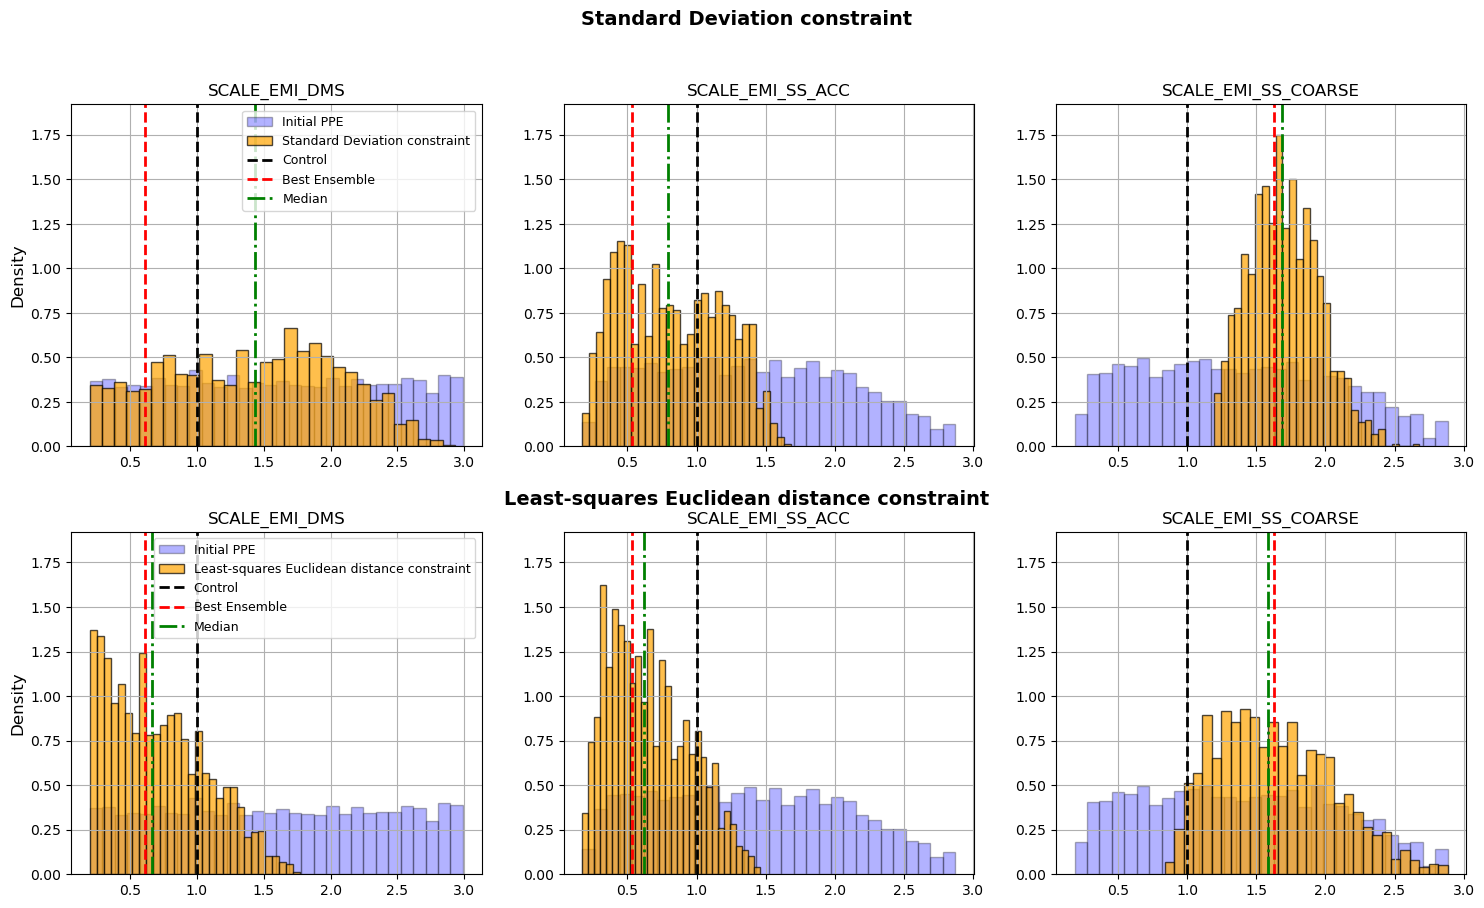

In [72]:
import matplotlib.pyplot as plt

# Columns to plot
plot_columns = [
    'SCALE_EMI_DMS',
    'SCALE_EMI_SS_ACC',
    'SCALE_EMI_SS_COARSE'
]

# Control and best
control_values = ppe_non_normalized_new_samples.iloc[0]
best_values = Best_ensemble_non_normal

# Accepted sets
shared_top = ppe_non_normalized_new_samples.iloc[accepted_members]       # top row
shared_bottom = ppe_non_normalized_new_samples.iloc[accepted_members_best]  # bottom row

# First pass: find max density for consistent y-axis
ymax = 0
for col in plot_columns:
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_top, _, _ = plt.hist(shared_top[col], bins=30, density=True)
    n_bottom, _, _ = plt.hist(shared_bottom[col], bins=30, density=True)
    ymax = max(ymax, n_full.max(), n_top.max(), n_bottom.max())
plt.close()

# Set up 2 rows: row1 = accepted_members, row2 = accepted_members_best
# fig, axes = plt.subplots(nrows=2, ncols=len(plot_columns), figsize=(18, 10))
# axes = axes.reshape(2, len(plot_columns))
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10),  # Adjust based on number of parameters
                       gridspec_kw={'hspace': 0.25, 'wspace': 0.2})

row_titles = ["Standard Deviation constraint", "Least-squares Euclidean distance constraint"]

for row, (shared, row_title) in enumerate([(shared_top, row_titles[0]), (shared_bottom, row_titles[1])]):
    for i, col in enumerate(plot_columns):
        ax = axes[row, i]

        # Full ensemble
        ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, color="blue", alpha=0.3,
                                                 edgecolor="black", density=True, label="Initial PPE")

        # Accepted set
        shared[col].hist(ax=ax, bins=30, color="orange", alpha=0.7,
                         edgecolor="black", density=True, label=row_title)

        # Vertical lines
        ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2, label="Control")
        ax.axvline(best_values[col], color="red", linestyle="--", linewidth=2, label="Best Ensemble")
        ax.axvline(shared[col].median(), color="green", linestyle="dashdot", linewidth=2, label="Median")

        # Title
        ax.set_title(col, fontsize=12)

        # Y limits
        ax.set_ylim(0, ymax * 1.1)

        if i == 0:
            ax.set_ylabel("Density", fontsize=12)
            ax.legend(fontsize=9)
        else:
            ax.set_ylabel("")

    # Add a row-level title spanning all columns
    fig.text(0.5, 0.965 - row * 0.48, row_title, ha="center", va="center", fontsize=14, fontweight="bold")

# plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitles
plt.show()


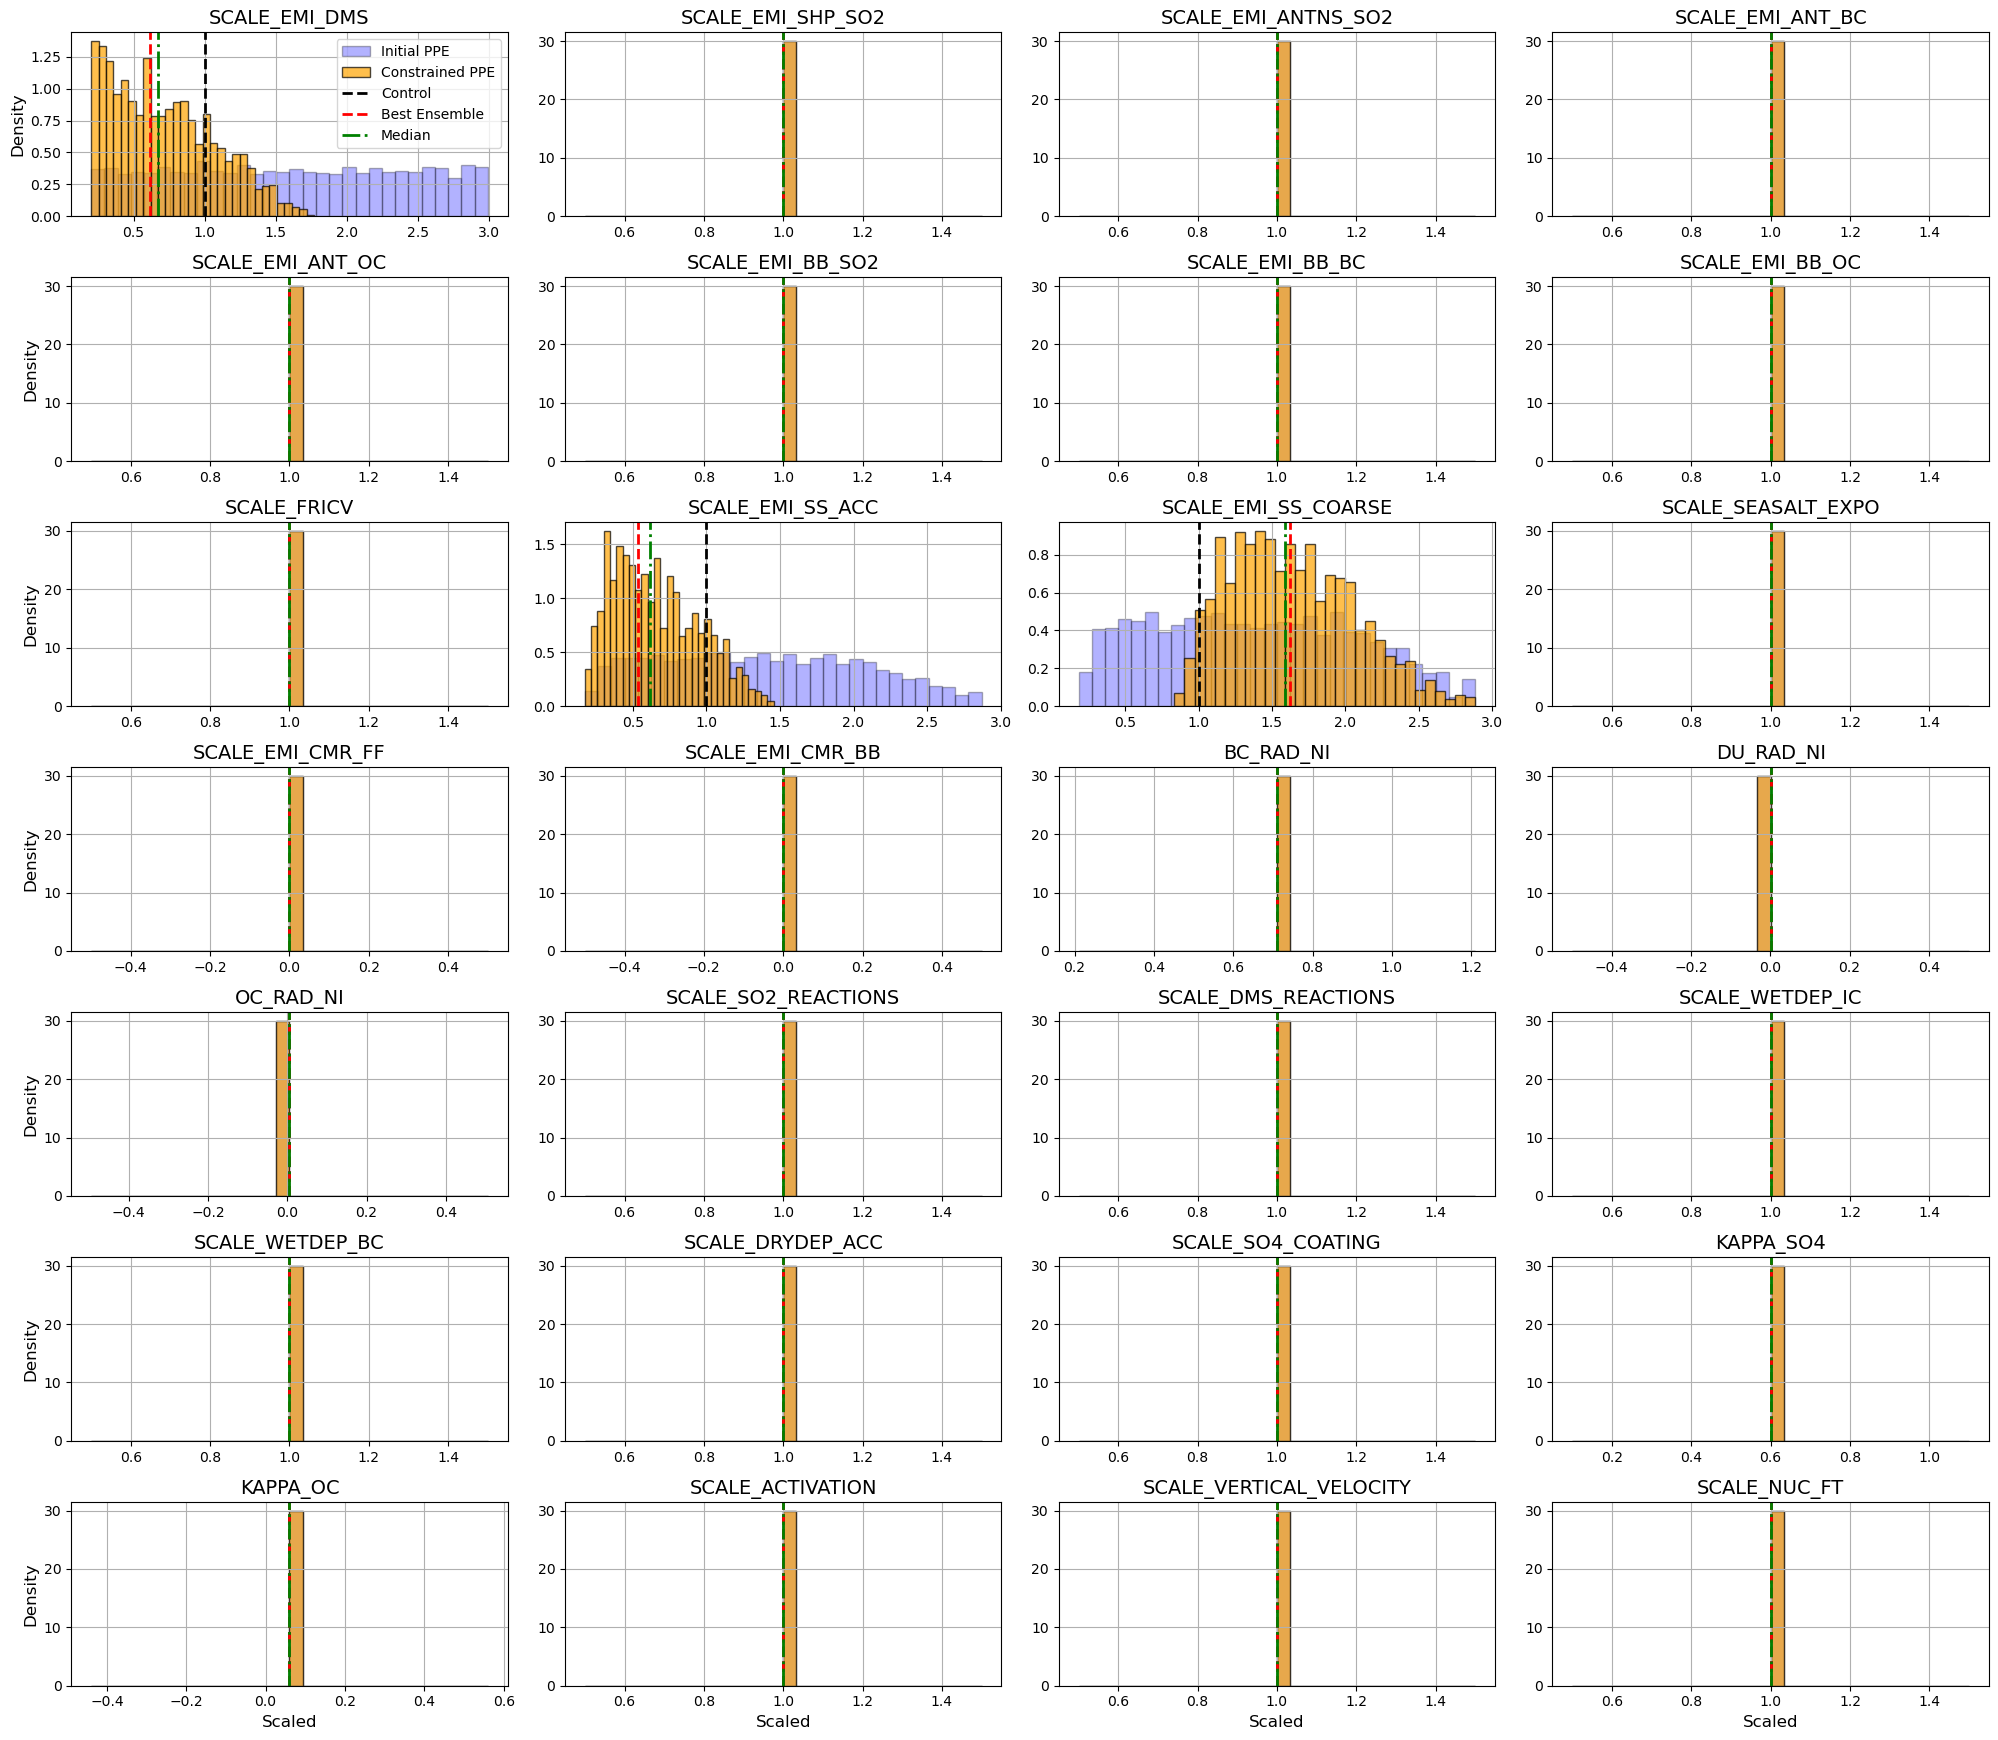

In [73]:
shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[accepted_members_best]
control_values = ppe_non_normalized_new_samples.iloc[0]
best_member_values = ppe_non_normalized_new_samples.iloc[best_idx]
num_cols = len(shared_dataset_Southern_Ocean.columns)
cols_per_row = 4
rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

# First pass: compute max density across all plots
ymax = 0
for col in shared_dataset_Southern_Ocean.columns:
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
    ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                          color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_Southern_Ocean[col].hist(ax=ax, bins=30, edgecolor='black',
                             color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2, label="Control")
    ax.axvline(best_values[col], color="red", linestyle="--", linewidth=2, label="Best Ensemble")
    ax.axvline(shared[col].median(), color="green", linestyle="dashdot", linewidth=2, label="Median")

    # Inside the plotting loop, after the control line:
    # ax.axvline(best_member_values[col], color='green', linestyle='-', linewidth=2, label='Best-fit')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label
    if i % cols_per_row != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label
    if i < (rows - 1) * cols_per_row:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
   # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/scratch-local/ybhatti2.15038196/ipykernel_3972343/3272264266.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


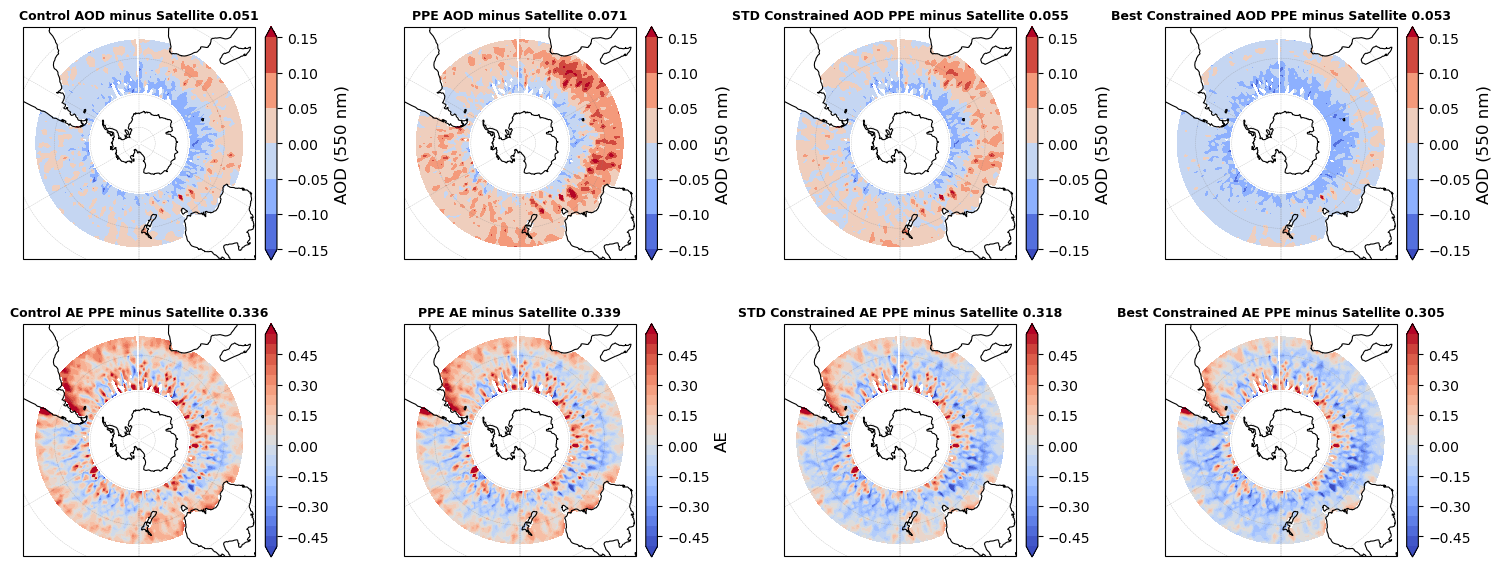

In [146]:
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import root_mean_squared_error

clevs_diff_aod = np.arange(-0.15, 0.15 + 0.05, 0.05)

clevs_diff_ssa = np.arange(-0.1, 0.1 + 0.01, 0.01)
clevs_diff_ang = np.arange(-0.5, 0.5 + 0.1, 0.05)
## AOD
clevs1 = np.arange(0, 0.5 + 0.1, 0.1)
clevsstd1 = np.arange(0, 1 + 0.1, 0.1)
clevs_std_aod = np.arange(0, 0.1 + 0.01, 0.01)
clevs_std_aod = np.arange(0, 0.2 + 0.02, 0.02)

## SSA
clevs5=np.arange(0.7,1+0.01,0.01)
clevsstd5=np.arange(0,0.1+0.02,0.01)
clevs_std_ssa = np.arange(0.032, 0.036 + 0.0001, 0.0001)

#ANG
clevs_ang=np.arange(0,2+0.2,0.2)
clevs_std_ang = np.arange(0, 0.15 + 0.01, 0.01)


clevs_var_aod = np.arange(0, 40 + 4, 4)   # Variability (std/mean)
clevs_var_ang = np.arange(6, 20 + 2, 2)   # Variability (std/mean)

# --- Custom Plot Function with Southern Ocean focus ---
def plot_with_colorbar(ax, data, lon, lat, cmap, clevs, title, Cbar_Title):
    # Meshgrid for projection
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Transform projection
    img = ax.contourf(
        lon2d, lat2d, data,
        levels=clevs, cmap=cmap, extend="both",
        transform=ccrs.PlateCarree()
    )

    # Add coastlines + gridlines
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.set_extent([-180, 180, -90, -25], crs=ccrs.PlateCarree())  # Southern Ocean focus
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, linestyle="--", color="gray", alpha=0.5)
    
    # Colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(Cbar_Title, fontsize=12)

    # Title
    ax.set_title(title, fontsize=9, fontweight="bold")

    return img

# --- Projection setup ---
proj = ccrs.SouthPolarStereo()

# --- Figure setup ---
fig = plt.figure(figsize=(18, 12))
grid = plt.GridSpec(3, 4, wspace=0.5, hspace=-0.1)

map_axes = [
    fig.add_subplot(grid[0, 0], projection=proj),
    fig.add_subplot(grid[0, 1], projection=proj),
    fig.add_subplot(grid[1, 0], projection=proj),
    fig.add_subplot(grid[1, 1], projection=proj),
    fig.add_subplot(grid[0, 2], projection=proj),
    fig.add_subplot(grid[1, 2], projection=proj),
    fig.add_subplot(grid[0, 3], projection=proj),
    fig.add_subplot(grid[1, 3], projection=proj),

]

Accepted_AOD = emulated_aod.sel(sample=accepted)
Accepted_ANG = emulated_ang.sel(sample=accepted)

diff_aod_constrain = Accepted_AOD - aod_pace_monthly
diff_aod = emulated_aod - aod_pace_monthly
diff_best_aod_constrain = best_member_so_aod - aod_pace_monthly

diff_ang_constrain = Accepted_ANG - ang_pace_monthly
diff_ang = emulated_ang - ang_pace_monthly
diff_best_ang_constrain = best_member_so_ang - ang_pace_monthly

pace_ang = ang_pace_monthly.stack(z=("month", "lat", "lon"))
pace_aod = aod_pace_monthly.stack(z=("month", "lat", "lon"))

best_ang = root_mean_squared_error(pace_ang.fillna(0),best_member_so_ang.stack(z=("month", "lat", "lon")).fillna(0))
best_aod = root_mean_squared_error(pace_aod.fillna(0),best_member_so_aod.stack(z=("month", "lat", "lon")).fillna(0))
constraint_ang = root_mean_squared_error(pace_ang.fillna(0),Accepted_ANG.mean("sample").stack(z=("month", "lat", "lon")).fillna(0))
constraint_aod = root_mean_squared_error(pace_aod.fillna(0),Accepted_AOD.mean("sample").stack(z=("month", "lat", "lon")).fillna(0))
control_ang = root_mean_squared_error(pace_ang.fillna(0),emulated_ang[0].stack(z=("month", "lat", "lon")).fillna(0))
control_aod = root_mean_squared_error(pace_aod.fillna(0),emulated_aod[0].stack(z=("month", "lat", "lon")).fillna(0))

# rms = root_mean_squared_error(pace_ang.fillna(0),best_ang.fillna(0))

# --- Example plots (Southern Ocean) ---
mean_emul_aod = emulated_aod.mean(["sample","month"])
mean_diff_aod = diff_aod.mean(["sample","month"])
mean_diff_aod_constrain = diff_aod_constrain.mean(["sample","month"])
mean_diff_best_aod_constrain = diff_best_aod_constrain.mean(["month"])
mean_abs_diff_aod = np.abs(diff_aod).mean(["sample","month"])
mean_abs_diff_aod_constrain = np.abs(diff_aod_constrain).mean(["sample","month"])
abs_diff_best_aod_constrain = np.abs(diff_best_aod_constrain).mean(["month"])
mean_abs_diff_aod = np.abs(diff_aod).mean(["sample","month"])

mean_emul_ang = emulated_ang.mean(["sample","month"])
mean_diff_ang = diff_ang.mean(["sample","month"])
mean_diff_ang_constrain = diff_ang_constrain.mean(["sample","month"])
mean_diff_best_ang_constrain = diff_best_ang_constrain.mean(["month"])
mean_abs_diff_aod = np.abs(diff_aod).mean(["sample","month"])
mean_abs_diff_ang_constrain = np.abs(diff_ang_constrain).mean(["sample","month"])
abs_diff_best_ang_constrain = np.abs(diff_best_ang_constrain).mean(["month"])
mean_abs_diff_ang = np.abs(diff_ang).mean(["sample","month"])

mean_diff_control_ang = diff_ang[0].mean(["month"])
mean_diff_control_aod = diff_aod[0].mean(["month"])
mean_abs_diff_control_aod = np.abs(diff_aod[0]).mean(["month"])
mean_abs_diff_control_ang = np.abs(diff_ang[0]).mean(["month"])

# --- Example plots (Southern Ocean) ---
# plot_with_colorbar(map_axes[0], mean_emul_aod, lons, lats_so, "viridis", clevs1,
#                    "(c) PPE Mean AOD", "AOD (550 nm)")
plot_with_colorbar(map_axes[0], mean_diff_control_aod, lons, lats_so, "coolwarm", clevs_diff_aod,
                    f"Control AOD minus Satellite {areaweight(mean_abs_diff_control_aod,lats_so).item():.3f}", "AOD (550 nm)")
plot_with_colorbar(map_axes[1], mean_diff_aod, lons, lats_so, "coolwarm", clevs_diff_aod,
                   f"PPE AOD minus Satellite {areaweight(mean_abs_diff_aod,lats_so).item():.3f}", "AOD (550 nm)")
plot_with_colorbar(map_axes[4], mean_diff_aod_constrain, lons, lats_so, "coolwarm", clevs_diff_aod,
                   f"STD Constrained AOD PPE minus Satellite {areaweight(mean_abs_diff_aod_constrain,lats_so).item():.3f}", "AOD (550 nm)")
plot_with_colorbar(map_axes[6], mean_diff_best_aod_constrain, lons, lats_so, "coolwarm", clevs_diff_aod,
                   f"Best Constrained AOD PPE minus Satellite {areaweight(abs_diff_best_aod_constrain,lats_so).item():.3f}", "AOD (550 nm)")

plot_with_colorbar(map_axes[2], mean_diff_control_ang, lons, lats_so, "coolwarm", clevs_diff_ang,
                   f"Control AE PPE minus Satellite {areaweight(mean_abs_diff_control_ang,lats_so).item():.3f}", "")
plot_with_colorbar(map_axes[5], mean_diff_ang_constrain, lons, lats_so, "coolwarm", clevs_diff_ang,
                   f"STD Constrained AE PPE minus Satellite {areaweight(mean_abs_diff_ang_constrain,lats_so).item():.3f}", "")
plot_with_colorbar(map_axes[3], mean_diff_ang, lons, lats_so, "coolwarm", clevs_diff_ang,
                   f"PPE AE minus Satellite {areaweight(mean_abs_diff_ang,lats_so).item():.3f}", "AE")
plot_with_colorbar(map_axes[7], mean_diff_best_ang_constrain, lons, lats_so, "coolwarm", clevs_diff_ang,
                   f"Best Constrained AE PPE minus Satellite {areaweight(abs_diff_best_ang_constrain,lats_so).item():.3f}", "")

plt.tight_layout()
plt.show()


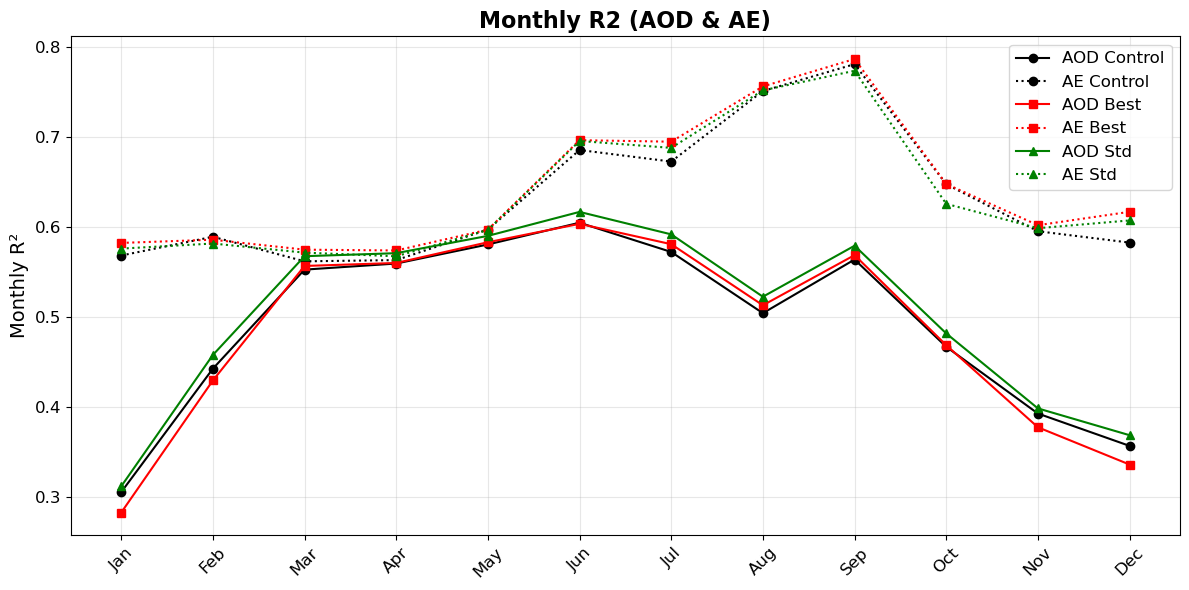

In [278]:
# plt.scatter(pace_ang,emulated_ang[0].stack(z=("month", "lat", "lon")))
# plt.show()
# print(np.corrcoef(pace_ang.fillna(0),emulated_ang[0].stack(z=("month", "lat", "lon")).fillna(0))[0][1]**2)

# plt.scatter(pace_ang,best_member_so_ang.stack(z=("month", "lat", "lon")))
# print(np.corrcoef(pace_ang.fillna(0),best_member_so_ang.stack(z=("month", "lat", "lon")).fillna(0))[0][1]**2)
# plt.show()

# plt.scatter(pace_ang,Accepted_ANG.mean('sample').stack(z=("month", "lat", "lon")))
# print(np.corrcoef(pace_ang.fillna(0),Accepted_ANG.mean('sample').stack(z=("month", "lat", "lon")).fillna(0))[0][1]**2)
# plt.show()



ang=[]
aod=[]
ang_best=[]
aod_best=[]
ang_std=[]
aod_std=[]

ang_rms=[]
aod_rms=[]
for i in range(0,12):
    ang.append(np.corrcoef(ang_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),emulated_ang[0][i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)
    aod.append(np.corrcoef(aod_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),emulated_aod[0][i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)
    ang_rms.append(root_mean_squared_error(ang_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),emulated_ang[0][i].stack(z=("lat", "lon")).fillna(0)))
    aod_rms.append(root_mean_squared_error(aod_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),emulated_aod[0][i].stack(z=("lat", "lon")).fillna(0)))
    ang_best.append(np.corrcoef(ang_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),best_member_so_ang[i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)
    aod_best.append(np.corrcoef(aod_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),best_member_so_aod[i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)
    ang_std.append(np.corrcoef(ang_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),Accepted_ANG.mean('sample')[i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)
    aod_std.append(np.corrcoef(aod_pace_monthly[i].stack(z=("lat", "lon")).fillna(0),Accepted_AOD.mean('sample')[i].stack(z=("lat", "lon")).fillna(0))[0][1]**2)

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(1, 13)

plt.figure(figsize=(12,6))

# --- Control
plt.plot(x, aod, color='black', label='AOD Control', marker='o')
plt.plot(x, ang, color='black', linestyle='dotted', label='AE Control', marker='o')

# --- Best-fit
plt.plot(x, aod_best, color='red', label='AOD Best', marker='s')
plt.plot(x, ang_best, color='red', linestyle='dotted', label='AE Best', marker='s')

# --- Std-accepted mean
plt.plot(x, aod_std, color='green', label='AOD Std', marker='^')
plt.plot(x, ang_std, color='green', linestyle='dotted', label='AE Std', marker='^')

# --- Formatting
plt.xticks(x, months, rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Monthly R²", fontsize=14)
plt.title("Monthly R2 (AOD & AE)", fontsize=16, fontweight="bold")
plt.grid(alpha=0.3)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


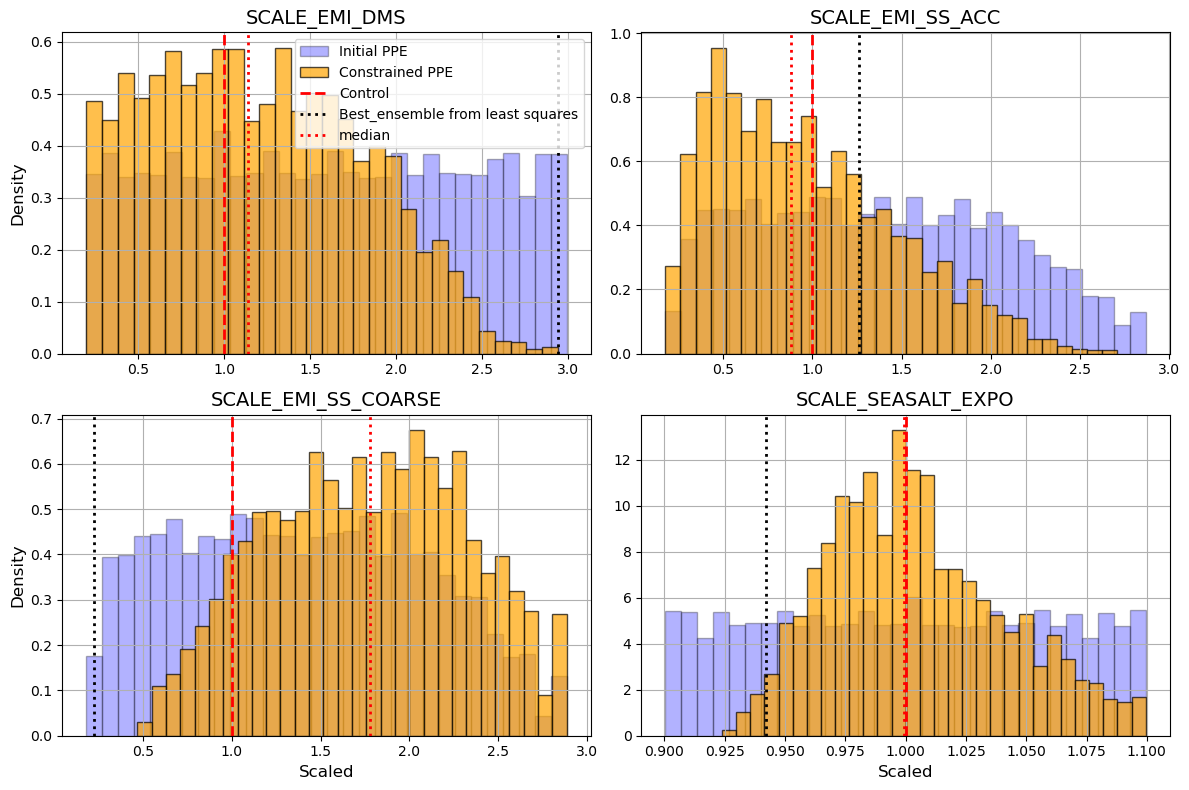

In [240]:
import matplotlib.pyplot as plt

# --- Start of required changes ---
control_values_non_norm = ppe_param.iloc[0]
# 1. Define a list of the specific columns you want to plot.
plot_columns = [
    'SCALE_EMI_DMS',
    'SCALE_EMI_SS_ACC',
    'SCALE_EMI_SS_COARSE',
    'SCALE_SEASALT_EXPO'
]

# --- End of required changes ---


# First pass: compute max density across all plots
ymax = 0
for col in plot_columns: # <-- MODIFIED: Iterate over your specific list
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_southern_ocean_non_normalized[col], bins=30, density=True)
    # ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
# <-- MODIFIED: Set up a 2x2 grid specifically for your 4 plots.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(plot_columns): # <-- MODIFIED: Iterate over your specific list
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                                         color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_southern_ocean_non_normalized[col].hist(ax=ax, bins=30, edgecolor='black',
                                          color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    # ax.axvline(control_values_non_norm[col], color='red', linestyle='--', linewidth=2, label='Control')
    # ax.axvline(Best_ensemble_non_normal[col], color='black', linestyle=':', linewidth=2, label='Best_ensemble from least squares')
    # ax.axvline(shared_dataset_southern_ocean_non_normalized[col].median(), color='red', linestyle=':', linewidth=2, label='median')
    ax.axvline(control_values_non_norm[col], color='red', linestyle='--', linewidth=2, label='Control')
    ax.axvline(Best_ensemble_non_normal[col], color='black', linestyle='--', linewidth=2, label='Best_ensemble from least squares')
    ax.axvline(shared_dataset_southern_ocean_non_normalized[col].median(), color='green', linestyle='dashdot', linewidth=2, label='median')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label (Logic slightly adjusted for a 2-column layout)
    if i % 2 != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label (Logic slightly adjusted for a 2-row layout)
    if i < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
    # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# This part is no longer needed since we have exactly 4 plots for our 4 axes,
# but it doesn't hurt to leave it.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

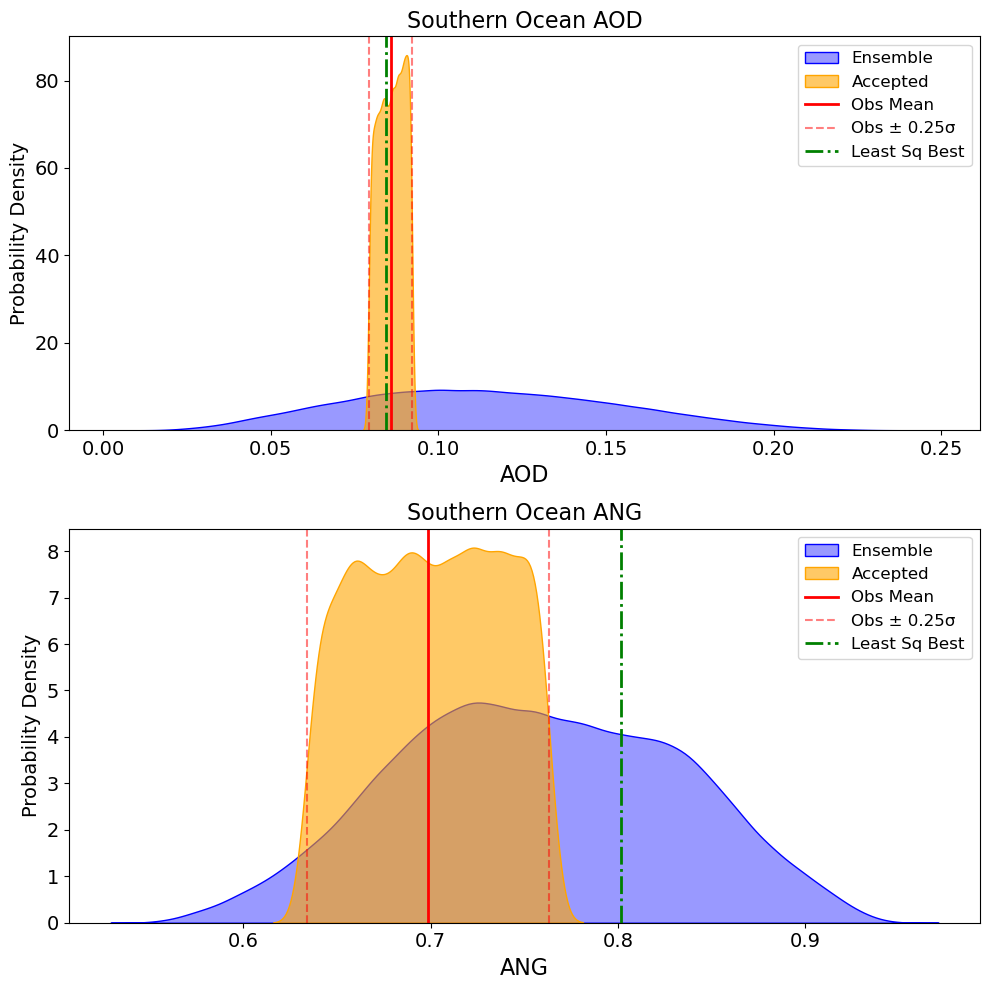

In [315]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 2 rows: AOD and ANG

# Prepare accepted datasets
Accepted_AOD_SO = emulated_aod.sel(sample=accepted)
Accepted_ANG_SO = emulated_ang.sel(sample=accepted)
accepted_aod_area = areaweight(Accepted_AOD_SO, lats_so)
accepted_ang_area = areaweight(Accepted_ANG_SO, lats_so)
BEST_AOD_SO = areaweight(emulated_aod.sel(sample=best_idx),lats_so)

# Loop through variables (AOD, ANG)
for ax, (full_data, accepted_data, label, obs,best) in zip(
    axes,
    [
        (areaweighted_emulated_aod, accepted_aod_area, "AOD", aod_pace_time,BEST_AOD_SO),
        (areaweighted_emulated_ang, accepted_ang_area, "ANG", ang_pace_time,BEST_ANG_SO),
    ]
):
    # Flatten ensemble and accepted values
    full_values = full_data.values.flatten()
    accepted_values = accepted_data.values.flatten()

    # Obs mean/std across time
    obs_mean = obs.mean().item()
    obs_std = obs.std().item()

    # Plot ensemble PDF (blue)
    sns.kdeplot(full_values, fill=True, ax=ax, label="Ensemble", color="blue", alpha=0.4)

    # Plot accepted subset PDF (orange, semi-transparent)
    sns.kdeplot(accepted_values, fill=True, ax=ax, label="Accepted", color="orange", alpha=0.6)

    # Obs mean and ±0.5σ
    ax.axvline(obs_mean, color="red", linestyle="-", linewidth=2, label="Obs Mean")
    ax.axvline(obs_mean - n * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5, label=f"Obs ± {n}σ")
    ax.axvline(obs_mean + n * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5)
    ax.axvline(best, color="green", linestyle="dashdot", linewidth=2, label="Least Sq Best")

    # Labels & styling
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.set_title(f"Southern Ocean {label}", fontsize=16)
    ax.legend(fontsize=12)

plt.tight_layout()
# plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/Aerocom/PDF_PPE_to_Observations.png", dpi=100, bbox_inches="tight")
plt.show()


# what happens when we expand on the standard deviation .So instead of 0.25 * the std, lets do 2 *.

In [322]:
# --- 1. Compute obs mean ± std ranges ---
aod_mean, aod_std = aod_pace_time.mean().item(), aod_pace_time.std().item()
ang_mean, ang_std = ang_pace_time.mean().item(), ang_pace_time.std().item()

# aod_range = (aod_mean - aod_std, aod_mean + aod_std)
# ssa_range = (ssa_mean - ssa_std, ssa_mean + ssa_std)
# ang_range = (ang_mean - ang_std, ang_mean + ang_std)
n=1
aod_range = (aod_mean - n * aod_std, aod_mean + n * aod_std)
ang_range = (ang_mean - n * ang_std, ang_mean + n * ang_std)


print("Obs AOD range:", aod_range)
print("Obs ANG range:", ang_range)

# --- 2. Compute ensemble means for each member ---
# --- 3. Apply acceptance criteria ---
accepted = (
    (areaweighted_emulated_aod >= aod_range[0]) & (areaweighted_emulated_aod <= aod_range[1]) &
    # (areaweighted_emulated_ssa >= ssa_range[0]) & (areaweighted_emulated_ssa <= ssa_range[1]) &
    (areaweighted_emulated_ang >= ang_range[0]) & (areaweighted_emulated_ang <= ang_range[1])
)

accepted_members = areaweighted_emulated_aod.sample[accepted]

print(f"Number of accepted ensembles: {accepted.sum().item()}")
#print("Accepted ensemble IDs:", accepted_members.values)
shared_dataset_southern_ocean = ppe_normalized_new_samples.iloc[accepted_members]
control_values = ppe_normalized_new_samples.iloc[0]
shared_dataset_southern_ocean_non_normalized = ppe_non_normalized_new_samples.iloc[accepted_members]


###########################################
######## least-squares norm (Euclidean distance):
 
# # Masked obs vector
# obs_vec = AOD_SO[:,-1].mean('time').values.ravel()
# valid_mask = ~np.isnan(obs_vec)
# obs_vec = obs_vec[valid_mask]

# # Flatten ensemble members
# ens = emulated_aod.stack(z=("lat", "lon"))  # shape: (sample, z)
# ens_vec = ens.values[:, valid_mask]         # keep only valid grid cells

# # Compute squared differences per sample
# diff = ens_vec - obs_vec
# misfit = np.linalg.norm(diff, axis=1)  # Euclidean norm per sample

# # Find best sample
# best_idx = int(np.argmin(misfit))
# print("Best-fitting ensemble index:", best_idx)

# best_member_so = emulated_aod.isel(sample=best_idx)
# Best_ensemble = ppe_normalized_new_samples.iloc[best_idx]
# Best_ensemble_non_normal = ppe_non_normalized_new_samples.iloc[best_idx]
###########################################
######## least-squares norm (Euclidean distance) for AOD + ANG
###########################################

# --- Prepare observed vectors (Southern Ocean mean over time) ---
# AOD
obs_vec_aod = aod_pace.values.ravel()
mask_aod = ~np.isnan(obs_vec_aod)
obs_vec_aod = obs_vec_aod[mask_aod]

# ANG
obs_vec_ang = ang_pace.values.ravel()
mask_ang = ~np.isnan(obs_vec_ang)
obs_vec_ang = obs_vec_ang[mask_ang]

0.1 and 0.02 for least squares

and plot the PDF of the WEIGHTED least squares method

# --- Ensemble vectors ---
# AOD
ens_aod = emulated_aod.stack(z=("lat", "lon"))
ens_vec_aod = ens_aod.values[:, mask_aod]  # shape: (samples, points)

# ANG
ens_ang = emulated_ang.stack(z=("lat", "lon"))
ens_vec_ang = ens_ang.values[:, mask_ang]

# --- Combine AOD + ANG ---
# Concatenate along spatial axis → joint state vector
ens_vec = np.concatenate([ens_vec_aod, ens_vec_ang], axis=1)   # shape: (samples, n_points_total)
obs_vec = np.concatenate([obs_vec_aod, obs_vec_ang])           # shape: (n_points_total,)

# --- Misfit: Euclidean distance ---
diff = ens_vec - obs_vec
misfit = np.linalg.norm(diff, axis=1)

# --- Best match ---
best_idx = int(np.argmin(misfit))
print("Best-fitting ensemble index (AOD+ANG):", best_idx)

best_member_so_aod = emulated_aod.isel(sample=best_idx)
best_member_so_ang = emulated_ang.isel(sample=best_idx)

Best_ensemble = ppe_normalized_new_samples.iloc[best_idx]
Best_ensemble_non_normal = ppe_non_normalized_new_samples.iloc[best_idx]



Obs AOD range: (0.059941647281132306, 0.1115233637971165)
Obs ANG range: (0.4398607250804368, 0.9574282873165005)
Number of accepted ensembles: 82354
Best-fitting ensemble index (AOD+ANG): 185316


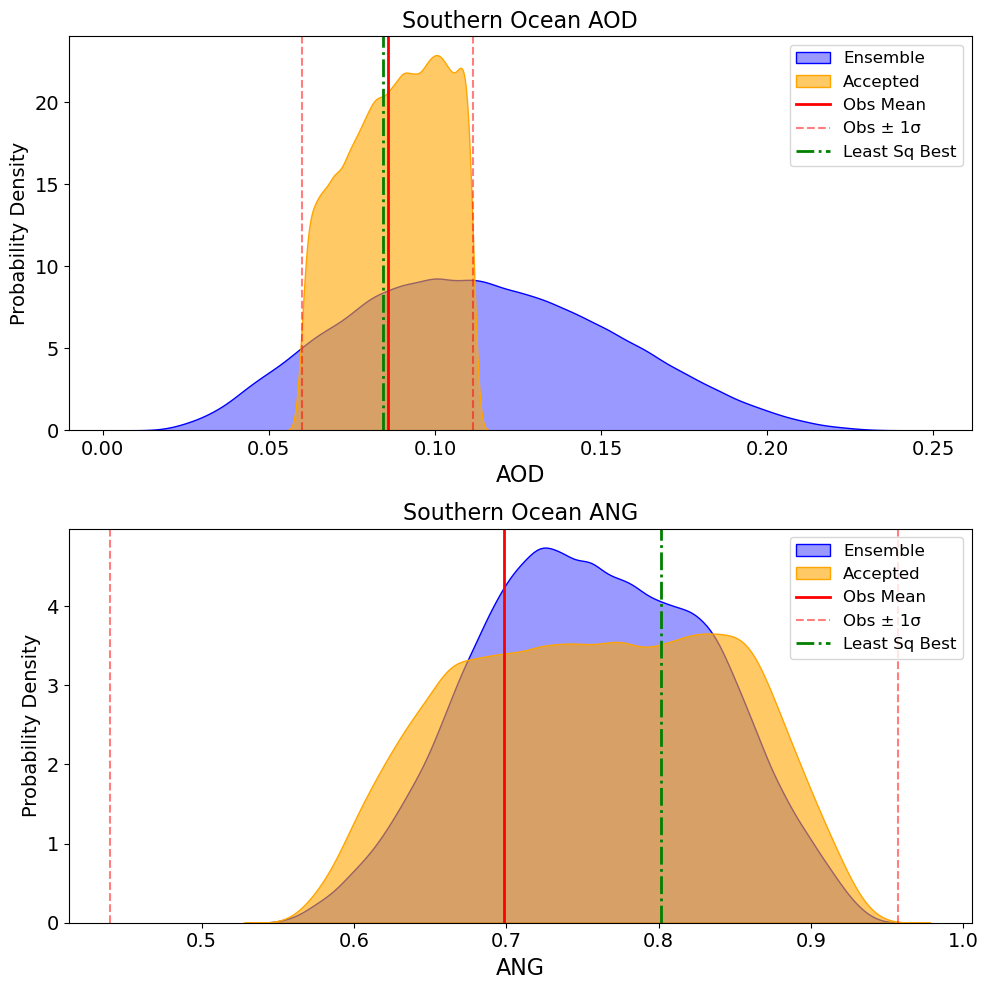

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 2 rows: AOD and ANG

# Prepare accepted datasets
Accepted_AOD_SO = emulated_aod.sel(sample=accepted)
Accepted_ANG_SO = emulated_ang.sel(sample=accepted)
accepted_aod_area = areaweight(Accepted_AOD_SO, lats_so)
accepted_ang_area = areaweight(Accepted_ANG_SO, lats_so)
BEST_AOD_SO = areaweight(emulated_aod.sel(sample=best_idx),lats_so)
BEST_ANG_SO = areaweight(emulated_ang.sel(sample=best_idx),lats_so)
n=1
# Loop through variables (AOD, ANG)
for ax, (full_data, accepted_data, label, obs,best) in zip(
    axes,
    [
        (areaweighted_emulated_aod, accepted_aod_area, "AOD", aod_pace_time,BEST_AOD_SO),
        (areaweighted_emulated_ang, accepted_ang_area, "ANG", ang_pace_time,BEST_ANG_SO),
    ]
):
    # Flatten ensemble and accepted values
    full_values = full_data.values.flatten()
    accepted_values = accepted_data.values.flatten()

    # Obs mean/std across time
    obs_mean = obs.mean().item()
    obs_std = obs.std().item()

    # Plot ensemble PDF (blue)
    sns.kdeplot(full_values, fill=True, ax=ax, label="Ensemble", color="blue", alpha=0.4)

    # Plot accepted subset PDF (orange, semi-transparent)
    sns.kdeplot(accepted_values, fill=True, ax=ax, label="Accepted", color="orange", alpha=0.6)

    # Obs mean and ±0.5σ
    ax.axvline(obs_mean, color="red", linestyle="-", linewidth=2, label="Obs Mean")
    ax.axvline(obs_mean - 1 * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5, label=f"Obs ± {n}σ")
    ax.axvline(obs_mean + 1 * obs_std, color="red", linestyle="--", linewidth=1.5, alpha=0.5)
    ax.axvline(best, color="green", linestyle="dashdot", linewidth=2, label="Least Sq Best")

    # Labels & styling
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.set_title(f"Southern Ocean {label}", fontsize=16)
    ax.legend(fontsize=12)

plt.tight_layout()
# plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/Aerocom/PDF_PPE_to_Observations.png", dpi=100, bbox_inches="tight")
plt.show()


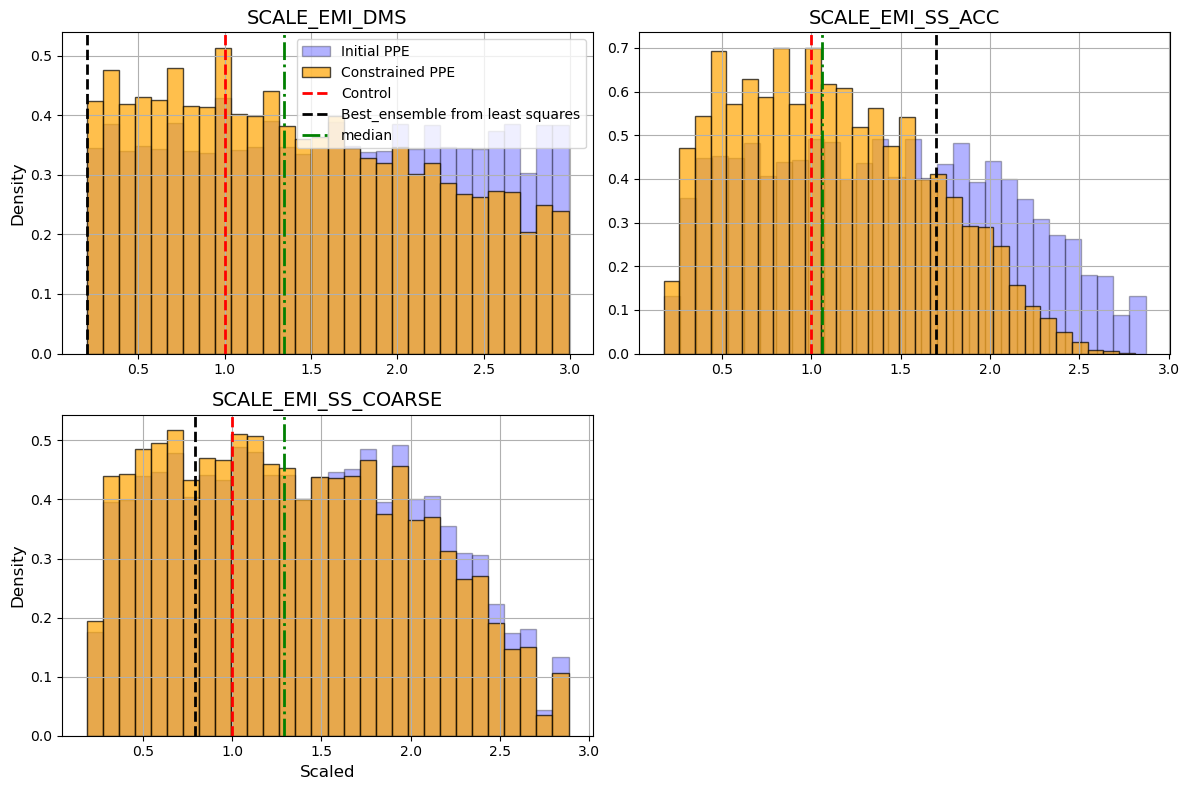

In [301]:
import matplotlib.pyplot as plt

# --- Start of required changes ---
control_values_non_norm = ppe_param.iloc[0]
# 1. Define a list of the specific columns you want to plot.
plot_columns = [
    'SCALE_EMI_DMS',
    'SCALE_EMI_SS_ACC',
    'SCALE_EMI_SS_COARSE'
]

# --- End of required changes ---


# First pass: compute max density across all plots
ymax = 0
for col in plot_columns: # <-- MODIFIED: Iterate over your specific list
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_southern_ocean_non_normalized[col], bins=30, density=True)
    # ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
# <-- MODIFIED: Set up a 2x2 grid specifically for your 4 plots.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(plot_columns): # <-- MODIFIED: Iterate over your specific list
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                                         color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_southern_ocean_non_normalized[col].hist(ax=ax, bins=30, edgecolor='black',
                                          color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    ax.axvline(control_values_non_norm[col], color='red', linestyle='--', linewidth=2, label='Control')
    ax.axvline(Best_ensemble_non_normal[col], color='black', linestyle='--', linewidth=2, label='Best_ensemble from least squares')
    ax.axvline(shared_dataset_southern_ocean_non_normalized[col].median(), color='green', linestyle='dashdot', linewidth=2, label='median')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label (Logic slightly adjusted for a 2-column layout)
    if i % 2 != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label (Logic slightly adjusted for a 2-row layout)
    if i < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
    # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# This part is no longer needed since we have exactly 4 plots for our 4 axes,
# but it doesn't hurt to leave it.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()